In [10]:
# !pip install ttvfast
# !pip install corner
# !pip install rebound
#!pip install 'keras<3.0.0' mediapipe-model-maker
#!pip install astropy


import keras
keras.__version__

import tensorflow as tf
tf.__version__

'2.20.0'

In [11]:
!pip install ttvfast
!pip install corner
!pip install rebound

In [3]:

from google.colab import drive
drive.mount('/content/gdrive')
import sys
sys.path.insert(1, "/content/gdrive/MyDrive/nbody_project/Nbody-AI/")

Mounted at /content/gdrive


In [4]:
from nbody.simulation import generate, analyze, report
from nbody.tools import mjup,msun,mearth

In [5]:
import matplotlib.pyplot as plt
#from astropy.timeseries import LombScargle

import pandas as pd
import numpy as np
import ttvfast
from ttvfast import models

from math import nan
import pickle
from tqdm import tqdm

import argparse
import corner
import time
from scipy.stats import beta
from scipy.interpolate import interp1d
import tensorflow as tf



plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams.update({'font.size': 14})

import matplotlib


In [6]:

import matplotlib.pyplot as plt

In [7]:
rsun = 6.955e8 # m
msun = 1.989e30 # kg
mjup = 1.898e27 # kg
rjup = 7.1492e7 # m
mearth = 5.972e24 # kg
rearth = 6.3781e6 # m
au=1.496e11 # m
G = 0.00029591220828559104 # day, AU, Msun

In [8]:
import random
import math

def ttv_generate(ms, p1,m1,p2,m2,o2,e2):
  gravity = 0.000295994511                        # AU^3/day^2/M_sun
  stellar_mass = ms
  eccentricity_ = 0#np.random.uniform(0,0.01)
  inclination_ = 90
  longnode_ = 0
  argument_ = 0 #np.random.uniform(0,360)
  mean_anomaly_ = 0 #np.random.uniform(0,360)
  planet1 = models.Planet(
      mass = m1,                         # M_sun
      period = p1,              # days
      eccentricity=eccentricity_,
      inclination=inclination_,         # degrees
      longnode=longnode_,           # degrees
      argument=argument_,            # degrees
      mean_anomaly=mean_anomaly_,       # degrees
  )

  planet2 = models.Planet(
      mass = m2,                         # M_sun
      period = p2,              # days
      eccentricity=e2,
      inclination=inclination_,         # degrees
      longnode=longnode_,           # degrees
      argument=o2,            # degrees
      mean_anomaly=mean_anomaly_,
  )

  planets = [planet1, planet2]
  Time = -1045                                    # days
  dt = 1/24#0.54                                       # days
  Total = 1700                                  # days

  results = ttvfast.ttvfast(planets, stellar_mass, Time, dt, Total)
  return results


def generate_random_resonance(min_val=2, max_val=10):
    while True:
        numerator = random.randint(min_val, max_val)
        denominator = random.randint(min_val, max_val)

        # Ensure the ratio is greater than 1
        if numerator != denominator:
            break

    # Simplify the ratio
    gcd = math.gcd(numerator, denominator)
    simplified_numerator = numerator // gcd
    simplified_denominator = denominator // gcd

    # Ensure the ratio is greater than 1 after simplification
    if simplified_numerator < simplified_denominator:
        simplified_numerator, simplified_denominator = simplified_denominator, simplified_numerator

    return simplified_numerator, simplified_denominator


def TTV(epochs, tt):
    N = len(epochs)
    A = np.vstack([np.ones(N), epochs]).T
    b, m = np.linalg.lstsq(A, tt, rcond=None)[0]
    ttv = (tt-m*np.array(epochs)-b)
    return [ttv,m,b]

import numpy as np

def generate_random_exclude_1(n, low=0.3, high=2.5, exclude_range=(0.9, 1.1)):
    random_numbers = []

    while len(random_numbers) < n:
        num = np.random.uniform(low, high)
        if not (exclude_range[0] <= num <= exclude_range[1]):
            random_numbers.append(num)

    return np.array(random_numbers)


# Define a function to enable dropout during inference
def predict_with_uncertainty(f, x, n_iter=100):
    result = [f(x, training=True) for _ in range(n_iter)]
    result = np.array(result)
    prediction = result.mean(axis=0)
    uncertainty = result.std(axis=0)
    return prediction, uncertainty


def remove_points_and_interpolate(ttv, missing_fraction):
    n = len(ttv)
    t = np.arange(n)

    # mask for keeping points
    mask = np.random.rand(n) > missing_fraction

    # ensure at least 3 points remain
    if mask.sum() < 3:
        mask[np.random.choice(n, 3, replace=False)] = True

    t_kept = t[mask]
    y_kept = ttv[mask]

    f = interp1d(t_kept, y_kept, kind="linear", fill_value="extrapolate")
    return f(t)  # return interpolated full-length series

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_parameter_distributions(mass_samples, period_samples, ecc_samples, omega_samples):
    """
    Plots the distribution of MC Dropout predictions for all 4 parameters.
    Specifically formats Eccentricity to 10^-7 for readability.
    """

    # Create a 2x2 figure
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    #fig.suptitle('Uncertainty Distribution Analysis (N=100 Stochastic Passes)', fontsize=16)

    # Helper function to plot individual subplot
    def plot_single_param(ax, data, title, xlabel, color):
        # Plot Histogram with Kernel Density Estimate (KDE)
        sns.histplot(data, kde=True, ax=ax, color=color, bins=15, alpha=0.6)

        # Calculate and plot the Mean line
        mean_val = np.mean(data)
        std_val = np.std(data)
        ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.4f}')
        ax.axvline(mean_val - std_val, color='black', linestyle=':', alpha=0.5, label=fr'±1$\sigma$: {std_val:.4f}')
        ax.axvline(mean_val + std_val, color='black', linestyle=':', alpha=0.5)

        # Labels
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Frequency')
        ax.legend()
        ax.grid(True, alpha=0.3)

    # 1. Mass Plot (Top Left)
    plot_single_param(axes[0, 0],
                      mass_samples,
                      title=r"Mass ($m_2$)",
                      xlabel=r"Mass ($M_{\oplus}$)",
                      color='skyblue')

    # 2. Period Plot (Top Right)
    plot_single_param(axes[0, 1],
                      period_samples,
                      title=r"Period ($p_2$)",
                      xlabel="Period (days)",
                      color='orange')

    # 3. Eccentricity Plot (Bottom Left)
    # --- MODIFICATION: Scale data by 1e7 to force 10^-7 format ---
    ecc_scaled = ecc_samples * 1e7
    plot_single_param(axes[1, 0],
                      ecc_scaled,
                      title=r"Eccentricity ($e_2$)",
                      xlabel=r"Eccentricity ($10^{-7}$)", # Explicit label
                      color='green')

    # 4. Argument of Perigee Plot (Bottom Right)
    plot_single_param(axes[1, 1],
                      omega_samples,
                      title=r"Arg. of Periastron ($\omega_2$)",
                      xlabel="Degrees",
                      color='purple')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(str(model_[0:-6])+'_uncertainty.pdf', dpi=300,bbox_inches = 'tight')
    plt.show()

In [15]:
filepath='/content/gdrive/MyDrive/S3/paper22/'
datatrain_name='datatrain_paper2_20k_250_filtered'
filename= filepath+datatrain_name+'.pkl'

In [ ]:
#VERSI FINAL
start_time = time.time()
#Versi 2


try:
    loaded_data = pickle.load(open(filename,'rb'))
    y = loaded_data['ttv_data']
    ms_= loaded_data['star_mass']
    p1_ = loaded_data['transiting_period']
    m1_ = loaded_data['transiting_mass']
    m2_ = loaded_data['perturbing_mass']
    p2_ = loaded_data['perturbing_period']
    e2_ = loaded_data['perturbing_eccentricity']
    o2_ = loaded_data['perturbing_argument_perigee']
    print('There is old file')
except:
    print('creating new file (overwrite)')
    y,ms_,p1_,p2_,m1_,m2_,o2_,e2_ = [],[],[],[],[],[],[],[]

samples =  20000
omegas = 10
len_x= len(y)

#ms_,p1_,p2_,m1_,m2_,o2_,e2_=[],[],[],[],[],[],[]
#for ii in tqdm(range(len(X), samples)):
while len_x < samples*omegas:
    ms = np.random.uniform(0.5,2)
    m1 = np.random.uniform(1*mearth/msun, 80*mearth/msun)
    p1 = np.random.uniform(5,25)
    m2 = m1*np.random.uniform(0.2,2.5)
    p2 = p1*np.random.uniform(1,3)#generate_random_exclude_1(n=1, low=1, high=3)[0]
    o2 = np.random.uniform(0,360)
    e2 = beta.rvs(a=1.5, b=4)*0.01#np.abs(np.random.normal(0,0.01))
    maxttv = 500
    minttv = 1
    nttv = 50
    ress = ttv_generate(ms=ms, p1=p1, m1=m1  ,p2=p2,m2=m2,o2=o2,e2=e2)

    # if m2 < 10*mearth/msun or m2 > 80*mearth/msun:
    #   continue

    transit=[]
    epoch=[]
    for i in range (len(ress['positions'][0])):
        if (ress['positions'][0][i]) == 0:
            if (ress['positions'][2][i]) != -2:
                transit.append(ress['positions'][2][i])
                epoch.append(ress['positions'][1][i])
    # if np.any(np.isnan(transit)):
    #     continue
    #print (len_x)
    #
    #if (len(T1[0])) <= n_data or max(T1[0][:n_data]*24*60) > max_ttv or min(T1[0][:n_data]*24*60) < -max_ttv or max(T1[0][:n_data]*24*60) < min_ttv or min(T1[0][:n_data]*24*60) > -min_ttv
    T1=TTV(epoch,transit)
    if len(T1[0]) < nttv or max(T1[0][:nttv]*24*60) > maxttv  or min(T1[0][:nttv]*24*60) < -maxttv or max(T1[0][:nttv]*24*60) < minttv or  np.isnan(max(T1[0][:nttv])): #CEEKKKK
        continue
    rand_omg = np.random.uniform(0, 360, omegas)

    # Sort the array in ascending order
    omega_sort = np.sort(rand_omg)
    #omega harus looping dengan nilai omega berurutan
    for j in omega_sort:
    #while j < omegas:
        o2=j
        ress = ttv_generate(ms=ms, p1=p1, m1=m1  ,p2=p2 ,m2=m2 ,o2=o2 ,e2=e2)
        #o3 = o2 + np.random.normal(0,360/omegas)
        # if o3 > 360:
        #     continue
        # o2 = o3
        transit=[]
        epoch=[]
        for k in range (len(ress['positions'][0])):
            if (ress['positions'][0][k]) == 0:
                if (ress['positions'][2][k]) != -2:
                    transit.append(ress['positions'][2][k])
                    epoch.append(ress['positions'][1][k])
        if np.any(np.isnan(transit)):
            print('Ada nan transit didalam rand omega')
            continue
        T1=TTV(epoch,transit)
        if len(T1[0]) < nttv or max(T1[0][:nttv]*24*60) > maxttv or min(T1[0][:nttv]*24*60) < -maxttv or max(T1[0][:nttv]*24*60) < minttv or np.isnan(max(T1[0][:nttv])):
            continue
        #xn = []
        #ms_,p1_,p2_,m1_,m2_,o2_,e2_=[],[],[],[],[],[],[]
        ms_.append(ms)
        p1_.append(p1)
        m1_.append(m1*msun/mearth)
        p2_.append(p2)
        m2_.append(m2*msun/mearth)
        o2_.append(o2)
        e2_.append(e2)



        #X.append(xn)
        y.append(T1[0][:nttv]*24*60) #transit time

        data = {
          'ttv_data': y,
          'star_mass': ms_,
          'transiting_period': p1_,
          'transiting_mass': m1_,
          'perturbing_mass': m2_,
          'perturbing_period': p2_,
          'perturbing_eccentricity': e2_,
          'perturbing_argument_perigee': o2_
      }
        len_x+=1
        if len_x % 10000 == 0:
            print(len_x)
            pickle.dump(data,open(filename,'wb') )


end_time = time.time()
execution_time = end_time - start_time
ex_minutes = execution_time/60
print(f"Execution time: {execution_time:.6f} seconds")
print(f"Execution time: {ex_minutes:.6f} minutes")

There is old file


NameError: name 'mearth' is not defined

In [21]:
import pickle

# Load the data from the pickle file
with open(filename, 'rb') as f:
    loaded_data = pickle.load(f)

# Access the arrays
limit=200000
ttv_data = loaded_data['ttv_data'][0:limit]
star_mass = loaded_data['star_mass'][0:limit]
transiting_period = loaded_data['transiting_period'][0:limit]
transiting_mass = loaded_data['transiting_mass'][0:limit]
perturbing_mass = loaded_data['perturbing_mass'][0:limit]
perturbing_period = loaded_data['perturbing_period'][0:limit]
perturbing_eccentricity = loaded_data['perturbing_eccentricity'][0:limit]
perturbing_argument_perigee = loaded_data['perturbing_argument_perigee'][0:limit]
#perturbing_period  = [float(item) for sublist in perturbing_period  for item in sublist]


transiting_period = np.array(transiting_period)
transiting_mass = np.array(transiting_mass)
perturbing_mass = np.array(perturbing_mass)
perturbing_period = np.array(perturbing_period)

ratio = transiting_period/perturbing_period
ttv_data = np.array(ttv_data)
len(ttv_data)

168956

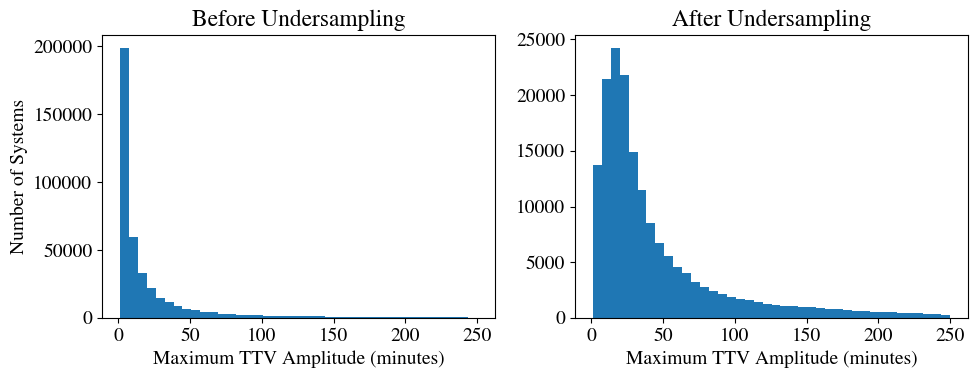

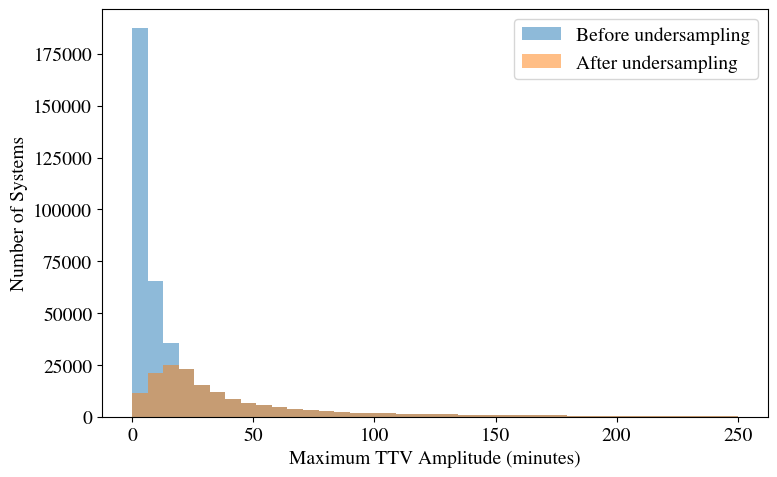

In [20]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ---------- load original ----------
with open(filepath+'datatrain_paper2_40k_250_raw_v2.pkl', 'rb') as f:
    data_raw = pickle.load(f)

ttv_raw = np.array(data_raw['ttv_data'])
amp_raw = np.max(np.abs(ttv_raw), axis=1)

# ---------- load filtered ----------
with open(filepath+'datatrain_paper2_20k_250_filtered.pkl', 'rb') as f:
    data_filtered = pickle.load(f)

ttv_filtered = np.array(data_filtered['ttv_data'])
amp_filtered = np.max(np.abs(ttv_filtered), axis=1)
fig, ax = plt.subplots(1,2,figsize=(10,4))

ax[0].hist(amp_raw,bins=40)
ax[0].set_title('Before Undersampling')
ax[0].set_xlabel('Maximum TTV Amplitude (minutes)')
ax[0].set_ylabel('Number of Systems')

ax[1].hist(amp_filtered,bins=40)
ax[1].set_title('After Undersampling')
ax[1].set_xlabel('Maximum TTV Amplitude (minutes)')

plt.tight_layout()
plt.savefig("undersampling.pdf", dpi =300, bbox_inches = 'tight')
plt.show()

# ---------- plot ----------
fig, ax = plt.subplots(figsize=(8,5))

bins = np.linspace(0,250,40)

ax.hist(
    amp_raw,
    bins=bins,
    alpha=0.5,
    label='Before undersampling'
)

ax.hist(
    amp_filtered,
    bins=bins,
    alpha=0.5,
    label='After undersampling'
)

ax.set_xlabel('Maximum TTV Amplitude (minutes)')
ax.set_ylabel('Number of Systems')
ax.legend()

plt.tight_layout()
plt.show()

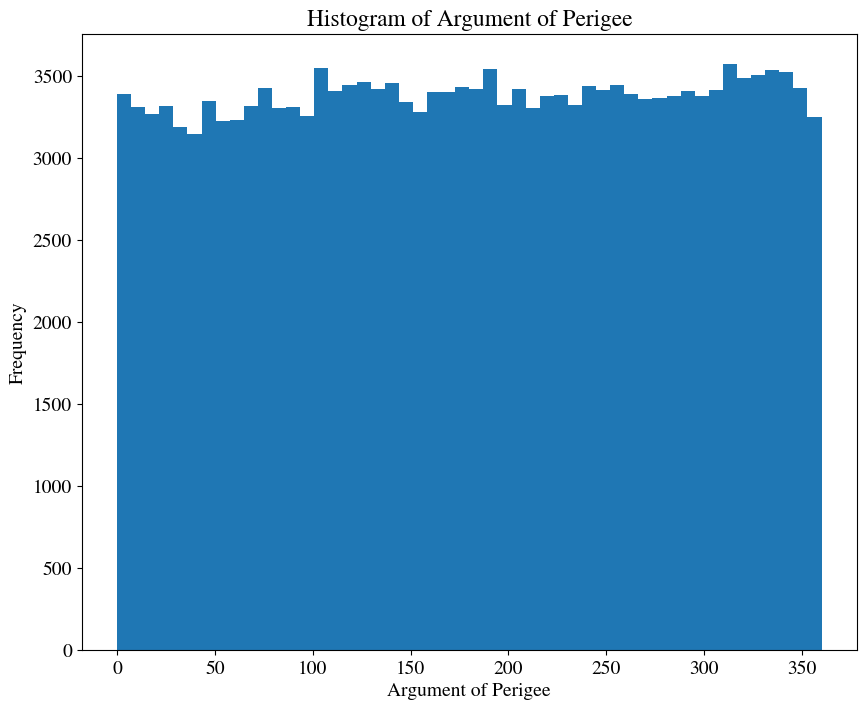

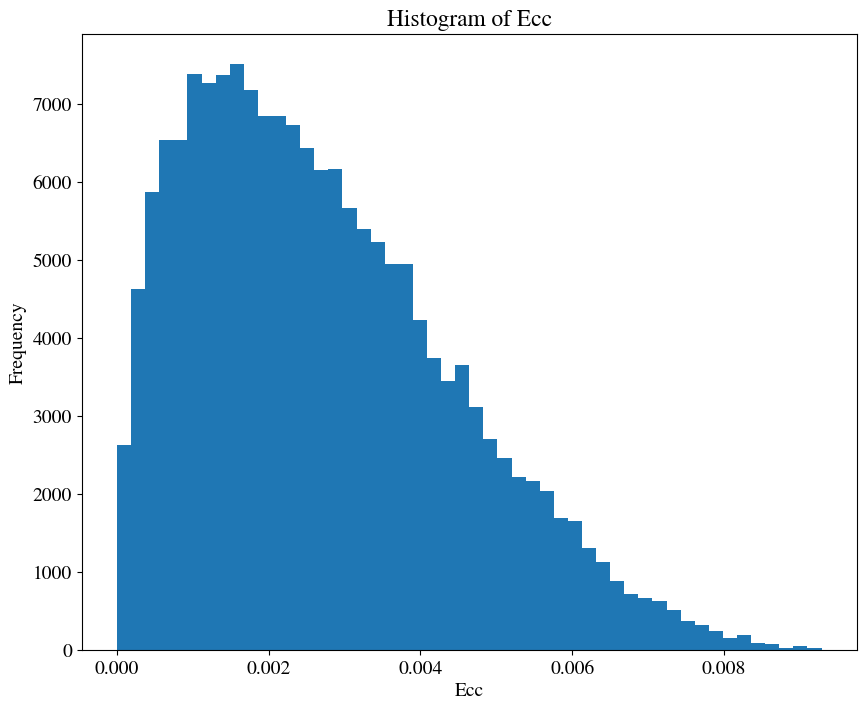

In [18]:
# prompt: plot histogram argument of perigee

plt.figure(figsize=(10,8))
plt.hist(perturbing_argument_perigee, bins=50)
plt.xlabel('Argument of Perigee')
plt.ylabel('Frequency')
plt.title('Histogram of Argument of Perigee')
plt.show()


plt.figure(figsize=(10,8))
plt.hist(perturbing_eccentricity, bins=50)
plt.xlabel('Ecc')
plt.ylabel('Frequency')
plt.title('Histogram of Ecc')
plt.show()

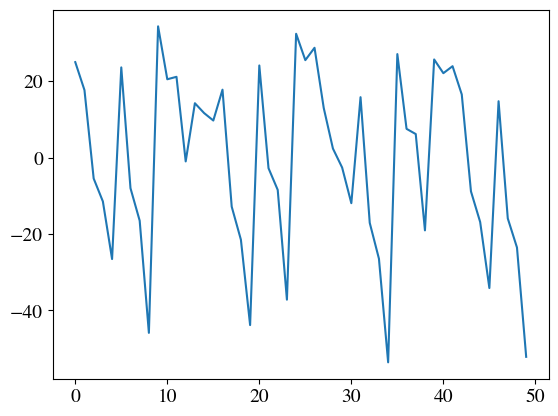

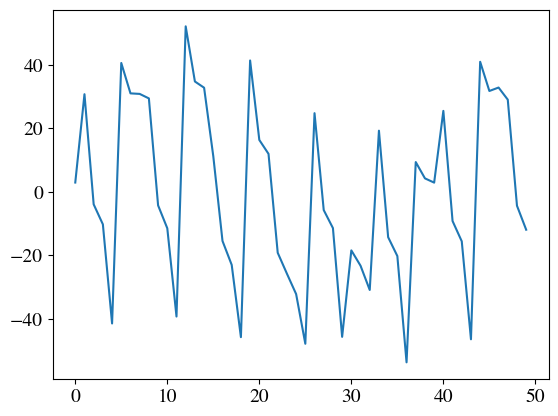

In [ ]:
max_ttv = ttv_data.max(1)
z = ttv_data
zs = z
plt.plot(zs[10])
plt.figure()
plt.plot(ttv_data[400])

Text(0, 0.5, 'N')

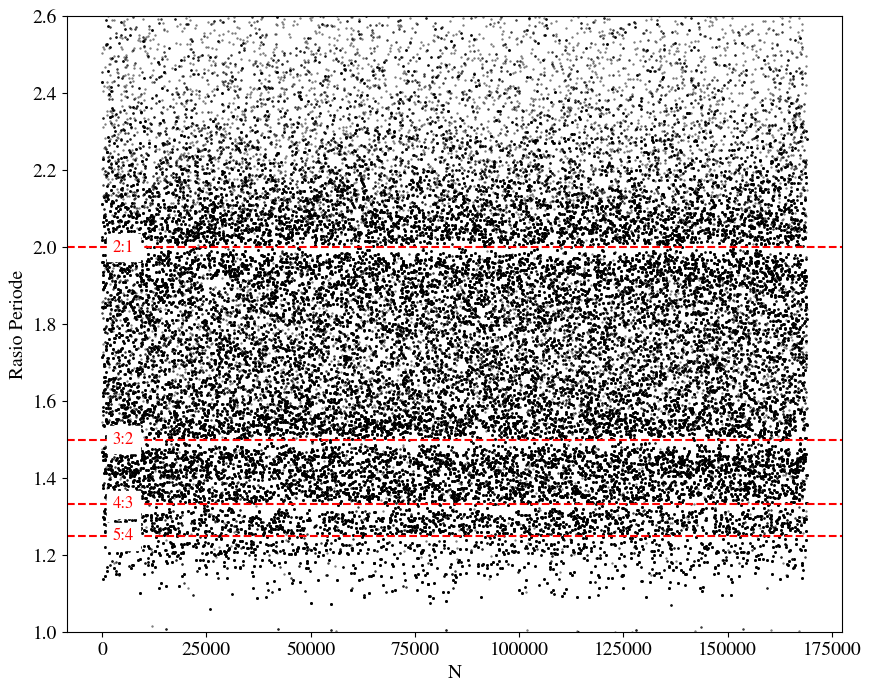

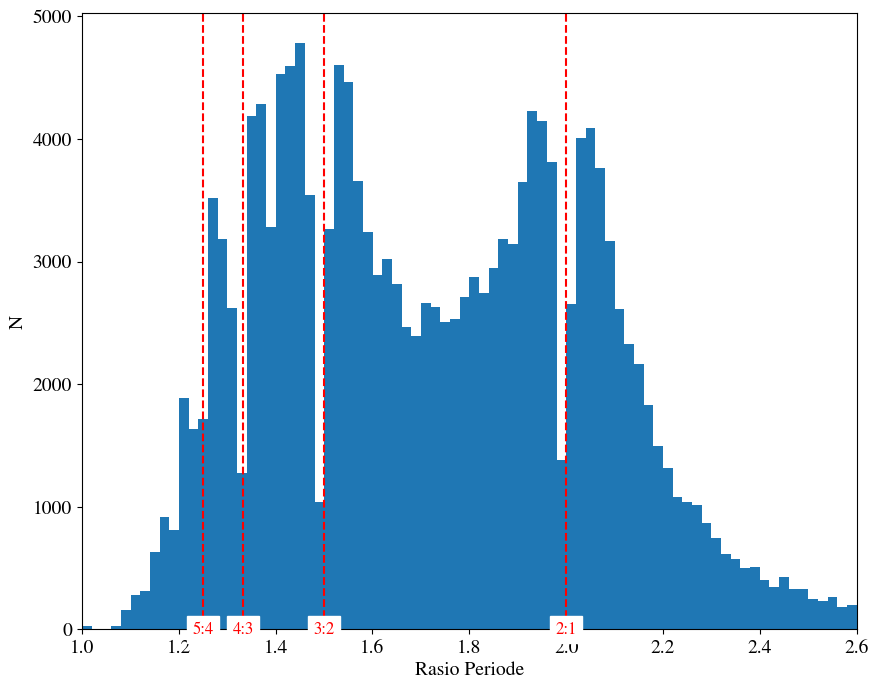

In [19]:
plt.figure(figsize=(10,8))
plt.plot(1/ratio, '+', alpha=0.5, markersize=1, color ='k')
# Add a horizontal line at y = 0.5
plt.axhline(y=2, color='red', linestyle='--')
plt.axhline(y=3/2, color='red', linestyle='--')
plt.axhline(y=5/4, color='red', linestyle='--')
plt.axhline(y=4/3, color='red', linestyle='--')
# Annotate the horizontal line directly on the line
maxh=5120
plt.text(maxh, 2, '2:1', color='red', fontsize=12,
         verticalalignment='center', horizontalalignment='center',
         backgroundcolor='white')
plt.text(maxh, 3/2, '3:2', color='red', fontsize=12,
         verticalalignment='center', horizontalalignment='center',
         backgroundcolor='white')
plt.text(maxh, 5/4, '5:4', color='red', fontsize=12,
         verticalalignment='center', horizontalalignment='center',
         backgroundcolor='white')
plt.text(maxh, 4/3, '4:3', color='red', fontsize=12,
         verticalalignment='center', horizontalalignment='center',
         backgroundcolor='white')
plt.ylim(1,2.6)
plt.ylabel('Rasio Periode')
plt.xlabel('N')

plt.figure(figsize=(10,8))
plt.hist(1/ratio, bins=100)
plt.axvline(x=2, color='red', linestyle='--')
plt.axvline(x=3/2, color='red', linestyle='--')
plt.axvline(x=5/4, color='red', linestyle='--')
plt.axvline(x=4/3, color='red', linestyle='--')
maxv=1
plt.text(2, maxv, '2:1', color='red', fontsize=12,
         verticalalignment='center', horizontalalignment='center',
         backgroundcolor='white')
plt.text(3/2, maxv, '3:2', color='red', fontsize=12,
         verticalalignment='center', horizontalalignment='center',
         backgroundcolor='white')
plt.text(5/4, maxv, '5:4', color='red', fontsize=12,
         verticalalignment='center', horizontalalignment='center',
         backgroundcolor='white')
plt.text( 4/3, maxv, '4:3', color='red', fontsize=12,
         verticalalignment='center', horizontalalignment='center',
         backgroundcolor='white')
plt.xlim(1,2.6)
plt.xlabel('Rasio Periode')
plt.ylabel('N')




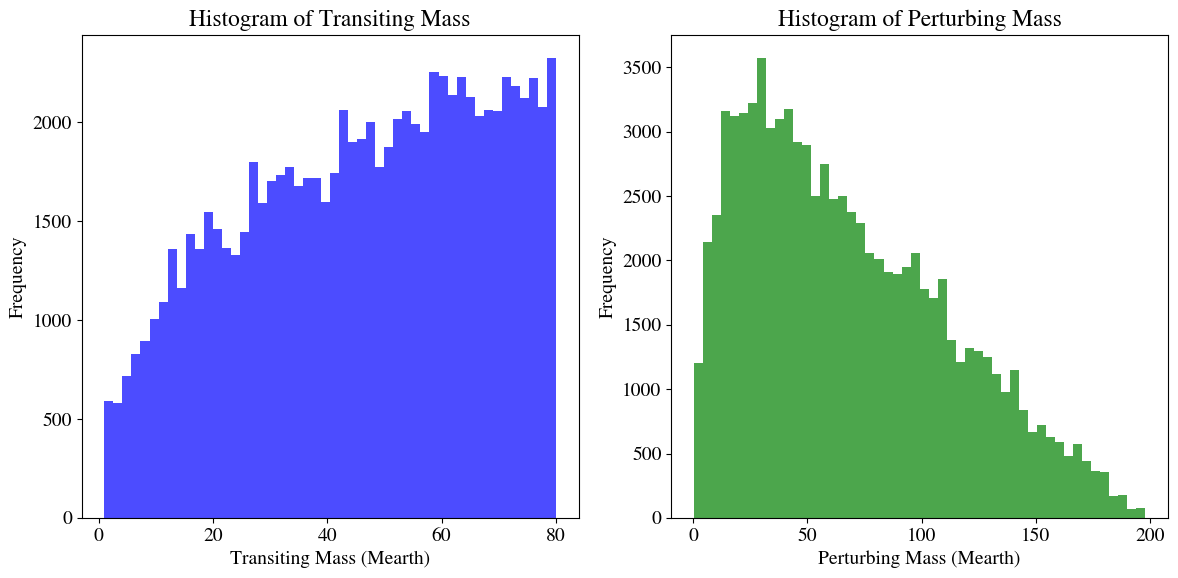

In [ ]:
# prompt: make histogram of transiting mass and perturbing mass

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Histogram of transiting mass
plt.subplot(1, 2, 1)
plt.hist(transiting_mass, bins=50, color='blue', alpha=0.7)
plt.title('Histogram of Transiting Mass')
plt.xlabel('Transiting Mass (Mearth)')
plt.ylabel('Frequency')

# Histogram of perturbing mass
plt.subplot(1, 2, 2)
plt.hist(perturbing_mass, bins=50, color='green', alpha=0.7)
plt.title('Histogram of Perturbing Mass')
plt.xlabel('Perturbing Mass (Mearth)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


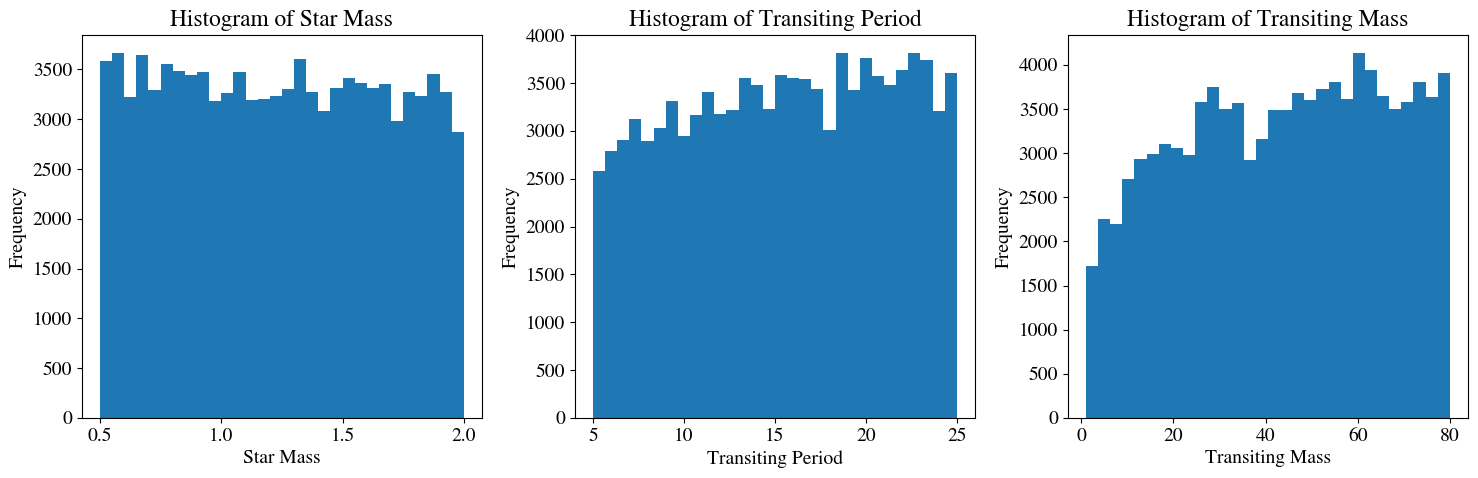

In [ ]:

import matplotlib.pyplot as plt

# Assuming 'star_mass', 'transiting_period', and 'transiting_mass' are defined as numpy arrays
# from the previous code block.

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(star_mass, bins=30)
axes[0].set_xlabel("Star Mass")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Histogram of Star Mass")

axes[1].hist(transiting_period, bins=30)
axes[1].set_xlabel("Transiting Period")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Histogram of Transiting Period")

axes[2].hist(transiting_mass, bins=30)
axes[2].set_xlabel("Transiting Mass")
axes[2].set_ylabel("Frequency")
axes[2].set_title("Histogram of Transiting Mass")

plt.tight_layout()
#plt.savefig(log_dir+'/'+"histogram_input_"+datatrain_name+model_name+".png", dpi=400,bbox_inches = 'tight')
plt.show()

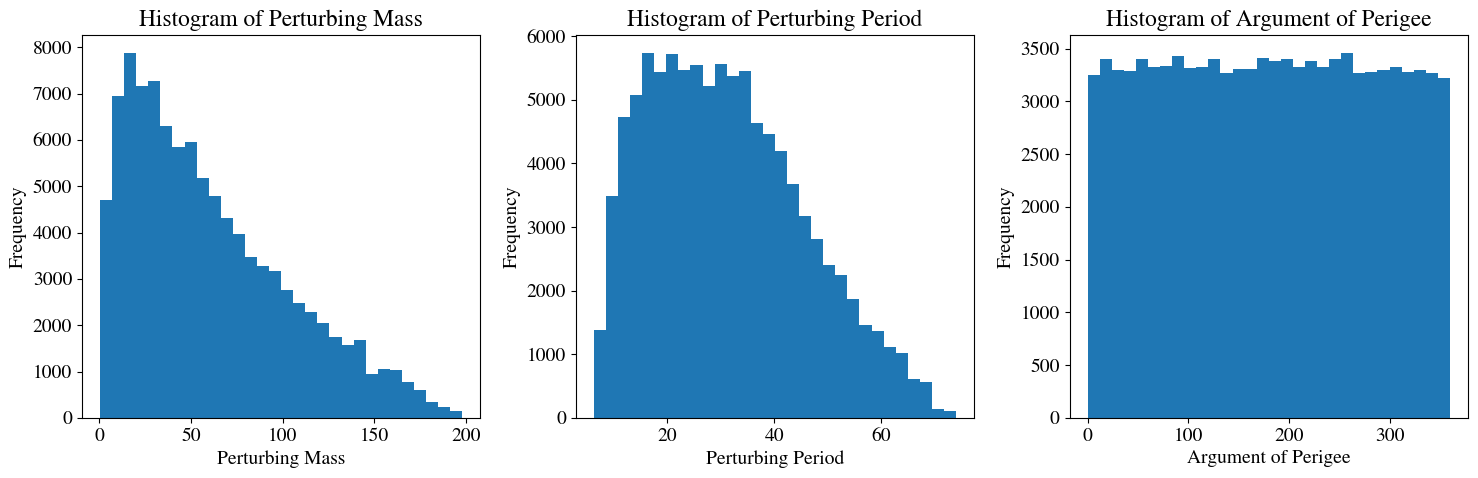

In [ ]:
# prompt: make subplot that plot the histogram of perturbing_mass, perturbing_period, argument of perigee

import matplotlib.pyplot as plt

# Assuming 'perturbing_mass', 'perturbing_period', and 'perturbing_argument_perigee' are defined as numpy arrays
# from the previous code block.

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(perturbing_mass, bins=30)
axes[0].set_xlabel("Perturbing Mass")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Histogram of Perturbing Mass")

axes[1].hist(perturbing_period, bins=30)
axes[1].set_xlabel("Perturbing Period")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Histogram of Perturbing Period")

axes[2].hist(perturbing_argument_perigee, bins=30)
axes[2].set_xlabel("Argument of Perigee")
axes[2].set_ylabel("Frequency")
axes[2].set_title("Histogram of Argument of Perigee")

plt.tight_layout()
#plt.savefig(log_dir+'/'+"histogram_output_"+datatrain_name+model_name+".png", dpi=400,bbox_inches = 'tight')
plt.show()

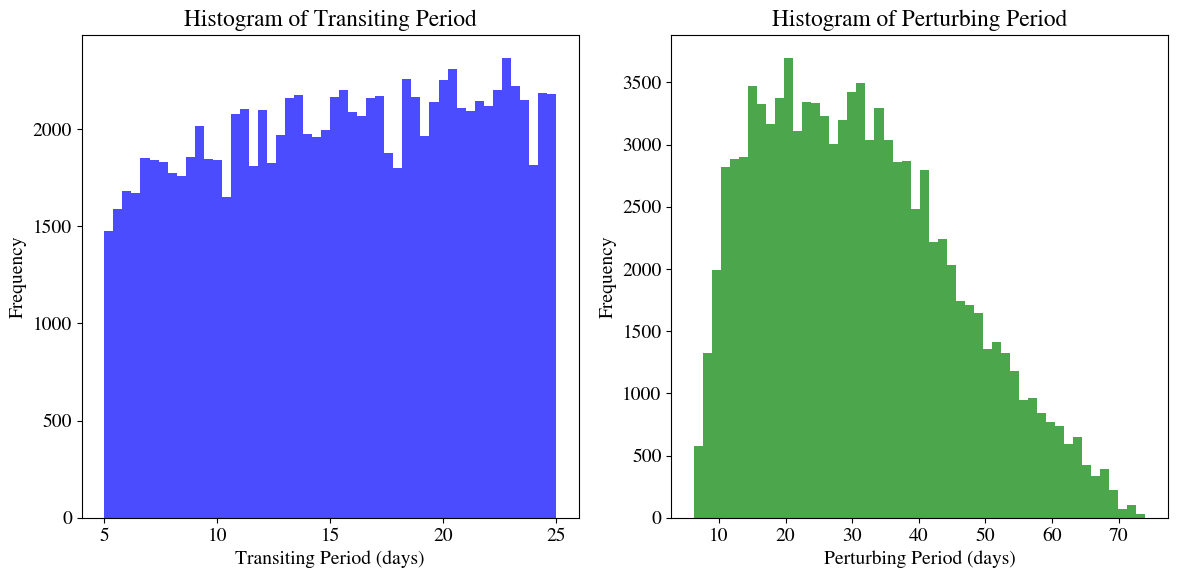

In [ ]:
# prompt: make a histogram for transiting period and perturbing period

plt.figure(figsize=(12, 6))

# Histogram of transiting period
plt.subplot(1, 2, 1)
plt.hist(transiting_period, bins=50, color='blue', alpha=0.7)
plt.title('Histogram of Transiting Period')
plt.xlabel('Transiting Period (days)')
plt.ylabel('Frequency')

# Histogram of perturbing period
plt.subplot(1, 2, 2)
plt.hist(perturbing_period, bins=50, color='green', alpha=0.7)
plt.title('Histogram of Perturbing Period')
plt.xlabel('Perturbing Period (days)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

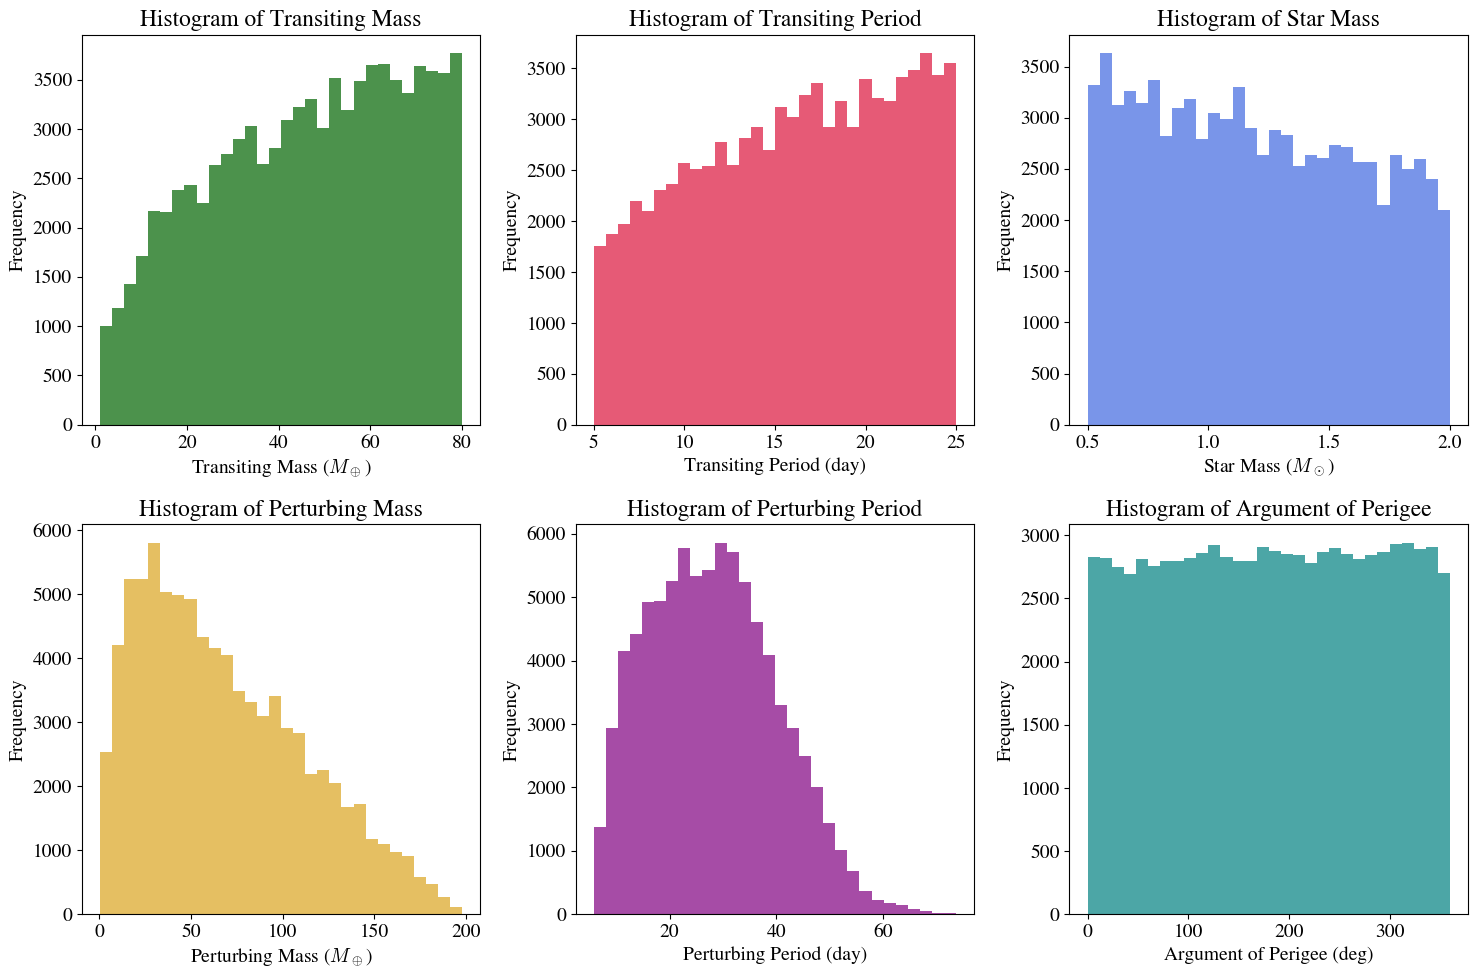

In [ ]:
import matplotlib.pyplot as plt

# Assuming all six variables are defined as numpy arrays
fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # 2 rows, 3 columns

# First row (Switched Star Mass and Transiting Mass)
axes[0, 0].hist(transiting_mass, bins=30, color='darkgreen', alpha=0.7)  # Switched with Star Mass
axes[0, 0].set_xlabel(r"Transiting Mass ($M_\oplus$)")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].set_title("Histogram of Transiting Mass")

axes[0, 1].hist(transiting_period, bins=30, color='crimson', alpha=0.7)
axes[0, 1].set_xlabel("Transiting Period (day)")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].set_title("Histogram of Transiting Period")

axes[0, 2].hist(star_mass, bins=30, color='royalblue', alpha=0.7)  # Switched with Transiting Mass
axes[0, 2].set_xlabel(r"Star Mass ($M_\odot$)")
axes[0, 2].set_ylabel("Frequency")
axes[0, 2].set_title("Histogram of Star Mass")

# Second row remains unchanged
axes[1, 0].hist(perturbing_mass, bins=30, color='goldenrod', alpha=0.7)
axes[1, 0].set_xlabel(r"Perturbing Mass ($M_\oplus$)")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].set_title("Histogram of Perturbing Mass")

axes[1, 1].hist(perturbing_period, bins=30, color='purple', alpha=0.7)
axes[1, 1].set_xlabel("Perturbing Period (day)")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].set_title("Histogram of Perturbing Period")

axes[1, 2].hist(perturbing_argument_perigee, bins=30, color='teal', alpha=0.7)
axes[1, 2].set_xlabel("Argument of Perigee (deg)")
axes[1, 2].set_ylabel("Frequency")
axes[1, 2].set_title("Histogram of Argument of Perigee")

plt.tight_layout()  # Adjust layout to prevent overlap
plt.savefig("histogram_dist.pdf", dpi =300, bbox_inches = 'tight')
plt.show()


In [ ]:
np.cos(90)

-0.4480736161291701

In [23]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pickle

# Load the dataset
#filename=datatrain_name+'.pkl'
with open(filename, 'rb') as f:
    data = pickle.load(f)

# Extracting data
limit = 200000
ttv_data = np.array(data['ttv_data'])[0:limit]
star_mass = np.array(data['star_mass'])[0:limit]
transiting_period = np.array(data['transiting_period'])[0:limit]
transiting_mass = np.array(data['transiting_mass'])[0:limit]

mass_output = np.array(data['perturbing_mass'])[0:limit]
period_output = np.array(data['perturbing_period'])[0:limit]
eccentricity_output = np.zeros(len(data['perturbing_eccentricity']))[0:limit]
argument_perigee_output = ((np.array(data['perturbing_argument_perigee'])[0:limit]))

ratio = transiting_period/period_output

mask = (ratio < 1)

#ax_list= np.amax(ttv_data, axis=1)
positive_ttv = np.where(mask)[0]
ttv_data = ttv_data[positive_ttv]
star_mass = star_mass[positive_ttv]
transiting_period = transiting_period[positive_ttv]
transiting_mass = transiting_mass[positive_ttv]

mass_output = mass_output[positive_ttv]
period_output = period_output[positive_ttv]
eccentricity_output = eccentricity_output[positive_ttv]
argument_perigee_output = argument_perigee_output[positive_ttv]


def add_noise(data, noise_factor=0.2):
    noise = np.random.normal(0,noise_factor*np.abs(data),data.shape) #noise_factor * data * np.random.normal(loc=0.0, scale=1.0, size=data.shape)
    return data + noise

ttv_data = add_noise(ttv_data, noise_factor=0.2)
# Reshape TTV data to be 3D (samples, timesteps, features)
n_timesteps = ttv_data.shape[1]
ttv_data = ttv_data.reshape((-1, n_timesteps, 1))

# ii = random.randint(0,80000)
# plt.plot(ttv_data[ii])
# plt.plot(ttv_data_[ii], 'o-')
# Normalize input features
scaler_ttv = MinMaxScaler()
scaler_star_mass = MinMaxScaler()
scaler_transiting_period = MinMaxScaler()
scaler_transiting_mass = MinMaxScaler()

# Fit and transform the training data
ttv_data = scaler_ttv.fit_transform(ttv_data.reshape(-1, 1)).reshape(ttv_data.shape)
star_mass = scaler_star_mass.fit_transform(star_mass.reshape(-1, 1)).reshape(star_mass.shape)
transiting_period = scaler_transiting_period.fit_transform(transiting_period.reshape(-1, 1)).reshape(transiting_period.shape)
transiting_mass = scaler_transiting_mass.fit_transform(transiting_mass.reshape(-1, 1)).reshape(transiting_mass.shape)

# Normalize output features if necessary
scaler_mass_output = MinMaxScaler()
scaler_period_output = MinMaxScaler()
scaler_eccentricity_output = MinMaxScaler()
scaler_argument_perigee_output = MinMaxScaler()

mass_output = scaler_mass_output.fit_transform(mass_output.reshape(-1, 1)).reshape(mass_output.shape)
period_output = scaler_period_output.fit_transform(period_output.reshape(-1, 1)).reshape(period_output.shape)
eccentricity_output = scaler_eccentricity_output.fit_transform(eccentricity_output.reshape(-1, 1)).reshape(eccentricity_output.shape)
argument_perigee_output = scaler_argument_perigee_output.fit_transform(argument_perigee_output.reshape(-1, 1)).reshape(argument_perigee_output.shape)

# Data augmentation: add noise to the TTV data
# def add_noise(data, noise_factor=0.2):
#     noise = noise_factor * np.random.normal(loc=0.0, scale=1.0, size=data.shape)
#     return data + noise


# Number of copies to augment
n_copies = 1

#augmented_ttv_data = np.concatenate([add_noise(ttv_data, noise_factor=0.02) for _ in range(n_copies)], axis=0)
augmented_ttv_data = np.concatenate([ttv_data for _ in range(n_copies)], axis=0)
augmented_star_mass = np.tile(star_mass, n_copies)
augmented_transiting_period = np.tile(transiting_period, n_copies)
augmented_transiting_mass = np.tile(transiting_mass, n_copies)

augmented_mass_output = np.tile(mass_output, n_copies)
augmented_period_output = np.tile(period_output, n_copies)
augmented_eccentricity_output = np.tile(eccentricity_output, n_copies)
augmented_argument_perigee_output = np.tile(argument_perigee_output, n_copies)

# Split into training and testing sets
from sklearn.model_selection import train_test_split

X_ttv_train, X_ttv_test = train_test_split(augmented_ttv_data, test_size=0.2, random_state=42)
X_star_mass_train, X_star_mass_test = train_test_split(augmented_star_mass, test_size=0.2, random_state=42)
X_transiting_period_train, X_transiting_period_test = train_test_split(augmented_transiting_period, test_size=0.2, random_state=42)
X_transiting_mass_train, X_transiting_mass_test = train_test_split(augmented_transiting_mass, test_size=0.2, random_state=42)

y_mass_train, y_mass_test = train_test_split(augmented_mass_output, test_size=0.2, random_state=42)
y_period_train, y_period_test = train_test_split(augmented_period_output, test_size=0.2, random_state=42)
y_eccentricity_train, y_eccentricity_test = train_test_split(augmented_eccentricity_output, test_size=0.2, random_state=42)
y_argument_perigee_train, y_argument_perigee_test = train_test_split(augmented_argument_perigee_output, test_size=0.2, random_state=42)

# Prepare inputs and outputs for the model
X_train_inputs = [X_ttv_train, X_star_mass_train, X_transiting_period_train, X_transiting_mass_train]
X_test_inputs = [X_ttv_test, X_star_mass_test, X_transiting_period_test, X_transiting_mass_test]

y_train_outputs = [y_mass_train, y_period_train,y_eccentricity_train, y_argument_perigee_train]
y_test_outputs = [y_mass_test, y_period_test,y_eccentricity_test, y_argument_perigee_test]

# Check the shapes
print("X_train shape:", [x.shape for x in X_train_inputs])
print("y_train shape:", [y.shape for y in y_train_outputs])


X_train shape: [(135164, 50, 1), (135164,), (135164,), (135164,)]
y_train shape: [(135164,), (135164,), (135164,), (135164,)]


In [25]:
from tensorflow.keras.layers import Input, Dense, LSTM, Bidirectional, Dropout, Conv1D, MaxPooling1D, Flatten, Reshape, concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2  # Import l2 regularizer
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, LSTM, Flatten, Concatenate, Dropout, BatchNormalization
from tensorflow.keras.layers import Conv1D, BatchNormalization, Dropout, GlobalAveragePooling1D

# Load the saved model and weights
# model_path = '/content/gdrive/MyDrive/S3/new_ml_model/exoplanet_ens_model_10k_noise5.keras'
# weights_path = '/content/gdrive/MyDrive/S3/new_ml_model/model_weights_ens_model_10k_noise5.h5'

# Define inputs
ttv_input = Input(shape=(n_timesteps, 1), name='ttv_input')
star_mass_input = Input(shape=(1,), name='star_mass_input')
transiting_period_input = Input(shape=(1,), name='transiting_period_input')
transiting_mass_input = Input(shape=(1,), name='transiting_mass_input')

# # # Convolutional layers
# x = Conv1D(filters=32, kernel_size=3, activation='relu')(ttv_input)
# x = MaxPooling1D(pool_size=2)(x)
# x = Conv1D(filters=64, kernel_size=3, activation='relu')(x)
# x = MaxPooling1D(pool_size=2)(x)
# x = Flatten()(x)
# x = Reshape((-1, 64))(x)

# LSTM layer
# ttv_lstm = LSTM(128, activation='tanh', return_sequences=True)(ttv_input) # Added return_sequences=True here
# ttv_lstm = BatchNormalization()(ttv_lstm)
# ttv_lstm = Dropout(0.1)(ttv_lstm)
# ttv_lstm = LSTM(128, return_sequences=False)(ttv_lstm)

# ttv_lstm = Bidirectional(LSTM(128, activation='tanh', return_sequences=True, dropout=0.3))(ttv_input)
# ttv_lstm = BatchNormalization()(ttv_lstm)  # Normalizes activations to stabilize training
# ttv_lstm = Dropout(0.3)(ttv_lstm)
# ttv_lstm = Bidirectional(LSTM(128, return_sequences=False, dropout=0.3))(ttv_lstm)


# # #CNN
# ttv_cnn = Conv1D(filters=32, kernel_size=5, activation='relu', padding='same')(ttv_input)  # First Conv1D layer
# ttv_cnn = Conv1D(filters=64, kernel_size=5, activation='relu', padding='same')(ttv_cnn)  # First Conv1D layer
# #ttv_cnn = Dropout(0.3)(ttv_cnn)
# ttv_cnn = BatchNormalization()(ttv_cnn)  # Normalizing the feature maps
# # # Adding dropout for regularization
# ttv_cnn = Conv1D(filters=128, kernel_size=5, activation='relu', padding='same')(ttv_cnn)  # Second Conv1D layer


# ttv_cnn = Flatten()(ttv_cnn)  # Flattening the feature maps for dense layers

# CNN equivalent of the LSTM stack
ttv_cnn = Conv1D(
    filters=128,
    kernel_size=5,
    activation='relu',
    padding='same'
)(ttv_input)

ttv_cnn = BatchNormalization()(ttv_cnn)
ttv_cnn = Dropout(0.1)(ttv_cnn)

ttv_cnn = Conv1D(
    filters=128,
    kernel_size=5,
    activation='relu',
    padding='same'
)(ttv_cnn)

# Sequence → feature vector (equivalent to return_sequences=False)
ttv_cnn = GlobalAveragePooling1D()(ttv_cnn)

star_mass_dense = Dense(8, activation='relu')(star_mass_input)

transiting_period_dense = Dense(8, activation='relu')(transiting_period_input)

transiting_mass_dense = Dense(8, activation='relu')(transiting_mass_input)

# Concatenate all inputs
merged = concatenate([ttv_cnn, star_mass_dense, transiting_period_dense, transiting_mass_dense])

# Fully connected layers
dense1 = Dense(128, activation='relu')(merged)
dense1 = Dropout(0.1)(dense1)

dense2 = Dense(64, activation='relu')(dense1)
dense2 = Dropout(0.2)(dense2)

dense3 = Dense(32, activation='relu')(dense2)
dense3 = Dropout(0.1)(dense3)
# You can add more dense layers as needed
dense4 = Dense(16, activation='relu')(dense3)
#dense4 = Dropout(0.3)(dense4)
dense5 = Dense(8, activation='relu')(dense4)
#dense4 = Dropout(0.3)(dense4)
# Output layers
mass_output = Dense(1, activation='linear',name='mass_output')(dense5)
period_output = Dense(1, activation='linear',name='period_output')(dense5)
eccentricity_output = Dense(1, activation='sigmoid', name='eccentricity_output')(dense5)
argument_perigee_output = Dense(1, activation='linear', name='argument_perigee_output')(dense5)
# # Concatenate all inputs
# merged = concatenate([ttv_lstm, star_mass_input, transiting_period_input, transiting_mass_input])

# # Fully connected layers with dropout and L2 regularization
# dense1 = Dense(64, activation='relu', kernel_regularizer=l2(0.01))(merged)
# dense1 = Dropout(0.5)(dense1)
# dense2 = Dense(32, activation='relu', kernel_regularizer=l2(0.01))(dense1)
# dense2 = Dropout(0.5)(dense2)

# # Output layers
# mass_output = Dense(1, activation='relu', name='mass_output')(dense2)
# period_output = Dense(1, activation='relu', name='period_output')(dense2)
# eccentricity_output = Dense(1, activation='sigmoid', name='eccentricity_output')(dense2)
# argument_perigee_output = Dense(1, name='argument_perigee_output')(dense2)

# Define the model
model = Model(inputs=[ttv_input, star_mass_input, transiting_period_input, transiting_mass_input],
              outputs=[mass_output, period_output,eccentricity_output, argument_perigee_output])

# Compile the model

def von_mises_loss(y_true, y_pred):
    # Convert to radians
    y_true_rad = y_true * 2.0 * np.pi
    y_pred_rad = y_pred * 2.0 * np.pi

    # Compute the angular difference
    delta = y_pred_rad - y_true_rad
    delta = tf.math.floormod(delta + np.pi, 2 * np.pi) - np.pi

    # Compute the loss based on the von Mises distribution
    return tf.reduce_mean(tf.exp(delta) - 1)

# model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
#               loss='mse',
#               metrics={'mass_output': 'mse',
#                        'period_output': 'mse',
#                        'eccentricity_output': 'mse',
#                        'argument_perigee_output': 'mse'})


mass_weight = 1.
period_weight = 1.
aop_weight = 1.
ecc_weight = 1.
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss={
                  'mass_output': 'mse',
                  'period_output': 'mse',
                  'eccentricity_output': 'mae',
                  'argument_perigee_output': 'mse'  # Custom angular loss for angles
              },
              metrics={
                  'mass_output': 'mse',
                  'period_output': 'mse',
                  'eccentricity_output': 'mae',
                  'argument_perigee_output': 'mse'
              },
              loss_weights={
                  'mass_output': mass_weight,                # Regular weight for mass
                  'period_output': period_weight,              # Regular weight for peiod
                  'eccentricity_output': ecc_weight,
                  'argument_perigee_output': aop_weight     # Higher weight for argument of perigee
              }
              )
model_name = "_LSTM_180k_3_jun"
# Callbacks for early stopping and learning rate reduction
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)


In [26]:
import os
import datetime
import json
import tensorflow as tf

def save_model_summary(model, log_dir):
    summary_path = os.path.join(log_dir, "model_summary"+datatrain_name+model_name+".txt")
    with open(summary_path, "w") as f:
        model.summary(print_fn=lambda x: f.write(x + "\n"))

def create_log_directory(base_dir="model_logs_CNN"):
    # Get the current timestamp
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    log_dir = os.path.join(base_dir, f"experiment_{timestamp}")
    os.makedirs(log_dir, exist_ok=True)
    return log_dir

log_dir = create_log_directory()

    # Save model summary
save_model_summary(model, log_dir)
tf.keras.utils.plot_model(model, to_file=log_dir+'/encoder'+str(model_name)+'.png', show_shapes=True, show_layer_names=False)
print(log_dir)

model_logs_CNN/experiment_2026-06-03_04-00-06


In [ ]:
log_dir = 'model_logs_LSTM/experiment_2025-03-20_11-16-37'
log_dir =filepath+'/model_logs_LSTM/experiment_2025-04-11_10-00-15'
log_dir = "/content/gdrive/MyDrive/S3/revisi_paper/revisi_paper/model_logs_CNN/experiment_2025-12-31_15-26-57" #FIX

In [27]:
# Open a text file in write mode
with open(log_dir+'/'+"shapes_output.txt", "w") as file:
    # Write the output to the file
    file.write("X_train shape: " + str([x.shape for x in X_train_inputs]) + "\n")
    file.write("y_train shape: " + str([y.shape for y in y_train_outputs]) + "\n")
    file.write("Weight = " + str(mass_weight) +', '+ str(period_weight) +', '+ str(aop_weight) +', '+ str(ecc_weight) +"\n")


In [ ]:
# model_ = '/content/gdrive/MyDrive/S3/new_ml_model/exoplanet_ens_model_15k_improve2.keras'
# model_ = tf.keras.models.load_model(model_)
# tf.keras.utils.plot_model(model_, to_file='encoder.png', show_shapes=True, show_layer_names=False)


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint
start_time = time.time()


# Define the checkpoint callback
filename=datatrain_name+model_name+'.pkl'
checkpoint = ModelCheckpoint(log_dir+'/'+'model_tanh_'+datatrain_name+model_name+'.weights.h5',
                             monitor='val_loss',
                             save_best_only=True,
                             save_weights_only=True,
                             verbose=1)

# Train the model
history = model.fit([X_ttv_train, X_star_mass_train, X_transiting_period_train, X_transiting_mass_train],
                    [y_mass_train, y_period_train, y_eccentricity_train, y_argument_perigee_train],
                    epochs=200, batch_size=64, validation_split=0.3,
                    callbacks=[early_stopping, reduce_lr, checkpoint],
                    verbose=1)

# Evaluate the model
results = model.evaluate([X_ttv_test, X_star_mass_test, X_transiting_period_test, X_transiting_mass_test],
                         [y_mass_test, y_period_test, y_eccentricity_test, y_argument_perigee_test])

# Save the model and history
model.save(log_dir+'/'+'exoplanet_ens_model_tanh_'+datatrain_name+model_name+'.keras')
model.save_weights(log_dir+'/'+'model_weights_ens_model_tanh_'+datatrain_name+model_name+'.weights.h5')

# Save the model
with open(log_dir+'/'+'history_tanh_'+datatrain_name+model_name+'.pkl', 'wb') as file_pi:
    pickle.dump(history.history, file_pi)

print('Test loss:', results[0])
print('Test MAE:', results[1])
print('Test MSE:', results[2])


end_time = time.time()
execution_time = end_time - start_time
ex_minutes = execution_time/60
print(f"Execution time: {execution_time:.6f} seconds")
print(f"Execution time: {ex_minutes:.6f} minutes")

Epoch 1/200
1478/1479 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - argument_perigee_output_loss: 0.0937 - argument_perigee_output_mse: 0.0937 - eccentricity_output_loss: 0.0688 - eccentricity_output_mae: 0.0688 - loss: 0.2304 - mass_output_loss: 0.0444 - mass_output_mse: 0.0444 - period_output_loss: 0.0236 - period_output_mse: 0.0236
Epoch 1: val_loss improved from None to 0.11753, saving model to model_logs_CNN/experiment_2026-06-03_04-00-06/model_tanh_datatrain_paper2_20k_250_filtered_LSTM_180k_3_jun.weights.h5

Epoch 1: finished saving model to model_logs_CNN/experiment_2026-06-03_04-00-06/model_tanh_datatrain_paper2_20k_250_filtered_LSTM_180k_3_jun.weights.h5
1479/1479 ━━━━━━━━━━━━━━━━━━━━ 105s 67ms/step - argument_perigee_output_loss: 0.0870 - argument_perigee_output_mse: 0.0870 - eccentricity_output_loss: 0.0163 - eccentricity_output_mae: 0.0163 - loss: 0.1488 - mass_output_loss: 0.0333 - mass_output_mse: 0.0333 - period_output_loss: 0.0123 - period_output_mse: 0.0123 - val_argument_perig

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ModelCheckpoint

# Load the model
# You can either load the entire model or only the weights.
# Define the checkpoint callback
checkpoint = ModelCheckpoint(log_dir+'/'+'exoplanet_ens_model_tanh_'+datatrain_name+model_name+'.weights.h5',
                             monitor='val_loss',
                             save_best_only=True,
                             save_weights_only=True,
                             verbose=1)

model.load_weights(log_dir+'/'+'model_weights_ens_model_tanh_'+datatrain_name+model_name+'.weights.h5')

# Continue training
# Continue training
history = model.fit([X_ttv_train, X_star_mass_train, X_transiting_period_train, X_transiting_mass_train],
                    [y_mass_train, y_period_train, y_argument_perigee_train],
                    initial_epoch=50,  # Start from epoch 25
                    epochs=100,  # Train till epoch 50
                    batch_size=32, validation_split=0.3,
                    callbacks=[early_stopping, reduce_lr, checkpoint],
                    verbose=1)


# Save the model and history
model.save(log_dir+'/'+'exoplanet_ens_model_tanh_'+datatrain_name+model_name+'.keras')
model.save_weights(log_dir+'/'+'model_weights_ens_model_tanh_'+datatrain_name+model_name+'.weights.h5')

# Load the saved history
with open(log_dir+'/'+'history_tanh_'+datatrain_name+model_name+'.pkl', 'rb') as file_pi:
    complete_history = pickle.load(file_pi)
# Append new history
for key, values in history.history.items():
    complete_history[key].extend(values)

# Save updated history
with open(log_dir+'/'+'history_tanh_'+datatrain_name+model_name+'.pkl', 'wb') as file_pi:
    pickle.dump(complete_history, file_pi)

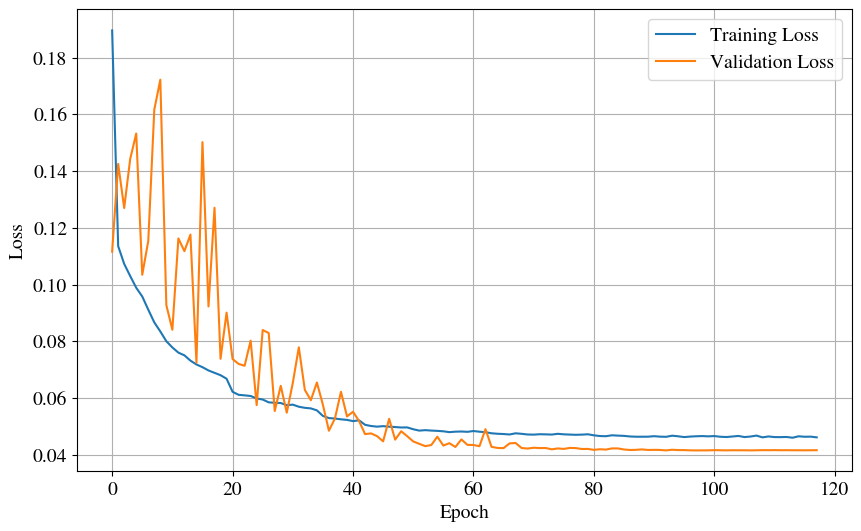

/content/gdrive/MyDrive/S3/revisi_paper/revisi_paper/model_logs_CNN/experiment_2025-12-31_15-26-57/exoplanet_ens_model_tanh_datatrain_paper2_10k_250_filtered_LSTM_16_Nov.keras


In [ ]:
import matplotlib.pyplot as plt

#model_ = '/content/gdrive/MyDrive/S3/new_ml_model/exoplanet_ens_model_50k_improve.keras'
model_ = log_dir+'/'+'exoplanet_ens_model_tanh_'+datatrain_name+model_name+'.keras'
with open(log_dir+'/'+'history_tanh_'+datatrain_name+model_name+'.pkl', 'rb') as file_pi:
    history = pickle.load(file_pi)

# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history['loss'][0:])
plt.plot(history['val_loss'][0:])
#plt.title('LSTM Model')
plt.ylabel('Loss')
plt.xlabel('Epoch')
#plt.ylim(0.1,0.2)
plt.legend(['Training Loss', 'Validation Loss'], loc='upper right')
plt.grid()
plt.savefig(str(model_[0:-6])+'_loss.pdf', dpi=300,bbox_inches = 'tight')
plt.show()

# If accuracy is a metric (e.g., for classification tasks)
if 'accuracy' in history:
    plt.figure(figsize=(12, 8))
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

# If other metrics are used, such as Mean Absolute Error (MAE)
if 'mae' in history:
    plt.figure(figsize=(12, 8))
    plt.plot(history.history['mae'], label='Training MAE')
    plt.plot(history.history['val_mae'], label='Validation MAE')
    plt.title('Model Mean Absolute Error')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.show()
print(model_)

### VALIDASI MODEL MENGGUNAKAN TTV SIMULASI


In [ ]:
import random
import math

def generate_random_resonance(min_val=2, max_val=8):
    while True:
        numerator = random.randint(min_val, max_val)
        denominator = random.randint(min_val, max_val)

        # Ensure the ratio is greater than 1
        if numerator != denominator:
            break

    # Simplify the ratio
    gcd = math.gcd(numerator, denominator)
    simplified_numerator = numerator // gcd
    simplified_denominator = denominator // gcd

    # Ensure the ratio is greater than 1 after simplification
    if simplified_numerator < simplified_denominator:
        simplified_numerator, simplified_denominator = simplified_denominator, simplified_numerator

    return simplified_numerator, simplified_denominator

# Example usage
resonance = generate_random_resonance()
print(f"The generated resonance ratio is {resonance[0]}:{resonance[1]}")
ratio = resonance[0]/resonance[1]
print(ratio)

The generated resonance ratio is 8:5
1.6


0.7408072485523873 5.21703479071593 18.93860741271289 4.60764594996253 38.60391411165316 0.00017467513701267207 220.16356163224543
The generated resonance ratio is 7:4


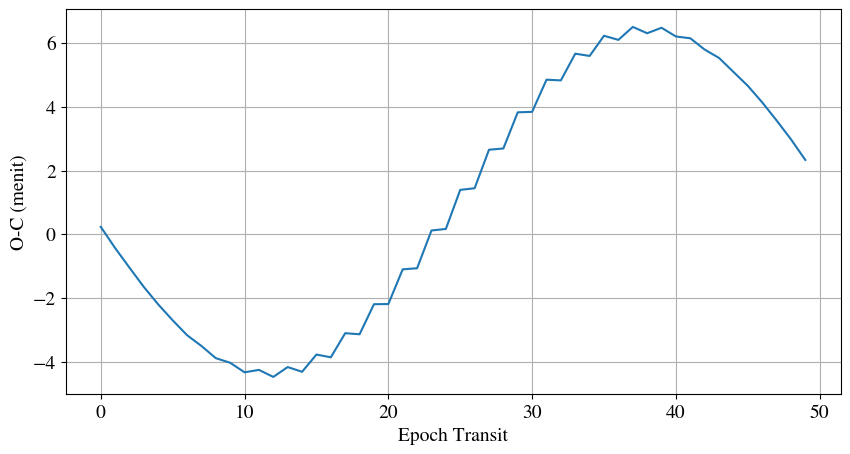

935778

In [ ]:
seeds= int(np.random.uniform(0,1e6))
#seeds = 362041
np.random.seed(seeds)


start_time = time.time()
n_sim=0
ext_time=[]
n_data=50
max_ttv = 150
min_ttv = 3
while n_sim < 1:
  resonance = generate_random_resonance()
  ratio = resonance[0]/resonance[1]
  base = random.uniform(1.0, 3.0)
  irrational_component = 0.01 * np.sqrt(2)
  non_resonant_ratio = base + irrational_component
  ms = np.random.uniform(0.5,2)
  m1 = np.random.uniform(1*mearth/msun, 100*mearth/msun)
  p1 = np.random.uniform(5,20)
  m2 = m1*np.random.uniform(0.5,2.)
  p2 = p1*generate_random_exclude_1(n=1, low=1, high = 3.)[0]#np.random.uniform(0.5,2.5)#
  o2 = np.random.uniform(0,360)
  #e2 = np.abs(np.random.normal(0,0.01))
  e2 = 0.001*beta.rvs(a=1.5, b=2)#np.abs(np.random.normal(0,0.01))

  # if m2 < 10*mearth/msun or m2 > 80*mearth/msun:
  #     continue
  # ms = 	0.761#0.936
  # p1 = 13.29# 9.28699
  # m1 = 	4.5 * mearth/msun
  # e1 = 0
  # p2 = 10.34#28.731
  # m2 = 5 * mearth/msun #13.1
  # o2 = 0
  # e2 =  0.

  # ms = 	0.8762127039179713 #1.304#0.936
  # p1 = 2.1682104337061094 #13.85# 9.28699
  # m1 = 	55.67454336103883  * mearth/msun #5.56
  # e1 = 0.
  # p2 = 4.416466614293909 #16#28.731
  # m2 = 69.31370932688336  * mearth/msun #13.1 9.61
  # o2 = 96
  # e2 =  0.

  ress = ttv_generate(ms=ms, p1=p1, m1=m1,p2=p2,m2=m2,o2=o2,e2=e2)
  transit=[]
  epoch=[]
  for i in range (len(ress['positions'][0])):
      if (ress['positions'][0][i]) == 0:
          if (ress['positions'][2][i]) != -2:
              transit.append(ress['positions'][2][i])
              epoch.append(ress['positions'][1][i])
  # if np.any(np.isnan(transit)):
  #     continue
  #print (len_x)
  #
  T1=TTV(epoch,transit)
  if (len(T1[0])) <= n_data or max(T1[0][:n_data]*24*60) > max_ttv or min(T1[0][:n_data]*24*60) < -max_ttv or max(T1[0][:n_data]*24*60) < min_ttv or min(T1[0][:n_data]*24*60) > -min_ttv :
    continue
  n_sim+=1

print(ms, m1 * msun/mearth, p1, m2* msun/mearth, p2, e2, o2)

print(f"The generated resonance ratio is {resonance[0]}:{resonance[1]}")
plt.figure(figsize=(10,5))
plt.plot(epoch[:50], T1[0][:50]*24*60,'-')
plt.ylabel ('O-C (menit)')
plt.xlabel('Epoch Transit')
plt.grid()
plt.show()
seeds

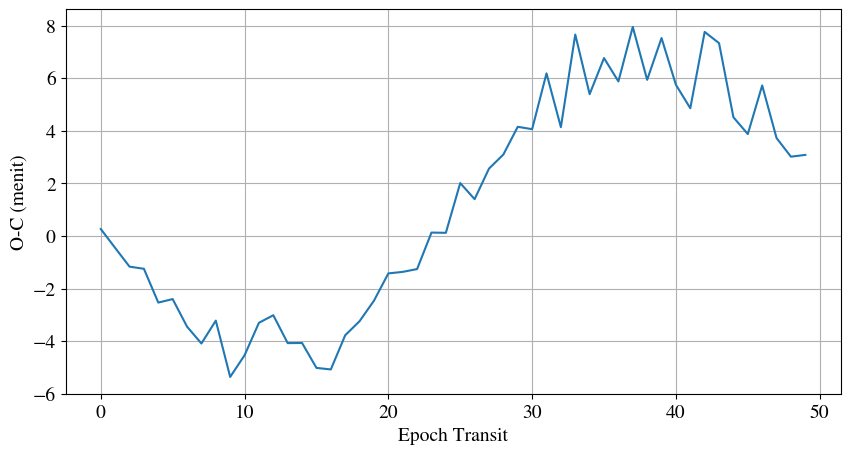

In [ ]:
Terr= T1[0][:50]*24*60
Terr = add_noise(Terr, noise_factor=0.2)

plt.figure(figsize=(10,5))
plt.plot(epoch[:50], Terr,'-')
plt.ylabel ('O-C (menit)')
plt.xlabel('Epoch Transit')
plt.grid()
plt.show()

In [ ]:
# orig_ttv = Terr
# corrupted_ttv = remove_points_and_interpolate(orig_ttv, 0.0)
# plt.plot(corrupted_ttv,'o-')

# # new_ttv_data = corrupted_ttv.reshape((1, 50, 1))
# # n_timesteps = new_ttv_data.shape[1]
# # n_timesteps
# print(orig_ttv)
# print(corrupted_ttv)

Predict WITH MISSING VALUE

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


# ===============================================================
# A. Load model
# ===============================================================
saved_model = load_model(model_, compile=False)
predict_fn = tf.function(lambda x, training: saved_model(x, training=training))

# ===============================================================
# B. Helper to remove random TTV points + interpolate back
# ===============================================================



# ===============================================================
# C. Inputs: your original true TTV + metadata
# ===============================================================
m_trans_pred = [(m1*msun/mearth)]

orig_ttv = Terr      # the original 50-point TTV
orig_star_mass = ms
orig_period = p1
orig_trans_mass = m1
print(orig_trans_mass)
# ===============================================================
# D. Missing data fractions to test
# ===============================================================
missing_fractions = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5,]

results = []

# ===============================================================
# E. MAIN LOOP OVER MISSING FRACTIONS
# ===============================================================
for frac in missing_fractions:

    print(f"\n\n==============================")
    print(f" Testing missing fraction = {frac}")
    print(f"==============================")


    corrupted_ttv = remove_points_and_interpolate(orig_ttv, frac)

    # reshape
    new_ttv_data = corrupted_ttv.reshape((1, 50, 1))
    #new_ttv_data = Terr#T1[0][:50] * 24 * 60  # Example data
    new_star_mass = orig_star_mass  # Example data
    new_transiting_period = orig_period  # Example data
    m_trans_pred = orig_trans_mass *(msun/mearth)
    new_transiting_mass = m_trans_pred # Example data

    # Reshape new_ttv_data to be 3D (samples, timesteps, features)
    n_timesteps = new_ttv_data.shape[1]
    new_ttv_data = new_ttv_data.reshape((1, n_timesteps, 1))

    # Ensure other inputs are arrays and match expected input dimensions
    new_star_mass = np.array(new_star_mass).reshape((1, 1))  # Assuming single sample
    new_transiting_period = np.array(new_transiting_period).reshape((1, 1))  # Assuming single sample
    new_transiting_mass = np.array(new_transiting_mass).reshape((1, 1))  # Assuming single sample

    # Normalize new data
    new_ttv_data = scaler_ttv.transform(new_ttv_data.reshape(-1, 1)).reshape(new_ttv_data.shape)
    new_star_mass = scaler_star_mass.transform(new_star_mass.reshape(-1, 1))
    new_transiting_period = scaler_transiting_period.transform(new_transiting_period.reshape(-1, 1))
    new_transiting_mass = scaler_transiting_mass.transform(new_transiting_mass.reshape(-1, 1))

    # Combine the inputs into the required format
    new_X_inputs = [new_ttv_data, new_star_mass, new_transiting_period, new_transiting_mass]
    # -----------------------------------------------
    # 1. Corrupt TTV by removing frac of values
    # -----------------------------------------------

    n_iter = 100
    print(f"Running {n_iter} stochastic forward passes...")

    # This list will hold 100 raw predictions.
    # Each prediction contains [Mass, Period, Ecc, Omega]
    raw_results = [predict_fn(new_X_inputs, training=True) for _ in range(n_iter)]

    # ---------------------------------------------------------
    # 3. PROCESS DATA (Corrected Logic)
    # ---------------------------------------------------------

    # Extract samples for each parameter into arrays of shape (100, 1)
    # We assume the model outputs order is: [Mass, Period, Ecc, Omega]
    # Adjust indices [0], [1], [2], [3] if your model output order is different.

    # Step A: Gather raw normalized data
    raw_mass = np.array([r[0].numpy() for r in raw_results]).reshape(n_iter, 1)
    raw_period = np.array([r[1].numpy() for r in raw_results]).reshape(n_iter, 1)
    raw_ecc = np.array([r[2].numpy() for r in raw_results]).reshape(n_iter, 1)
    raw_omega = np.array([r[3].numpy() for r in raw_results]).reshape(n_iter, 1)

    # Step B: Inverse Transform ALL 100 samples to Real Units FIRST
    # This is crucial for correct uncertainty calculation
    real_mass_samples = scaler_mass_output.inverse_transform(raw_mass)
    real_period_samples = scaler_period_output.inverse_transform(raw_period)
    real_ecc_samples = scaler_eccentricity_output.inverse_transform(raw_ecc)
    real_omega_samples = scaler_argument_perigee_output.inverse_transform(raw_omega)

    # Step C: Calculate Mean (Prediction) and Std Dev (Uncertainty) from Real Units
    predicted_mass = np.array([np.mean(real_mass_samples)])
    mass_uncertainty = np.array([np.std(real_mass_samples)])

    predicted_period = np.array([np.mean(real_period_samples)])
    period_uncertainty = np.array([np.std(real_period_samples)])

    predicted_eccentricity = np.array([np.mean(real_ecc_samples)])
    eccentricity_uncertainty = np.array([np.std(real_ecc_samples)])

    predicted_argument_perigee = np.array([np.mean(real_omega_samples)])
    argument_perigee_uncertainty = np.array([np.std(real_omega_samples)])

    # -----------------------------------------------
    # 7. Print & store
    # -----------------------------------------------
    # print(f"Mass:   {predicted_mass:.4f}  ± {mass_uncertainty:.4f}")
    # print(f"Period: {predicted_period:.4f}  ± {period_uncertainty:.4f}")
    # print(f"Ecc:    {predicted_eccentricity:.4f}  ± {eccentricity_uncertainty:.4f}")
    # print(f"Omega:  {predicted_argument_perigee:.4f}  ± {argument_perigee_uncertainty:.4f}")

    results.append({
        "missing_fraction": frac,
        "Mass_Pred": predicted_mass,
        "Mass_Unc": mass_uncertainty,
        "Period_Pred": predicted_period,
        "Period_Unc": period_uncertainty,
        "Ecc_Pred": predicted_eccentricity,
        "Ecc_Unc": eccentricity_uncertainty,
        "Omega_Pred": predicted_argument_perigee,
        "Omega_Unc": argument_perigee_uncertainty
    })

# final results as dataframe
df_results_missing = pd.DataFrame(results)
print(df_results_missing)


1.5664219090073172e-05


 Testing missing fraction = 0.0
Running 100 stochastic forward passes...


 Testing missing fraction = 0.1
Running 100 stochastic forward passes...


 Testing missing fraction = 0.2
Running 100 stochastic forward passes...


 Testing missing fraction = 0.3
Running 100 stochastic forward passes...


 Testing missing fraction = 0.4
Running 100 stochastic forward passes...


 Testing missing fraction = 0.5
Running 100 stochastic forward passes...
   missing_fraction    Mass_Pred     Mass_Unc  Period_Pred   Period_Unc  \
0               0.0   [7.431846]    [5.96984]  [38.919807]  [2.6711462]   
1               0.1   [7.735515]   [6.336074]  [38.838593]  [2.9439893]   
2               0.2  [7.5812397]   [6.166805]  [39.420307]   [2.866414]   
3               0.3    [7.40984]  [5.3541436]  [38.791035]  [3.1599278]   
4               0.4   [7.294063]  [5.1070523]  [39.075645]   [3.056824]   
5               0.5  [6.0559154]   [5.109684]  [38.441677]  [3.1418629]   

 

   missing_fraction    Mass_Pred     Mass_Unc  Period_Pred   Period_Unc  \
0               0.0   [7.431846]    [5.96984]  [38.919807]  [2.6711462]   
1               0.1   [7.735515]   [6.336074]  [38.838593]  [2.9439893]   
2               0.2  [7.5812397]   [6.166805]  [39.420307]   [2.866414]   
3               0.3    [7.40984]  [5.3541436]  [38.791035]  [3.1599278]   
4               0.4   [7.294063]  [5.1070523]  [39.075645]   [3.056824]   
5               0.5  [6.0559154]   [5.109684]  [38.441677]  [3.1418629]   

          Ecc_Pred          Ecc_Unc   Omega_Pred    Omega_Unc   Mass_Resid  \
0  [1.2301387e-08]  [2.5379608e-08]  [158.02567]  [15.404072]  [2.8242002]   
1  [1.4866053e-08]  [3.6255305e-08]   [158.9874]  [15.458745]  [3.1278691]   
2   [9.639699e-09]  [2.2553811e-08]  [156.96315]   [20.24382]  [2.9735937]   
3  [3.3248167e-08]  [1.7201802e-07]  [160.54701]  [15.734992]   [2.802194]   
4  [1.7859582e-08]  [5.0249607e-08]   [159.0018]  [14.540494]   [2.686417]   
5  [1.

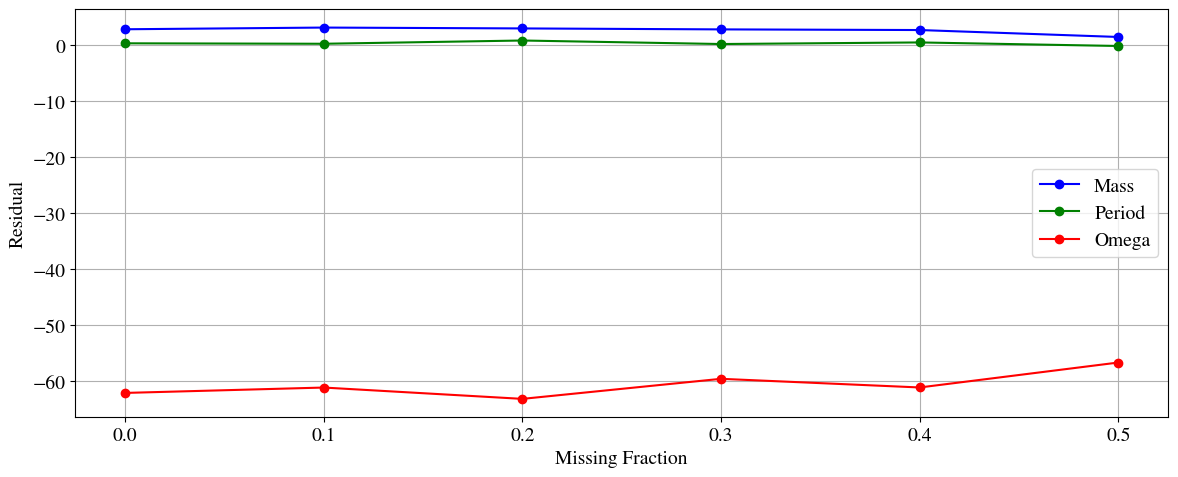

In [ ]:
import pandas as pd
import numpy as np

# Your results dataframe
df_results_missing = pd.DataFrame(results)

# Example true values (replace with your actual arrays)
Mass_True = np.full(len(df_results_missing), m2* msun/mearth)       # same length as df_results_missing
Period_True = np.full(len(df_results_missing), p2)
Ecc_True = np.full(len(df_results_missing), 0.0)
Omega_True = np.full(len(df_results_missing), o2)

# Compute residuals
df_results_missing['Mass_Resid'] = df_results_missing['Mass_Pred'] - Mass_True
df_results_missing['Period_Resid'] = df_results_missing['Period_Pred'] - Period_True
df_results_missing['Ecc_Resid'] = df_results_missing['Ecc_Pred'] - Ecc_True
df_results_missing['Omega_Resid'] = df_results_missing['Omega_Pred'] - Omega_True

# Optional: compute relative residuals
df_results_missing['Mass_Resid_rel'] = df_results_missing['Mass_Resid'] #/ Mass_True
df_results_missing['Period_Resid_rel'] = df_results_missing['Period_Resid'] #/ Period_True
df_results_missing['Ecc_Resid_rel'] = df_results_missing['Ecc_Resid'] #/ (Ecc_True + 1e-10)  # avoid div by zero
df_results_missing['Omega_Resid_rel'] = df_results_missing['Omega_Resid'] #/ Omega_True

# Print results
print(df_results_missing)

# Optional: plot residuals vs missing_fraction
plt.figure(figsize=(12, 5))

# Parameters to plot
params = ['Mass', 'Period', 'Omega']
colors = ['blue', 'green', 'red']

for param, color in zip(params, colors):
    plt.plot(df_results_missing['missing_fraction'],
                 (df_results_missing[f'{param}_Resid_rel']),
                 #yerr=df_results_missing[f'{param}_Unc'],
                 'o-',  label=param, color=color)

plt.xlabel('Missing Fraction')
plt.ylabel('Residual')
#plt.title('Residuals vs Missing Fraction')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("missing_data_analysis.pdf", dpi= 300, bbox_inches = 'tight')
plt.show()

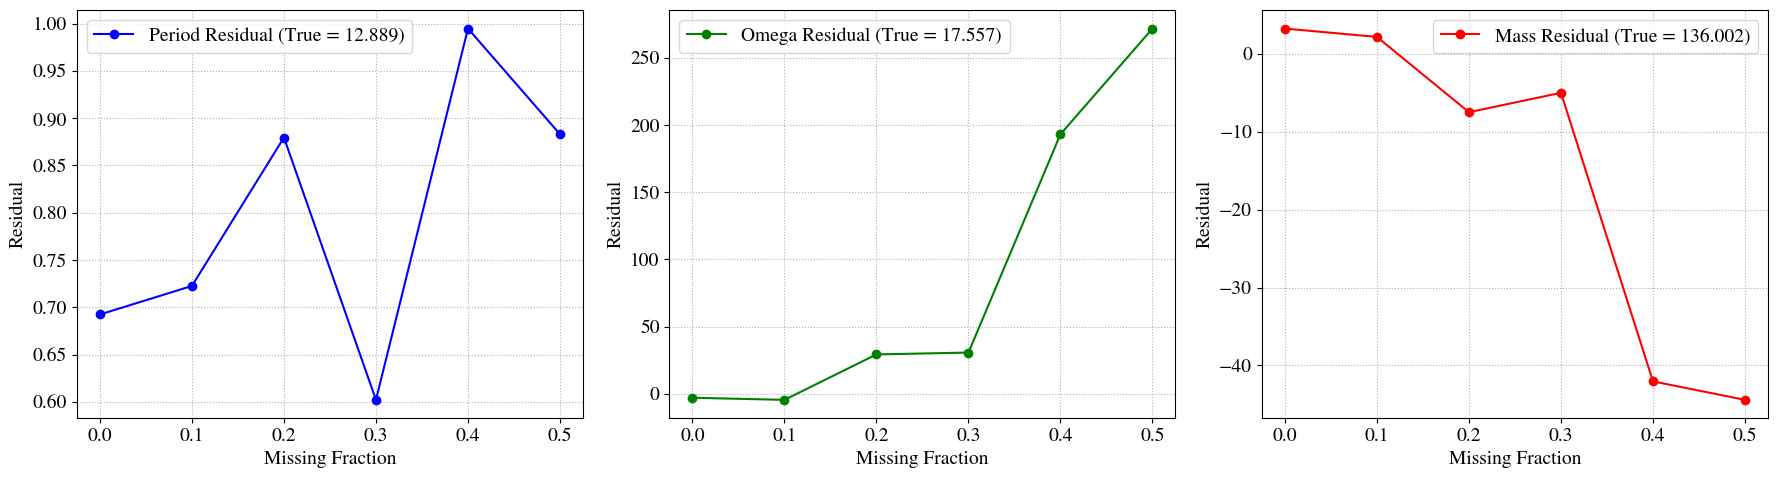

In [ ]:
import matplotlib.pyplot as plt

params = [ 'Period', 'Omega','Mass']
colors = ['blue', 'green', 'red']
true_values = [ Period_True[0], Omega_True[0], Mass_True[0]]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.subplots_adjust(wspace=0.3)

for ax, param, color, true_val in zip(axes, params, colors, true_values):
    ax.plot(df_results_missing['missing_fraction'],
            df_results_missing[f'{param}_Resid_rel'],
            'o-', color=color,
            label=f"{param} Residual (True = {true_val:.3f})")

    ax.set_xlabel('Missing Fraction')
    ax.set_ylabel('Residual')
    #ax.set_title(f'{param} Residual vs Missing Fraction')
    ax.grid(True, linestyle=':')
    ax.legend()

plt.tight_layout()
plt.savefig("missing_data_analysis_subplots_with_true.pdf", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
true_values

[array([136.0022073, 136.0022073, 136.0022073, 136.0022073, 136.0022073,
        136.0022073]),
 array([12.88855947, 12.88855947, 12.88855947, 12.88855947, 12.88855947,
        12.88855947]),
 array([17.5570464, 17.5570464, 17.5570464, 17.5570464, 17.5570464,
        17.5570464])]

In [ ]:
# import tensorflow as tf

# # Define a function to enable dropout during inference
# def predict_with_uncertainty(f, x, n_iter=100):
#     result = [f(x, training=False) for _ in range(n_iter)]
#     result = np.array(result)
#     prediction = result.mean(axis=0)
#     uncertainty = result.std(axis=0)
#     return prediction, uncertainty

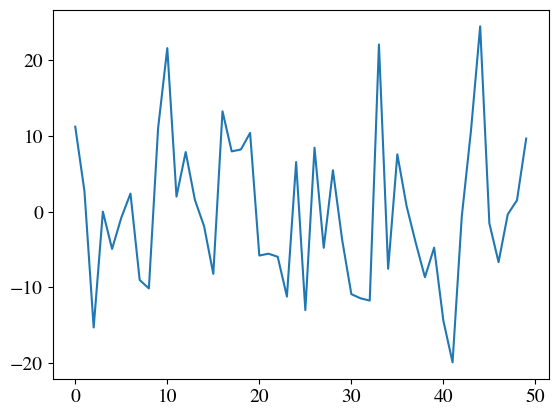

In [ ]:
noise_rms =10.0   # set the amplitude of the noise
ttv_noise = np.random.normal(0, noise_rms, 50)
plt.plot(ttv_noise)

In [ ]:
#model_ = log_dir+'/'+'exoplanet_ens_model_tanh_'+datatrain_name+model_name+'.keras'

In [ ]:
from tensorflow.keras.models import load_model
import numpy as np

# Load the saved model with dropout layers
#model_ = '/content/gdrive/MyDrive/S3/new_ml_model/exoplanet_ens_model_10k.keras'
#model_ = '/content/gdrive/MyDrive/S3/new_ml_model/exoplanet_ens_model_15k.keras'
#model_ = '/content/gdrive/MyDrive/S3/new_ml_model/exoplanet_ens_model_10k_noise5.keras'
#model_ = '/content/gdrive/MyDrive/S3/new_ml_model/exoplanet_ens_model_improve.keras'

saved_model = load_model(model_, compile=False)

# Define the function for predicting with uncertainty
predict_fn = tf.function(lambda x, training: saved_model(x, training=training))

# Assuming new data is available in the same format as the training data
# Example new data for prediction

noise_rms = 10.0   # set the amplitude of the noise
#Terr = np.random.normal(0, noise_rms, 50)
new_ttv_data = Terr#T1[0][:50] * 24 * 60  # Example data
new_star_mass = [ms]  # Example data
new_transiting_period = [p1]  # Example data
m_trans_pred = [(m1*msun/mearth)]
new_transiting_mass = m_trans_pred # Example data

# Reshape new_ttv_data to be 3D (samples, timesteps, features)
n_timesteps = new_ttv_data.shape[0]
new_ttv_data = new_ttv_data.reshape((1, n_timesteps, 1))

# Ensure other inputs are arrays and match expected input dimensions
new_star_mass = np.array(new_star_mass).reshape((1, 1))  # Assuming single sample
new_transiting_period = np.array(new_transiting_period).reshape((1, 1))  # Assuming single sample
new_transiting_mass = np.array(new_transiting_mass).reshape((1, 1))  # Assuming single sample

# Normalize new data
new_ttv_data = scaler_ttv.transform(new_ttv_data.reshape(-1, 1)).reshape(new_ttv_data.shape)
new_star_mass = scaler_star_mass.transform(new_star_mass.reshape(-1, 1))
new_transiting_period = scaler_transiting_period.transform(new_transiting_period.reshape(-1, 1))
new_transiting_mass = scaler_transiting_mass.transform(new_transiting_mass.reshape(-1, 1))

# Combine the inputs into the required format
new_X_inputs = [new_ttv_data, new_star_mass, new_transiting_period, new_transiting_mass]

# Predict with uncertainty
predictions, uncertainties = predict_with_uncertainty(predict_fn, new_X_inputs, n_iter=100)

# The predictions and uncertainties will be lists of arrays corresponding to each output
predicted_mass = scaler_mass_output.inverse_transform(predictions[0])[0]
predicted_period = scaler_period_output.inverse_transform(predictions[1])[0]
predicted_eccentricity = scaler_eccentricity_output.inverse_transform(predictions[2])[0]
predicted_argument_perigee = scaler_argument_perigee_output.inverse_transform(predictions[3])[0]
#predicted_argument_perigee = ((predicted_argument_perigee))


mass_uncertainty = scaler_mass_output.inverse_transform(uncertainties[0])[0]
period_uncertainty = scaler_period_output.inverse_transform(uncertainties[1])[0]
eccentricity_uncertainty = scaler_eccentricity_output.inverse_transform(uncertainties[2])[0]
argument_perigee_uncertainty = scaler_argument_perigee_output.inverse_transform(uncertainties[3])[0]
#argument_perigee_uncertainty = ((argument_perigee_uncertainty))

# Print the predictions and uncertainties
print("Predicted mass of perturbing planet:", predicted_mass, "±", mass_uncertainty)
print("Predicted period of perturbing planet:", predicted_period, "±", period_uncertainty)
print("Predicted eccentricity of perturbing planet:", predicted_eccentricity, "±", eccentricity_uncertainty)
print("Predicted argument of perigee of perturbing planet:", predicted_argument_perigee, "±", argument_perigee_uncertainty)



Predicted mass of perturbing planet: [8.311588] ± [6.1533327]
Predicted period of perturbing planet: [38.751503] ± [8.852961]
Predicted eccentricity of perturbing planet: [1.9074621e-08] ± [8.7662436e-08]
Predicted argument of perigee of perturbing planet: [154.91966] ± [13.539725]


#NEW PREDICT

Running 100 stochastic forward passes...
Predicted mass of perturbing planet: [7.4583306] ± [6.1563125]
Predicted period of perturbing planet: [38.08721] ± [3.343153]
Predicted eccentricity of perturbing planet: [1.0431276e-08] ± [1.877735e-08]
Predicted argument of perigee of perturbing planet: [155.12897] ± [15.745769]


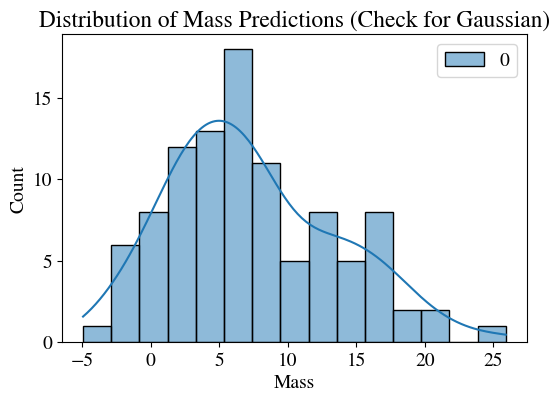

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model

# ---------------------------------------------------------
# 1. SETUP
# ---------------------------------------------------------
# Load model
# model_path = '...'
saved_model = load_model(model_, compile=False)
predict_fn = tf.function(lambda x, training: saved_model(x, training=training))

# ---------------------------------------------------------
# 2. RUN MC DROPOUT (Collect Raw Samples)
# ---------------------------------------------------------
n_iter = 100
print(f"Running {n_iter} stochastic forward passes...")

# This list will hold 100 raw predictions.
# Each prediction contains [Mass, Period, Ecc, Omega]
raw_results = [predict_fn(new_X_inputs, training=True) for _ in range(n_iter)]

# ---------------------------------------------------------
# 3. PROCESS DATA (Corrected Logic)
# ---------------------------------------------------------

# Extract samples for each parameter into arrays of shape (100, 1)
# We assume the model outputs order is: [Mass, Period, Ecc, Omega]
# Adjust indices [0], [1], [2], [3] if your model output order is different.

# Step A: Gather raw normalized data
raw_mass = np.array([r[0].numpy() for r in raw_results]).reshape(n_iter, 1)
raw_period = np.array([r[1].numpy() for r in raw_results]).reshape(n_iter, 1)
raw_ecc = np.array([r[2].numpy() for r in raw_results]).reshape(n_iter, 1)
raw_omega = np.array([r[3].numpy() for r in raw_results]).reshape(n_iter, 1)

# Step B: Inverse Transform ALL 100 samples to Real Units FIRST
# This is crucial for correct uncertainty calculation
real_mass_samples = scaler_mass_output.inverse_transform(raw_mass)
real_period_samples = scaler_period_output.inverse_transform(raw_period)
real_ecc_samples = scaler_eccentricity_output.inverse_transform(raw_ecc)
real_omega_samples = scaler_argument_perigee_output.inverse_transform(raw_omega)

# Step C: Calculate Mean (Prediction) and Std Dev (Uncertainty) from Real Units
predicted_mass = np.array([np.mean(real_mass_samples)])
mass_uncertainty = np.array([np.std(real_mass_samples)])

predicted_period = np.array([np.mean(real_period_samples)])
period_uncertainty = np.array([np.std(real_period_samples)])

predicted_eccentricity = np.array([np.mean(real_ecc_samples)])
eccentricity_uncertainty = np.array([np.std(real_ecc_samples)])

predicted_argument_perigee = np.array([np.mean(real_omega_samples)])
argument_perigee_uncertainty = np.array([np.std(real_omega_samples)])

# ---------------------------------------------------------
# 4. PRINT RESULTS (Formatted exactly as requested)
# ---------------------------------------------------------

print("Predicted mass of perturbing planet:", predicted_mass, "±", mass_uncertainty)
print("Predicted period of perturbing planet:", predicted_period, "±", period_uncertainty)
print("Predicted eccentricity of perturbing planet:", predicted_eccentricity, "±", eccentricity_uncertainty)
print("Predicted argument of perigee of perturbing planet:", predicted_argument_perigee, "±", argument_perigee_uncertainty)

# ---------------------------------------------------------
# OPTIONAL: Check the Gaussian Distribution for Mass (For the Reviewer)
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.histplot(real_mass_samples, kde=True, bins=15)
plt.title("Distribution of Mass Predictions (Check for Gaussian)")
plt.xlabel("Mass")
plt.show()

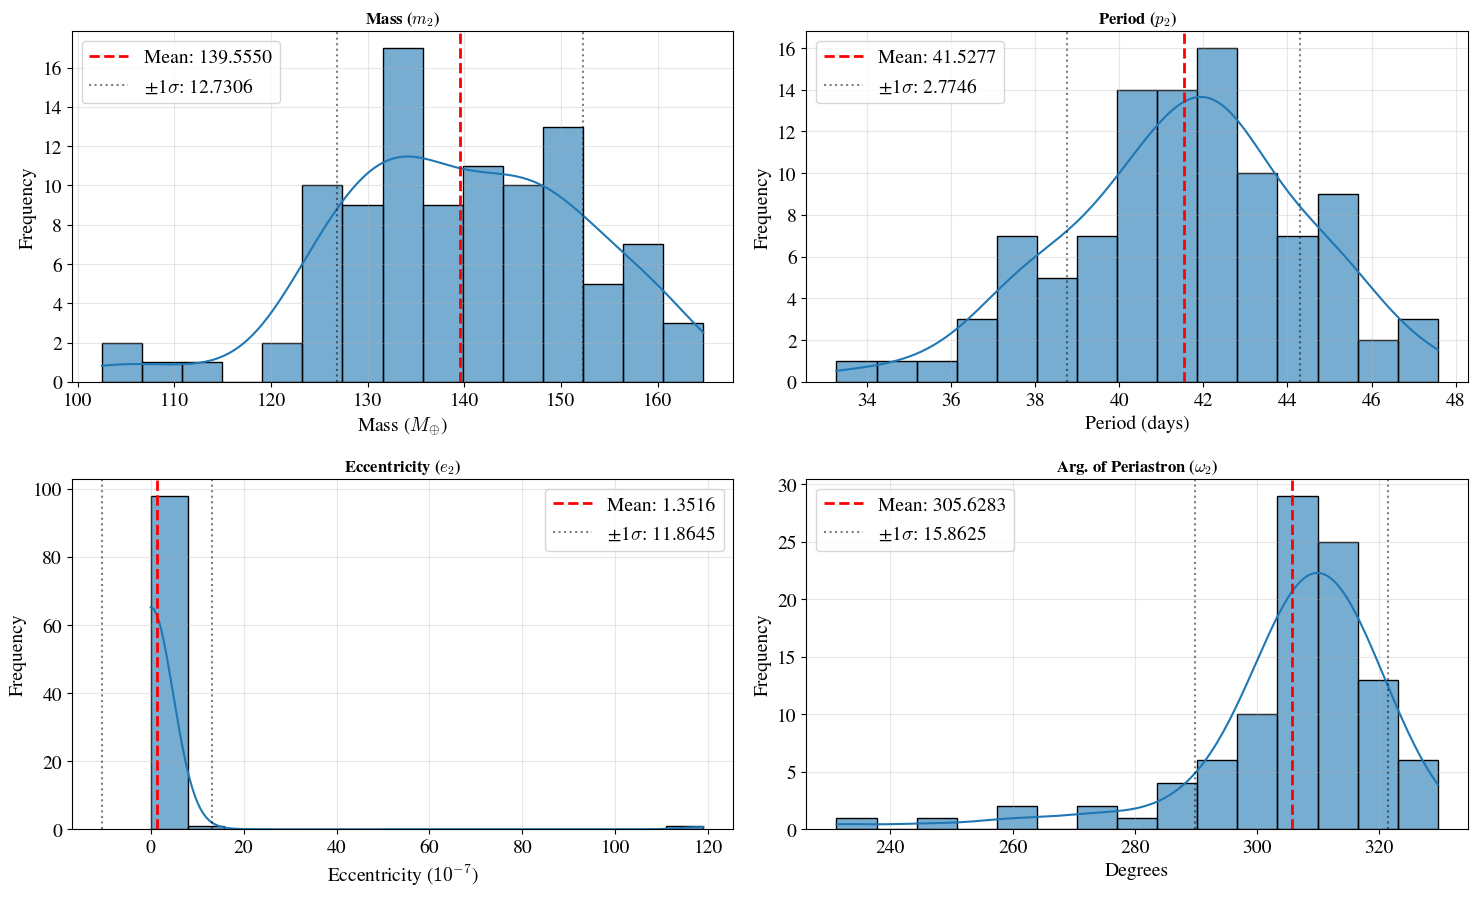

In [ ]:


# ==============================================================================
# EXECUTION
# ==============================================================================
# Ensure you have run the previous prediction step to get 'real_mass_samples' etc.
plot_parameter_distributions(real_mass_samples,
                             real_period_samples,
                             real_ecc_samples,
                             real_omega_samples)

409

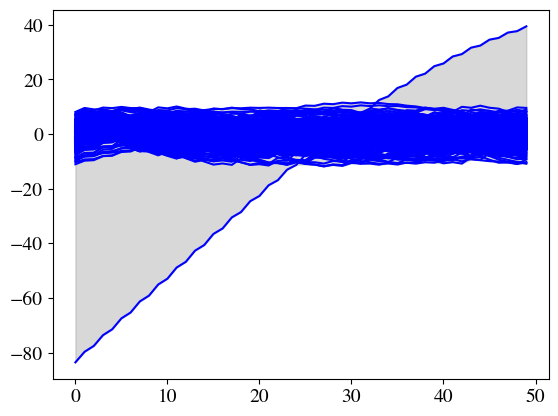

In [ ]:
#TTVs Uncertainties

mpred_unc = abs(np.array([predicted_mass - mass_uncertainty, predicted_mass, predicted_mass + mass_uncertainty]))
ppred_unc = np.array([predicted_period - period_uncertainty, predicted_period, predicted_period + period_uncertainty])
epred_unc = np.zeros(len(np.array([predicted_eccentricity - eccentricity_uncertainty, predicted_eccentricity, predicted_eccentricity + eccentricity_uncertainty])))
opred_unc = np.array([predicted_argument_perigee - argument_perigee_uncertainty, predicted_argument_perigee, predicted_argument_perigee + argument_perigee_uncertainty])
n_unc = 500
# mpred_unc = abs(np.linspace(predicted_mass - mass_uncertainty, predicted_mass + mass_uncertainty, n_unc))
# ppred_unc = np.linspace(predicted_period - period_uncertainty, predicted_period + period_uncertainty, n_unc)
# epred_unc = np.linspace(predicted_eccentricity - eccentricity_uncertainty, predicted_eccentricity + eccentricity_uncertainty, n_unc)
# opred_unc = np.linspace(predicted_argument_perigee - argument_perigee_uncertainty, predicted_argument_perigee + argument_perigee_uncertainty, n_unc)

# mpred_unc = np.random.uniform(predicted_mass - mass_uncertainty, predicted_mass + mass_uncertainty, size=n_unc).tolist()
# ppred_unc = np.random.uniform(predicted_period - period_uncertainty, predicted_period + period_uncertainty, size=n_unc).tolist()
# epred_unc = np.zeros(len(np.random.uniform(predicted_eccentricity - eccentricity_uncertainty, predicted_eccentricity + eccentricity_uncertainty, size=n_unc).tolist()))
# opred_unc = np.random.uniform(predicted_argument_perigee - argument_perigee_uncertainty, predicted_argument_perigee + argument_perigee_uncertainty, size=n_unc).tolist()

n_data=50

all_TTV=[]
all_epoch=[]
index_unc = []

mpred_unc = []
ppred_unc = []
opred_unc = []

for j in range (n_unc):
    p2_unc = abs(np.random.uniform(predicted_period - period_uncertainty,predicted_period + period_uncertainty))
    m2_unc = abs(np.random.uniform(predicted_mass - mass_uncertainty,predicted_mass + mass_uncertainty))
    o2_unc = np.random.uniform(predicted_argument_perigee - argument_perigee_uncertainty,predicted_argument_perigee + argument_perigee_uncertainty)
    e2_unc = abs(np.random.uniform(0,predicted_eccentricity + eccentricity_uncertainty))
    ress_pred = ttv_generate(ms=ms, p1=p1, m1=m1,p2=p2_unc,m2=m2_unc*mearth/msun,o2=o2_unc,e2=e2)

    transit2=[]
    epoch2=[]
    for i in range (len(ress_pred['positions'][0])):
      if (ress_pred['positions'][0][i]) == 0:
          if (ress_pred['positions'][2][i]) != -2:
              transit2.append(ress_pred['positions'][2][i])
              epoch2.append(ress_pred['positions'][1][i])

    # if np.any(np.isnan(transit)):
    #     continue
    #print (len_x)

    T2=TTV(epoch2,transit2)
    max_ttv = 1.5*max(Terr)
    if (len(T2[0])) <= n_data or max(T2[0][:n_data]*24*60) > max_ttv or min(T2[0][:n_data]*24*60) < -max_ttv:
        continue
    all_TTV.append(T2[0][:n_data]*24*60)
    all_epoch.append(epoch2[:n_data] )
    index_unc.append(j)
    mpred_unc.append(m2_unc)
    ppred_unc.append(p2_unc)
    opred_unc.append(o2_unc)
    # all_TTV.append(T2[0][:n_data]*24*60)
    # all_epoch.append(epoch2[:n_data] )
    #print(ppred_unc[k], mpred_unc[j])


ress_pred = ttv_generate(ms=ms, p1=p1, m1=m1,p2=predicted_period,m2=predicted_mass*mearth/msun,o2=predicted_argument_perigee,e2=predicted_eccentricity)
transit2=[]
epoch2=[]
for i in range (len(ress_pred['positions'][0])):
    if (ress_pred['positions'][0][i]) == 0:
        if (ress_pred['positions'][2][i]) != -2:
            transit2.append(ress_pred['positions'][2][i])
            epoch2.append(ress_pred['positions'][1][i])
# if np.any(np.isnan(transit)):
#     continue
#print (len_x)
#
T2=TTV(epoch2,transit2)
all_TTV.append(T2[0][:n_data]*24*60)

all_TTV = np.array(all_TTV)
# Combine the data into a single array for easier processing
#all_data = np.vstack([data1, data2, data3])

# Calculate the max and min at each epoch
max_vals = np.max(all_TTV, axis=0)
min_vals = np.min(all_TTV, axis=0)
for i in range(len(all_TTV)):
  plt.plot(epoch[:n_data], all_TTV[i],'-b')
plt.fill_between(epoch[:n_data], min_vals, max_vals, color='gray', alpha=0.3, label='Range')
len(all_TTV)

In [ ]:
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# def chi_square_ttv(T_obs, T_gen, T_obs_uncertainty):
#     """
#     Calculate chi-square and reduced chi-square for TTV signals.

#     Parameters:
#     T_obs: array-like, observed TTV signal
#     T_gen: array-like, generated TTV signal
#     T_obs_uncertainty: array-like, uncertainties in observed TTV signal

#     Returns:
#     chi2: float, chi-square value
#     reduced_chi2: float, reduced chi-square value
#     """
#     residuals = T_obs - T_gen
#     chi2 = np.sum((residuals / T_obs_uncertainty) ** 2)
#     dof = len(T_obs) - 1  # Degrees of freedom (adjust if necessary)
#     reduced_chi2 = chi2 / dof
#     return chi2, reduced_chi2


# T_obs =  T1[0][:50] * 24 * 60 # Observed TTV
# T_obs_uncertainty = np.random.uniform(0, 10, size=n_data).tolist()

# predicted_TTV_list = all_TTV[:n_data]


# # Find the best chi-square value
# best_chi2 = float('inf')  # Initialize with infinity
# best_index = -1
# best_prediction = None

# for i, T_gen in enumerate(predicted_TTV_list):
#     chi2, reduced_chi2 = chi_square_ttv(T_obs, T_gen, T_obs_uncertainty)
#     mse = mean_squared_error(T_gen, T_obs)
#     #print(f"Prediction {i + 1}: Chi-Square = {chi2}, Reduced Chi-Square = {reduced_chi2}")
#     print(f"Prediction {i + 1}: Chi-Square = {chi2}, Reduced Chi-Square = {reduced_chi2}, MSE = {mse}")


#     # Update the best fit
#     if mse < best_chi2:
#         best_chi2 = mse
#         best_index = i
#         best_prediction = T_gen

# print("\nBest Prediction:")
# print(f"Index: {best_index + 1}, MSE: {best_chi2}")
# print("Best Predicted TTV:", best_prediction)



In [ ]:
# plt.plot( T1[0][:50] * 24 * 60)
# plt.plot(all_TTV[best_index][:n_data])
# #plt.plot(new_df['O-C'],'-o')
# real_best = index_unc[best_index]
# predicted_mass = np.array(mpred_unc[best_index])
# predicted_period = np.array(ppred_unc[best_index])
# predicted_argument_perigee = np.array(opred_unc[best_index])
# #predicted_eccentricity = np.array([epred_unc[real_best]])

# print("Predicted mass of perturbing planet:", predicted_mass, "±", mass_uncertainty)
# print("Predicted period of perturbing planet:", predicted_period, "±", period_uncertainty)
# #print("Predicted eccentricity of perturbing planet:", predicted_eccentricity, "±", eccentricity_uncertainty)
# print("Predicted argument of perigee of perturbing planet:", predicted_argument_perigee, "±", argument_perigee_uncertainty)


0.7408072485523873 5.21703479071593 18.93860741271289 4.60764594996253 38.60391411165316 0.00017467513701267207 220.16356163224543


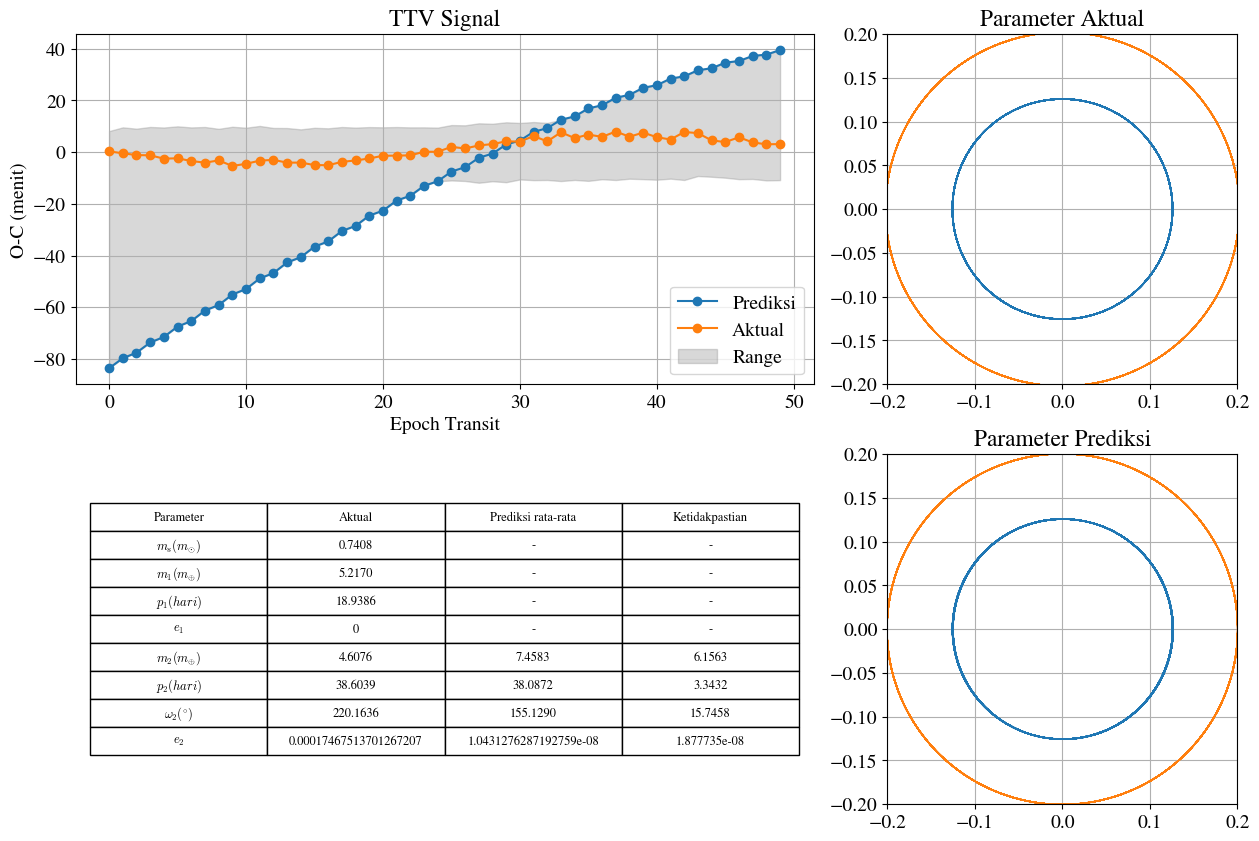

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

ress_pred = ttv_generate(ms=ms, p1=p1, m1=m1,p2=predicted_period,m2=predicted_mass*mearth/msun,o2=predicted_argument_perigee,e2=predicted_eccentricity)
transit2=[]
epoch2=[]
for i in range (len(ress_pred['positions'][0])):
    if (ress_pred['positions'][0][i]) == 0:
        if (ress_pred['positions'][2][i]) != -2:
            transit2.append(ress_pred['positions'][2][i])
            epoch2.append(ress_pred['positions'][1][i])
# if np.any(np.isnan(transit)):
#     continue
#print (len_x)
#
T2=TTV(epoch2,transit2)




print(ms, m1 * msun/mearth, p1, m2* msun/mearth, p2, e2, o2)
fig = plt.figure()
fig.set_figheight(10)
fig.set_figwidth(20)
gs = fig.add_gridspec(2, 2 ,hspace=0.2, wspace=0.1)
axs = gs.subplots()
mae = mean_absolute_error(T2[0][:50]*24*60, T1[0][:50]*24*60)
r2 = r2_score(T2[0][:50]*24*60, T1[0][:50]*24*60)

#axs[0,0].text(0.05, 0.95, f'MAE: {mae:.2f}', transform=axs[0,0].transAxes, fontsize=14, verticalalignment='top')
axs[0,0].plot(epoch2[:50], T2[0][:50]*24*60,'-o', label='Prediksi')

axs[0,0].plot(epoch[:50], Terr,'-o', label='Aktual')

axs[0,0].fill_between(epoch[:50], min_vals, max_vals, color='gray', alpha=0.3, label='Range')
axs[0,0].set_ylabel ('O-C (menit)')
axs[0,0].set_xlabel('Epoch Transit')
#axs[0,0].set_title(model_[0:-6])
axs[0,0].set_title('TTV Signal')
axs[0,0].legend(loc=4)
axs[0,0].grid()

data = [
    ["Parameter", "Aktual", "Prediksi rata-rata","Ketidakpastian"],
    [r"$m_s (m_{\odot})$", f"{ms:.4f}", "-", "-" ],
    [r"$m_1 (m_{\oplus})$", f"{m1* msun/mearth:.4f}", "-", "-"],#f"{m_trans_pred[0]:.4f}", "-"],
    [r"$p_1 (hari)$", f"{p1:.4f}", "-", "-"],
    [r"$e_1$", 0, "-", "-"],
    [r"$m_2 (m_{\oplus})$", f"{m2* msun/mearth:.4f}", f"{predicted_mass[0]:.4f}",f"{mass_uncertainty[0]:.4f}"],
    [r"$p_2 (hari)$", f"{p2:.4f}", f"{predicted_period[0]:.4f}", f"{period_uncertainty[0]:.4f}"],
    [r"$\omega_2 (^{\circ})$", f"{o2:.4f}", f"{predicted_argument_perigee[0]:.4f}",f"{argument_perigee_uncertainty[0]:.4f}"],
    [r"$e_2$", e2, f"{predicted_eccentricity[0]}", eccentricity_uncertainty[0]]
]


# Hide the axes
axs[1,0].axis('tight')
axs[1,0].axis('off')
colWidths = [0.2, 0.2, 0.2, 0.2]

# Create the table
table = axs[1,0].table(cellText=data,colWidths=colWidths,cellLoc='center', loc='center')

table.scale(1.2,1.2)

cell_height = 0.08  # Set the desired cell height

for key, cell in table.get_celld().items():
    cell.set_height(cell_height)

axs[0,1].set_aspect('equal', anchor='W')
axs[1,1].set_aspect('equal', anchor='W')

#plot orbit aktual

objects = [
      {'m':ms},
      {'m':m1, 'P':p1, 'inc':3.14159/2, 'e':0, 'omega':0  },
      {'m':m2, 'P':p2, 'inc':3.14159/2, 'e':e2,  'omega':np.deg2rad(o2)  },
      #{'m':m2, 'P':2*p2, 'inc':3.14159/2, 'e':0,  'omega':0  },
]

# create REBOUND simulation
# year long integrations, timestep = 1 hour
Ndays = int(p1*50)

sim_data = generate(objects, Ndays, Ndays*24)

# collect the analytics of interest from the simulation
ttv_data = analyze(sim_data)
#ttv_data2 = analyze(sim_data, ttvfast=True)
data = ttv_data
for j in range(1,len(data['objects'])):
  axs[0,1].plot(data['planets'][j-1]['x'], data['planets'][j-1]['y'],label='Planet {}'.format(j),lw=1,alpha=1 )
range_all = [-0.2,0.2]
axs[0,1].set_xlim(range_all)
axs[0,1].set_ylim(range_all)
axs[0,1].set_title("Parameter Aktual")
axs[0,1].set_aspect('equal', anchor='W')#, adjustable='box')
axs[0,1].grid()
#axs[0,1].set_ylabel('AU')
#axs[0,1].set_xlabel('AU')
#plot orbit predict



objects = [
      {'m':ms},
      {'m':m1, 'P':p1, 'inc':3.14159/2, 'e':0, 'omega':0  },
      {'m':predicted_mass*mearth/msun, 'P':predicted_period, 'inc':3.14159/2, 'e':predicted_eccentricity,  'omega':np.deg2rad(predicted_argument_perigee)  },
      #{'m':m2, 'P':2*p2, 'inc':3.14159/2, 'e':0,  'omega':0  },
]

# create REBOUND simulation
# year long integrations, timestep = 1 hour
Ndays = int(p1*50)

sim_data = generate(objects, Ndays, Ndays*24)

# collect the analytics of interest from the simulation
ttv_data = analyze(sim_data)
#ttv_data2 = analyze(sim_data, ttvfast=True)
data = ttv_data
for j in range(1,len(data['objects'])):
  axs[1,1].plot(data['planets'][j-1]['x'], data['planets'][j-1]['y'],label='Planet {}'.format(j),lw=1,alpha=1 )
axs[1,1].set_xlim(range_all)
axs[1,1].set_ylim(range_all)
axs[1,1].set_title("Parameter Prediksi")
axs[1,1].set_aspect('equal', anchor='W')#, adjustable='box')
axs[1,1].grid()
#axs[0,1].set_ylabel('AU')
#axs[0,1].set_xlabel('AU')
plt.savefig(log_dir+'/'+"data_test_"+datatrain_name+model_name+"_"+str(seeds)+".png", dpi=400,bbox_inches = 'tight')
plt.show()

#print(T2)

1.3606132272627245 90.53471190224471 15.956444827765523 141.50038588387002 41.19711587220631 0.00028494389919633714 293.59358478361617


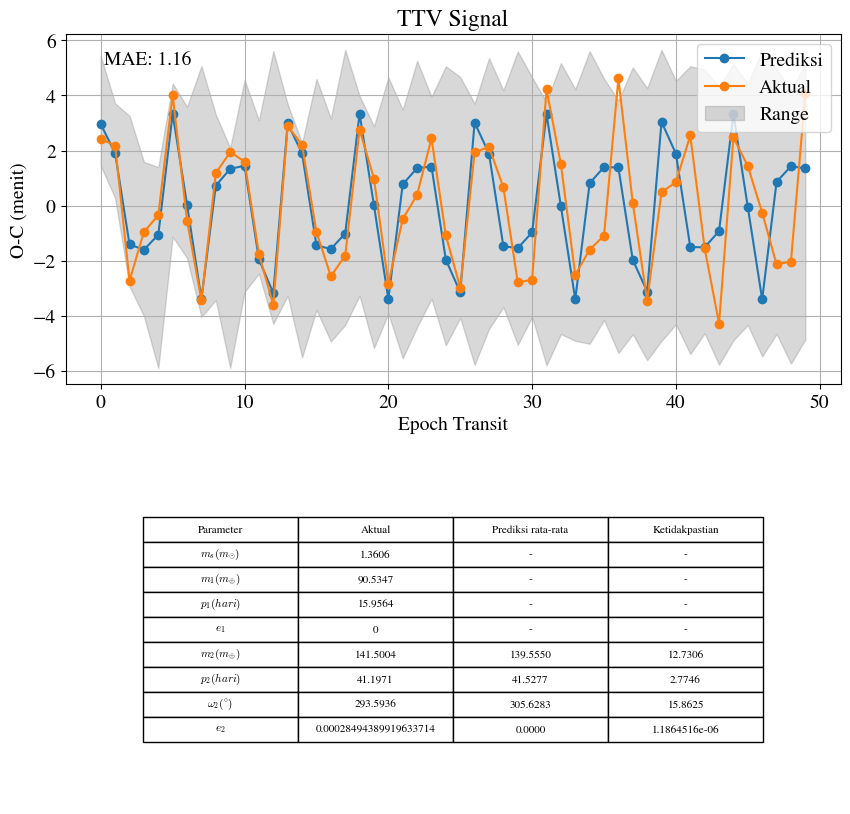

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

ress_pred = ttv_generate(ms=ms, p1=p1, m1=m1,p2=predicted_period,m2=predicted_mass*mearth/msun,o2=predicted_argument_perigee,e2=predicted_eccentricity)
transit2=[]
epoch2=[]
for i in range (len(ress_pred['positions'][0])):
    if (ress_pred['positions'][0][i]) == 0:
        if (ress_pred['positions'][2][i]) != -2:
            transit2.append(ress_pred['positions'][2][i])
            epoch2.append(ress_pred['positions'][1][i])
# if np.any(np.isnan(transit)):
#     continue
#print (len_x)
#
T2=TTV(epoch2,transit2)




print(ms, m1 * msun/mearth, p1, m2* msun/mearth, p2, e2, o2)
fig = plt.figure()
fig.set_figheight(10)
fig.set_figwidth(10)
gs = fig.add_gridspec(2, 1 ,hspace=0.2, wspace=0.1)
axs = gs.subplots()
mae = mean_absolute_error(T2[0][:50]*24*60, T1[0][:50]*24*60)
r2 = r2_score(T2[0][:50]*24*60, T1[0][:50]*24*60)

axs[0].text(0.05, 0.95, f'MAE: {mae:.2f}', transform=axs[0].transAxes, fontsize=14, verticalalignment='top')
axs[0].plot(epoch2[:50], T2[0][:50]*24*60,'-o', label='Prediksi')

axs[0].plot(epoch[:50], Terr,'-o', label='Aktual')

axs[0].fill_between(epoch[:50], min_vals, max_vals, color='gray', alpha=0.3, label='Range')
axs[0].set_ylabel ('O-C (menit)')
axs[0].set_xlabel('Epoch Transit')
#axs[0].set_title(model_[0:-6])
axs[0].set_title('TTV Signal')
axs[0].legend(loc='upper right')
axs[0].grid()

data = [
    ["Parameter", "Aktual", "Prediksi rata-rata","Ketidakpastian"],
    [r"$m_s (m_{\odot})$", f"{ms:.4f}", "-", "-" ],
    [r"$m_1 (m_{\oplus})$", f"{m1* msun/mearth:.4f}", "-", "-"],#f"{m_trans_pred[0]:.4f}", "-"],
    [r"$p_1 (hari)$", f"{p1:.4f}", "-", "-"],
    [r"$e_1$", 0, "-", "-"],
    [r"$m_2 (m_{\oplus})$", f"{m2* msun/mearth:.4f}", f"{predicted_mass[0]:.4f}",f"{mass_uncertainty[0]:.4f}"],
    [r"$p_2 (hari)$", f"{p2:.4f}", f"{predicted_period[0]:.4f}", f"{period_uncertainty[0]:.4f}"],
    [r"$\omega_2 (^{\circ})$", f"{o2:.4f}", f"{predicted_argument_perigee[0]:.4f}",f"{argument_perigee_uncertainty[0]:.4f}"],
    [r"$e_2$", e2, f"{predicted_eccentricity[0]:.4f}", eccentricity_uncertainty[0]]
]


# Hide the axes
axs[1].axis('tight')
axs[1].axis('off')
colWidths = [0.2, 0.2, 0.2, 0.2]

# Create the table
table = axs[1].table(cellText=data,colWidths=colWidths,cellLoc='center', loc='center')

table.scale(1.,1.5)
plt.savefig(log_dir+'/'+"[BEST]data_test_"+datatrain_name+model_name+"_"+str(seeds)+"_2plot.pdf", dpi=400,bbox_inches = 'tight')
plt.show()


In [ ]:
model_


'/content/gdrive/MyDrive/S3/revisi_paper/revisi_paper/model_logs_CNN/experiment_2025-12-31_15-26-57/exoplanet_ens_model_tanh_datatrain_paper2_10k_250_filtered_LSTM_16_Nov.keras'

#VALIDASI MENGGUNAKAN DATA KEPLER

In [ ]:
kepler_dir = '/content/gdrive/MyDrive/S3/data_exoplanet'
datafile = kepler_dir+'/kepler-419.fit'
long_ttvlist =kepler_dir+'/long_ttv.fit'
ttv_kepler = kepler_dir+'/TTV_kepler.xlsx'

from astropy.io import fits
from astropy.table import Table
import pandas

ttv= Table.read(datafile)
df=  ttv.to_pandas()

ttv_list = Table.read(long_ttvlist)
df_longttv =  ttv_list.to_pandas()
idx = [0,2,5,7,10,12]
df_data = pd.read_excel(ttv_kepler, header=0)
#df_data = df_data.iloc[idx]
KOI_list = df_data['KOI']
Kepler_list = df_data['Kepler Name']
ms_list = df_data['ms']
m1_list = df_data['m1']
m2_list = df_data['m2']
p1_list = df_data['p1']
p2_list = df_data['p2']
e2_list = df_data['e2']
o2_list = df_data['o2']
print(Kepler_list)

0      Kepler-50 b
1      Kepler-50 c
2     Kepler-128 b
3     Kepler-128 c
4      Kepler-36 c
5      Kepler-36 b
6     Kepler-161 c
7      Kepler-29 b
8      Kepler-29 c
9     Kepler-231 c
10     Kepler-28 b
11     Kepler-28 c
12    Kepler-277 b
13     Kepler-57 c
14             NaN
15     Kepler-170b
16    Kepler-333 b
Name: Kepler Name, dtype: object


1.263 33.6 17.324 40.4 33.006 0.0 0.0


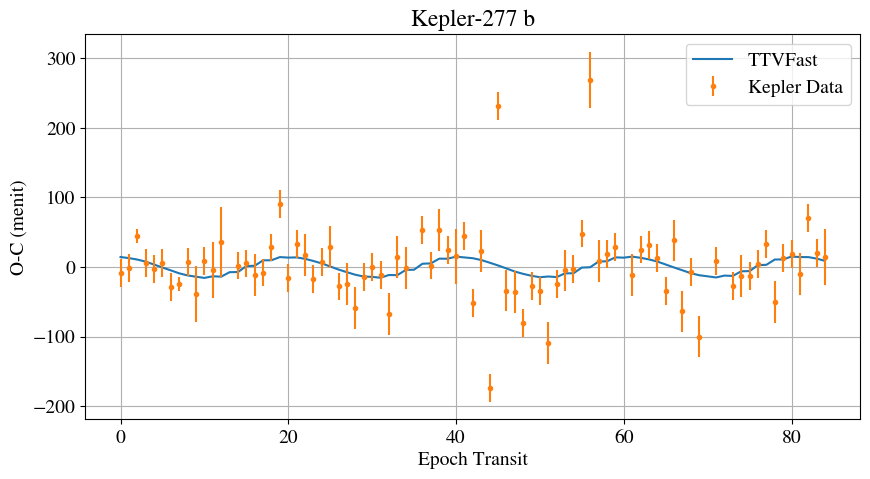

In [ ]:
i = 12

koi = KOI_list[i]
kepler = Kepler_list[i]
ms = ms_list[i]
m1 = m1_list[i]*mearth/msun
p1 = p1_list[i]
e1 = 0
m2 = m2_list[i]*mearth/msun
p2 = p2_list[i]
o2 = o2_list[i]
e2 = e2_list[i]
df_ = df[df['KOI']==koi]

n_data=max(df_['N'])+1

ress = ttv_generate(ms=ms, p1=p1, m1=m1,p2=p2,m2=m2,o2=o2,e2=e2)
transit=[]
epoch=[]
for i in range (len(ress['positions'][0])):
    if (ress['positions'][0][i]) == 0:
        if (ress['positions'][2][i]) != -2:
            transit.append(ress['positions'][2][i])
            epoch.append(ress['positions'][1][i])
# if np.any(np.isnan(transit)):
#     continue
#print (len_x) Aishameglio
#
T1=TTV(epoch,transit)



plt.figure(figsize=(10,5))
plt.plot(epoch[:n_data], T1[0][:n_data]*24*60,'-', label = 'TTVFast')

plt.title(str(kepler))
#plt.plot(ress[0], ress[1],'k-', label='TTVFast')
plt.errorbar(df_['N'], df_['O-C'], yerr=df_['e_O-C'], fmt='.', label='Kepler Data')
plt.ylabel ('O-C (menit)')
plt.xlabel('Epoch Transit')
plt.grid()
plt.legend()
print(ms, m1*msun/mearth, p1, m2*msun/mearth, p2, o2, e2)

In [ ]:
new_df = df_[abs(df_['O-C']) < 100].reset_index(drop=True)

,KOI,N,tn,O-C,e_O-C,f_O-C,TDV,e_TDV,f_TDV,TPV,e_TPV,f_TPV,Out,Over
0,1215.01,0,57.782986,-9.0,20.0,NaN,0.0,10.0,NaN,10.0,10.0,NaN,0,0
1,1215.01,1,75.107041,-1.0,20.0,NaN,0.0,10.0,NaN,10.0,10.0,NaN,0,0
2,1215.01,2,92.431096,44.5,10.0,NaN,0.0,10.0,NaN,10.0,10.0,NaN,0,0
3,1215.01,3,109.755151,6.0,20.0,NaN,0.0,10.0,NaN,10.0,10.0,NaN,0,0
4,1215.01,4,127.079205,-3.0,20.0,NaN,0.0,10.0,NaN,10.0,10.0,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,1215.01,80,1443.707378,19.0,20.0,NaN,0.0,10.0,NaN,10.0,10.0,NaN,0,0
71,1215.01,81,1461.031433,-10.0,30.0,NaN,0.0,10.0,NaN,10.0,10.0,NaN,0,0
72,1215.01,82,1478.355488,70.0,20.0,NaN,0.0,10.0,NaN,10.0,10.0,NaN,0,0
73,1215.01,83,1495.679543,20.0,20.0,NaN,0.0,10.0,NaN,10.0,10.0,NaN,0,0


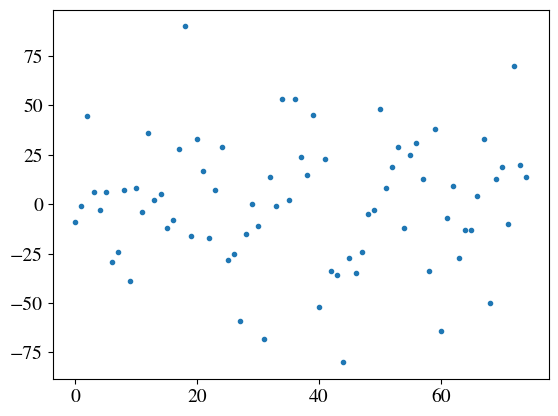

In [ ]:
plt.plot(new_df['O-C'],'.')

(new_df)

In [ ]:
from tensorflow.keras.models import load_model
import numpy as np

# Load the saved model with dropout layers
#model_ = '/content/gdrive/MyDrive/S3/new_ml_model/exoplanet_ens_model_10k.keras'
#model_ = '/content/gdrive/MyDrive/S3/new_ml_model/exoplanet_ens_model_15k.keras'
#model_ = '/content/gdrive/MyDrive/S3/new_ml_model/exoplanet_ens_model_10k_noise5.keras'
#model_ = '/content/gdrive/MyDrive/S3/new_ml_model/exoplanet_ens_model_improve.keras'

saved_model = load_model(model_, compile=False)

# Define the function for predicting with uncertainty
predict_fn = tf.function(lambda x, training: saved_model(x, training=training))

# Assuming new data is available in the same format as the training data
# Example new data for prediction
m_trans_pred = [(m1*msun/mearth)]

new_ttv_data = np.array(new_df['O-C'][:50])#T1[0][:50] * 24 * 60  # Example data
new_ttv_err =  df_['e_O-C'][:50]
new_star_mass = [ms]  # Example data
new_transiting_period = [p1]  # Example data
new_transiting_mass = m_trans_pred # Example data

# Reshape new_ttv_data to be 3D (samples, timesteps, features)
#ttv_observation
n_timesteps = new_ttv_data.shape[0]
new_ttv_data = new_ttv_data.reshape((1, n_timesteps, 1))

# Ensure other inputs are arrays and match expected input dimensions
new_star_mass = np.array(new_star_mass).reshape((1, 1))  # Assuming single sample
new_transiting_period = np.array(new_transiting_period).reshape((1, 1))  # Assuming single sample
new_transiting_mass = np.array(new_transiting_mass).reshape((1, 1))  # Assuming single sample

# Normalize new data
new_ttv_data = scaler_ttv.transform(new_ttv_data.reshape(-1, 1)).reshape(new_ttv_data.shape)
new_star_mass = scaler_star_mass.transform(new_star_mass.reshape(-1, 1))
new_transiting_period = scaler_transiting_period.transform(new_transiting_period.reshape(-1, 1))
new_transiting_mass = scaler_transiting_mass.transform(new_transiting_mass.reshape(-1, 1))

# Combine the inputs into the required format
new_X_inputs = [new_ttv_data, new_star_mass, new_transiting_period, new_transiting_mass]

# # Predict with uncertainty
# predictions, uncertainties = predict_with_uncertainty(predict_fn, new_X_inputs, n_iter=100)

# # The predictions and uncertainties will be lists of arrays corresponding to each output
# predicted_mass = scaler_mass_output.inverse_transform(predictions[0])[0]
# predicted_period = scaler_period_output.inverse_transform(predictions[1])[0]
# predicted_eccentricity = scaler_eccentricity_output.inverse_transform(predictions[2])[0]
# predicted_argument_perigee = scaler_argument_perigee_output.inverse_transform(predictions[3])[0]
# #predicted_argument_perigee = ((predicted_argument_perigee))


# mass_uncertainty = scaler_mass_output.inverse_transform(uncertainties[0])[0]
# period_uncertainty = scaler_period_output.inverse_transform(uncertainties[1])[0]
# eccentricity_uncertainty = scaler_eccentricity_output.inverse_transform(uncertainties[2])[0]
# argument_perigee_uncertainty = scaler_argument_perigee_output.inverse_transform(uncertainties[3])[0]
# #argument_perigee_uncertainty = ((argument_perigee_uncertainty))

# # Print the predictions and uncertainties
# print("Predicted mass of perturbing planet:", predicted_mass, "±", mass_uncertainty)
# print("Predicted period of perturbing planet:", predicted_period, "±", period_uncertainty)
# print("Predicted eccentricity of perturbing planet:", predicted_eccentricity, "±", eccentricity_uncertainty)
# print("Predicted argument of perigee of perturbing planet:", predicted_argument_perigee, "±", argument_perigee_uncertainty)



Running 100 stochastic forward passes...
Predicted mass of perturbing planet: [66.05629] ± [7.5219293]
Predicted period of perturbing planet: [22.009361] ± [1.9881171]
Predicted eccentricity of perturbing planet: [7.5595297e-10] ± [1.3137834e-09]
Predicted argument of perigee of perturbing planet: [184.78705] ± [17.949135]


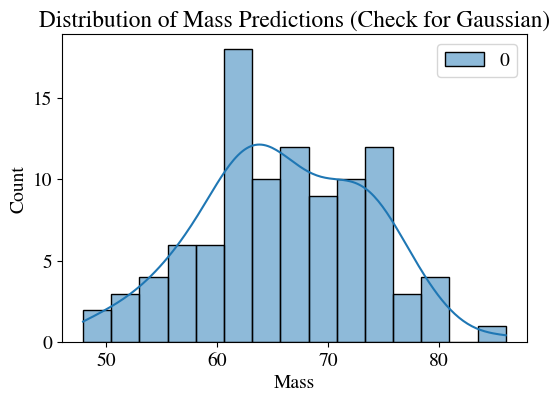

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model

# ---------------------------------------------------------
# 1. SETUP
# ---------------------------------------------------------
# Load model
# model_path = '...'
saved_model = load_model(model_, compile=False)
predict_fn = tf.function(lambda x, training: saved_model(x, training=training))

# ---------------------------------------------------------
# 2. RUN MC DROPOUT (Collect Raw Samples)
# ---------------------------------------------------------
n_iter = 100
print(f"Running {n_iter} stochastic forward passes...")

# This list will hold 100 raw predictions.
# Each prediction contains [Mass, Period, Ecc, Omega]
raw_results = [predict_fn(new_X_inputs, training=True) for _ in range(n_iter)]

# ---------------------------------------------------------
# 3. PROCESS DATA (Corrected Logic)
# ---------------------------------------------------------

# Extract samples for each parameter into arrays of shape (100, 1)
# We assume the model outputs order is: [Mass, Period, Ecc, Omega]
# Adjust indices [0], [1], [2], [3] if your model output order is different.

# Step A: Gather raw normalized data
raw_mass = np.array([r[0].numpy() for r in raw_results]).reshape(n_iter, 1)
raw_period = np.array([r[1].numpy() for r in raw_results]).reshape(n_iter, 1)
raw_ecc = np.array([r[2].numpy() for r in raw_results]).reshape(n_iter, 1)
raw_omega = np.array([r[3].numpy() for r in raw_results]).reshape(n_iter, 1)

# Step B: Inverse Transform ALL 100 samples to Real Units FIRST
# This is crucial for correct uncertainty calculation
real_mass_samples = scaler_mass_output.inverse_transform(raw_mass)
real_period_samples = scaler_period_output.inverse_transform(raw_period)
real_ecc_samples = scaler_eccentricity_output.inverse_transform(raw_ecc)
real_omega_samples = scaler_argument_perigee_output.inverse_transform(raw_omega)

# Step C: Calculate Mean (Prediction) and Std Dev (Uncertainty) from Real Units
predicted_mass = np.array([np.mean(real_mass_samples)])
mass_uncertainty = np.array([np.std(real_mass_samples)])

predicted_period = np.array([np.mean(real_period_samples)])
period_uncertainty = np.array([np.std(real_period_samples)])

predicted_eccentricity = np.array([np.mean(real_ecc_samples)])
eccentricity_uncertainty = np.array([np.std(real_ecc_samples)])

predicted_argument_perigee = np.array([np.mean(real_omega_samples)])
argument_perigee_uncertainty = np.array([np.std(real_omega_samples)])

# ---------------------------------------------------------
# 4. PRINT RESULTS (Formatted exactly as requested)
# ---------------------------------------------------------

print("Predicted mass of perturbing planet:", predicted_mass, "±", mass_uncertainty)
print("Predicted period of perturbing planet:", predicted_period, "±", period_uncertainty)
print("Predicted eccentricity of perturbing planet:", predicted_eccentricity, "±", eccentricity_uncertainty)
print("Predicted argument of perigee of perturbing planet:", predicted_argument_perigee, "±", argument_perigee_uncertainty)

# ---------------------------------------------------------
# OPTIONAL: Check the Gaussian Distribution for Mass (For the Reviewer)
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.histplot(real_mass_samples, kde=True, bins=15)
plt.title("Distribution of Mass Predictions (Check for Gaussian)")
plt.xlabel("Mass")
plt.show()

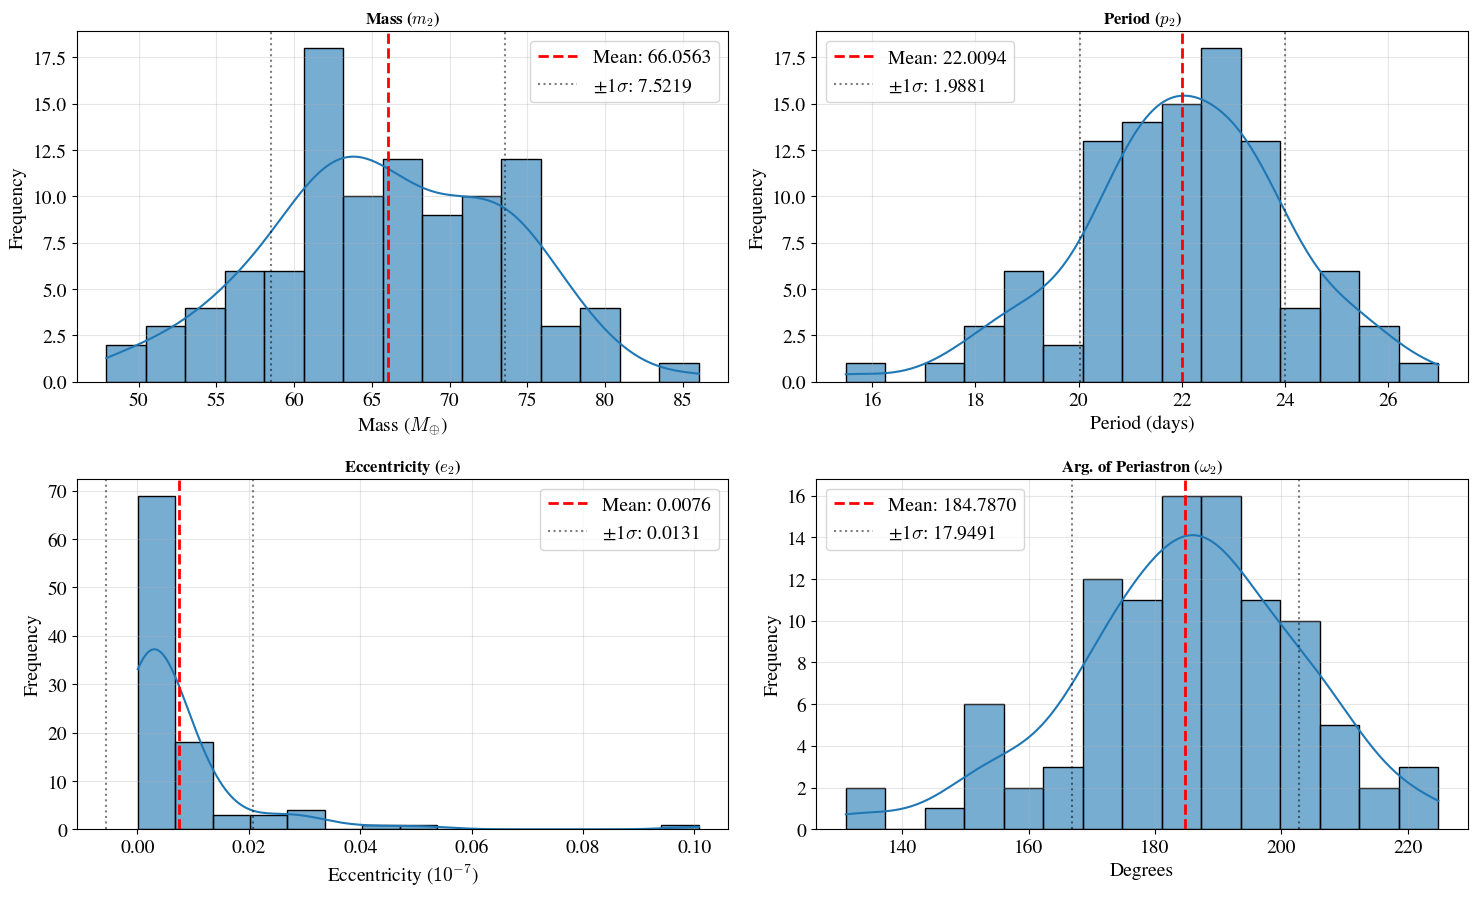

In [ ]:
plot_parameter_distributions(real_mass_samples,
                             real_period_samples,
                             real_ecc_samples,
                             real_omega_samples)

In [ ]:
# from skopt import gp_minimize
# from skopt.space import Real
# import numpy as np

# # Define bounds using skopt's Real class
# space = [
#     Real(predicted_mass[0] - 1*mass_uncertainty[0], predicted_mass[0] + 1*mass_uncertainty[0], name='mass'),
#     Real(predicted_period[0] - 1*period_uncertainty[0], predicted_period[0] + 1*period_uncertainty[0], name='period'),
#     Real(max(0, predicted_eccentricity[0] - 1*eccentricity_uncertainty[0]), min(1, predicted_eccentricity[0] + 1*eccentricity_uncertainty[0]), name='eccentricity'),
#     Real(0, 360, name='omega')
# ]

# T_obs = np.array(new_df['O-C'][:])  # Observed TTV
# error_ttv = np.array(new_df['e_O-C'][:])  # Observed uncertainties
# n_data = len(T_obs)

# def chi_square_objective(params):
#     mass, period, eccentricity, omega = params

#     ress_pred = ttv_generate(
#         ms=ms,
#         p1=p1,
#         m1=m1,
#         p2=period,
#         m2=mass * mearth / msun,
#         o2=omega,
#         e2=eccentricity
#     )

#     transit2, epoch2 = [], []
#     for i in range(len(ress_pred['positions'][0])):
#         if ress_pred['positions'][0][i] == 0 and ress_pred['positions'][2][i] != -2:
#             transit2.append(ress_pred['positions'][2][i])
#             epoch2.append(ress_pred['positions'][1][i])

#     T2 = TTV(epoch2, transit2)
#     Tgen = T2[0][:n_data] * 24 * 60
#     #print(len(T_gen), len(T_obs), len(error_ttv))
#     if len(Tgen) != len(T_obs):
#         return 1e10  # large penalty
#     chi2 = np.sum(((Tgen - T_obs) / error_ttv) ** 2)
#     return chi2

# # Perform Bayesian optimization
# res = gp_minimize(
#     func=chi_square_objective,
#     dimensions=space,
#     n_calls=100,  # Number of evaluations (increase for better accuracy)
#     n_initial_points=10,  # Initial random evaluations
#     random_state=42
# )

# best_fit_params = res.x
# print("Refined parameters (Bayesian Optimization):", best_fit_params)
# chi2_best = chi_square_objective(best_fit_params)
# print("Chi-square (χ²):", chi2_best)
# print("Reduced Chi-square (χ²_red):", chi2_best / (n_data - len(best_fit_params)))


In [ ]:
# best_chi2 = chi2_best / (n_data - len(best_fit_params))
# best_chi2

In [ ]:
# # Visualization of Bayesian Optimization Results
# import matplotlib.pyplot as plt
# import numpy as np

# # Extract results
# x_iters = np.array(res.x_iters)
# func_vals = np.array(res.func_vals)
# best_idx = np.argmin(func_vals)

# # Plot 1: Best chi-square over iterations (convergence)
# plt.figure(figsize=(10, 4))
# plt.plot(np.minimum.accumulate(func_vals)[10:], marker='o')
# plt.xlabel("Iteration")
# plt.ylabel("Best Chi-Square")
# plt.title("Bayesian Optimization Convergence")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # Plot 2: Search path in parameter space (each param vs. chi)
# param_names = ["mass", "period", "eccentricity", "omega"]
# fig, axes = plt.subplots(1, 4, figsize=(16, 4))
# for i in range(4):
#     axes[i].scatter(x_iters[:, i], func_vals, c=func_vals, cmap='viridis', s=30)
#     axes[i].axvline(res.x[i], color='red', linestyle='--', label='Best')
#     axes[i].set_xlabel(param_names[i])
#     axes[i].set_ylabel("Chi-Square")
#     axes[i].set_title(f"{param_names[i]} vs Chi²")
#     axes[i].legend()
#     axes[i].grid(True)

# plt.tight_layout()
# plt.show()

# # Final best result
# print("✅ Best parameters found:", res.x)
# print("🔽 Minimum chi-square value:", res.fun)


In [ ]:
#chi_square_objective(initial_guess)

In [ ]:
#TTVs Uncertainties

# mpred_unc = abs(np.array([predicted_mass - mass_uncertainty, predicted_mass, predicted_mass + mass_uncertainty]))
# ppred_unc = np.array([predicted_period - period_uncertainty, predicted_period, predicted_period + sigma*period_uncertainty])
# epred_unc = np.array([predicted_eccentricity - eccentricity_uncertainty, predicted_eccentricity, predicted_eccentricity + eccentricity_uncertainty])
# opred_unc = np.array([predicted_argument_perigee - argument_perigee_uncertainty, predicted_argument_perigee, predicted_argument_perigee + argument_perigee_uncertainty])
n_unc = 500
# mpred_unc = abs(np.linspace(predicted_mass - mass_uncertainty, predicted_mass + mass_uncertainty, n_unc))
# ppred_unc = np.linspace(predicted_period - sigma*period_uncertainty, predicted_period + sigma*period_uncertainty, n_unc)
# epred_unc = np.linspace(predicted_eccentricity - eccentricity_uncertainty, predicted_eccentricity + eccentricity_uncertainty, n_unc)
# opred_unc = np.linspace(predicted_argument_perigee - argument_perigee_uncertainty, predicted_argument_perigee + argument_perigee_uncertainty, n_unc)

# mpred_unc = np.random.uniform(predicted_mass - mass_uncertainty, predicted_mass + mass_uncertainty, size=n_unc).tolist()
# ppred_unc = np.random.uniform(predicted_period - sigma*period_uncertainty, predicted_period + sigma*period_uncertainty, size=n_unc).tolist()
# epred_unc = np.zeros(len(np.random.uniform(predicted_eccentricity - eccentricity_uncertainty, predicted_eccentricity + eccentricity_uncertainty, size=n_unc).tolist()))
# opred_unc = np.random.uniform(predicted_argument_perigee - argument_perigee_uncertainty, predicted_argument_perigee + argument_perigee_uncertainty, size=n_unc).tolist()

n_data=len(new_df['N'])

all_TTV=[]
all_epoch=[]
index_unc = []

mpred_unc = []
ppred_unc = []
opred_unc = []
epred_unc = []
n_sigma = 3
for j in range (n_unc):

    #pastikan non negative numnber
    p2_unc = np.abs(np.random.uniform(predicted_period - n_sigma*period_uncertainty,predicted_period + n_sigma*period_uncertainty))
    m2_unc = np.abs(np.random.uniform(predicted_mass - n_sigma*mass_uncertainty,predicted_mass + n_sigma*mass_uncertainty))
    o2_unc = np.random.uniform(predicted_argument_perigee - n_sigma*argument_perigee_uncertainty,predicted_argument_perigee + n_sigma*argument_perigee_uncertainty)
    e2_unc = np.random.uniform(0,predicted_eccentricity + n_sigma*eccentricity_uncertainty)
    ress_pred = ttv_generate(ms=ms, p1=p1, m1=m1,p2=p2_unc,m2=m2_unc*mearth/msun,o2=o2_unc,e2=e2_unc)

    transit2=[]
    epoch2=[]
    for i in range (len(ress_pred['positions'][0])):
      if (ress_pred['positions'][0][i]) == 0:
          if (ress_pred['positions'][2][i]) != -2:
              transit2.append(ress_pred['positions'][2][i])
              epoch2.append(ress_pred['positions'][1][i])

    # if np.any(np.isnan(transit)):
    #     continue
    #print (len_x)

    T2=TTV(epoch2,transit2)
    max_ttv = 2*max(new_df['O-C'])
    if (len(T2[0])) <= n_data or max(T2[0][:n_data]*24*60) > max_ttv or min(T2[0][:n_data]*24*60) < -max_ttv:
        continue
    all_TTV.append(T2[0][:n_data]*24*60)
    all_epoch.append(epoch2[:n_data] )
    index_unc.append(j)
    mpred_unc.append(m2_unc)
    ppred_unc.append(p2_unc)
    opred_unc.append(o2_unc)
    epred_unc.append(e2_unc)
    # all_TTV.append(T2[0][:n_data]*24*60)
    # all_epoch.append(epoch2[:n_data] )
    #print(ppred_unc[k], mpred_unc[j])


ress_pred = ttv_generate(ms=ms, p1=p1, m1=m1,p2=predicted_period,m2=predicted_mass*mearth/msun,o2=predicted_argument_perigee,e2=predicted_eccentricity)
transit2=[]
epoch2=[]
for i in range (len(ress_pred['positions'][0])):
    if (ress_pred['positions'][0][i]) == 0:
        if (ress_pred['positions'][2][i]) != -2:
            transit2.append(ress_pred['positions'][2][i])
            epoch2.append(ress_pred['positions'][1][i])
# if np.any(np.isnan(transit)):
#     continue
#print (len_x)
#
T2=TTV(epoch2,transit2)
#all_TTV.append(T2[0][:n_data]*24*60)

all_TTV = np.array(all_TTV)
# Combine the data into a single array for easier processing
#all_data = np.vstack([data1, data2, data3])

# Calculate the max and min at each epoch
# max_vals = np.max(all_TTV, axis=0)
# min_vals = np.min(all_TTV, axis=0)


In [ ]:
max_vals = np.nanmax(all_TTV, axis=0)
min_vals = np.nanmin(all_TTV, axis=0)

198


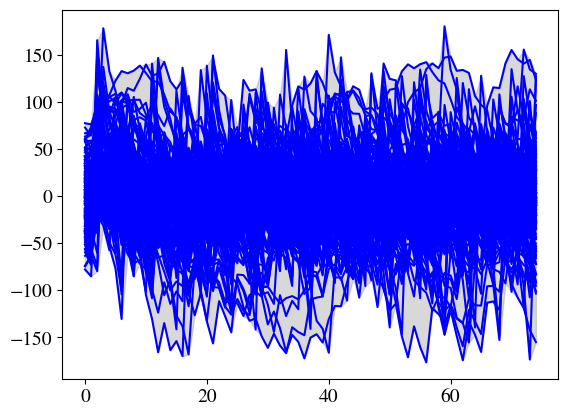

In [ ]:
for i in range(len(all_TTV)):
  plt.plot(epoch2[:n_data], all_TTV[i],'-b')
plt.fill_between(epoch2[:n_data], min_vals, max_vals, color='gray', alpha=0.3, label='Range')
print(len(all_TTV))

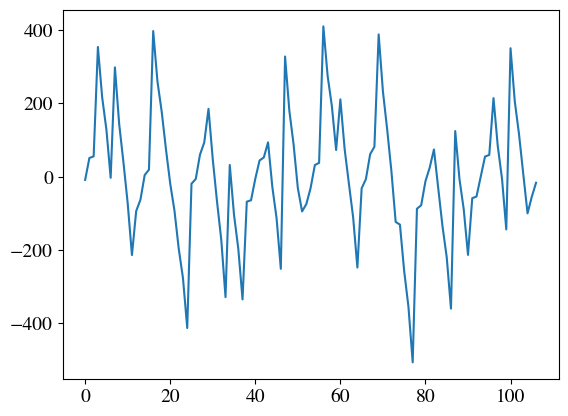

In [ ]:
plt.plot(T2[0][:n_data]*24*60)

In [ ]:
def chi_square_ttv(T_obs, T_gen, T_obs_uncertainty):
    """
    Calculate chi-square and reduced chi-square for TTV signals.

    Parameters:
    T_obs: array-like, observed TTV signal
    T_gen: array-like, generated TTV signal
    T_obs_uncertainty: array-like, uncertainties in observed TTV signal

    Returns:
    chi2: float, chi-square value
    reduced_chi2: float, reduced chi-square value
    """
    residuals = T_obs - T_gen
    chi2 = np.sum((residuals / T_obs_uncertainty) ** 2)
    dof = len(T_obs) - 1  # Degrees of freedom (adjust if necessary)
    reduced_chi2 = chi2 / dof
    return chi2, reduced_chi2


T_obs = np.array(new_df['O-C'][:n_data]) # Observed TTV
T_obs_uncertainty = np.array(new_df['e_O-C'][:n_data])#np.array([0.2, 0.3, 0.4, 0.2])  # Observed uncertainties

predicted_TTV_list = all_TTV


# Find the best chi-square value
best_chi2 = float('inf')  # Initialize with infinity
best_index = -1
best_prediction = None

for i, T_gen in enumerate(predicted_TTV_list):
    chi2, reduced_chi2 = chi_square_ttv(T_obs, T_gen, T_obs_uncertainty)
    #print(f"Prediction {i + 1}: Chi-Square = {chi2}, Reduced Chi-Square = {reduced_chi2}")

    # Update the best fit
    if reduced_chi2 < best_chi2:
        best_chi2 = reduced_chi2
        best_index = i
        best_prediction = T_gen

print("\nBest Prediction:")
print(f"Index: {best_index + 1}, Chi-Square: {best_chi2}")
print("Best Predicted TTV:", best_prediction)




Best Prediction:
Index: 109, Chi-Square: 1.6815671524585065
Best Predicted TTV: [ 26.17838706  16.19001814  27.50096906  28.76725831  15.19901891
   3.16499931   2.54726937  -7.15511563 -24.6501228  -27.85849192
 -17.35241035 -30.9111762  -35.99679481  -1.88841238  -8.39595467
 -15.019506    23.42104175  22.7603535   13.43442408  29.82434223
  31.03803831  17.83134247   8.51310348   8.20718124  -3.54604825
 -21.08214879 -23.89372517 -17.86185249 -32.37349416 -37.07519821
  -6.16430641 -13.80996543 -19.96720221  20.02550044  18.61805451
   9.95329003  31.36101015  32.43760189  19.75083767  13.79191384
  13.75054015   0.53897047 -16.76088945 -19.19529117 -17.4485302
 -32.82567159 -37.15775373 -10.01624547 -18.81120615 -24.52626139
  16.11168006  13.8766996    5.86156873  32.05159979  32.90402261
  20.84604238  18.84002871  19.01143144   4.90282539 -11.80337752
 -13.88288936 -16.11050208 -32.24684637 -36.22424274 -13.29755428
 -23.23915785 -28.53693548  11.82148212   8.6853819    1.30019

Predicted mass of perturbing planet: [56.67967218] ± [7.5219293]
Predicted period of perturbing planet: [26.75127989] ± [1.9881171]
Predicted eccentricity of perturbing planet: [4.07607452e-09] ± [1.3137834e-09]
Predicted argument of perigee of perturbing planet: [187.11541684] ± [17.949135]


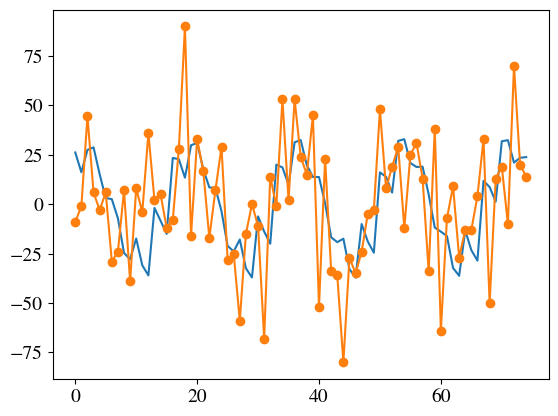

In [ ]:
plt.plot(all_TTV[best_index][:n_data])
plt.plot(new_df['O-C'],'-o')
real_best = index_unc[best_index]
predicted_mass = np.array(mpred_unc[best_index])
predicted_period = np.array(ppred_unc[best_index])
predicted_argument_perigee = np.array(opred_unc[best_index])
predicted_eccentricity = np.array(epred_unc[best_index])

print("Predicted mass of perturbing planet:", predicted_mass, "±", mass_uncertainty)
print("Predicted period of perturbing planet:", predicted_period, "±", period_uncertainty)
print("Predicted eccentricity of perturbing planet:", predicted_eccentricity, "±", eccentricity_uncertainty)
print("Predicted argument of perigee of perturbing planet:", predicted_argument_perigee, "±", argument_perigee_uncertainty)


In [ ]:
len(index_unc)

198

In [ ]:
T_obs = np.array(new_df['O-C'][:n_data]) # Observed TTV
T_obs_uncertainty = np.array(new_df['e_O-C'][:n_data])#np.array([0.2, 0.3, 0.4, 0.2])  # Observed uncertainties

predicted_TTV_list = T2[0][:n_data]*24*60
reduced_chi2_act, chi2_act = chi_square_ttv(T_obs, predicted_TTV_list, T_obs_uncertainty)
print(chi2_act)

22.503227821756383


In [ ]:
T_obs_uncertainty

array([20., 20., 10., 20., 20., 20., 20., 10., 20., 40., 20., 40., 50.,
       20., 20., 30., 20., 20., 20., 20., 20., 30., 20., 20., 30., 20.,
       30., 30., 20., 20., 20., 30., 30., 30., 20., 20., 30., 20., 40.,
       20., 20., 30., 30., 30., 20., 20., 20., 20., 30., 20., 20., 30.,
       20., 20., 30., 20., 20., 20., 20., 30., 30., 20., 20., 20., 30.,
       20., 20., 20., 30., 20., 20., 30., 20., 20., 40.])

In [ ]:
predicted_TTV_list = T2[0][:n_data]*24*60
reduced_chi2_best, best_chi2 = chi_square_ttv(T_obs, predicted_TTV_list, T_obs_uncertainty)
print(best_chi2)

1.6815671524585065


[]

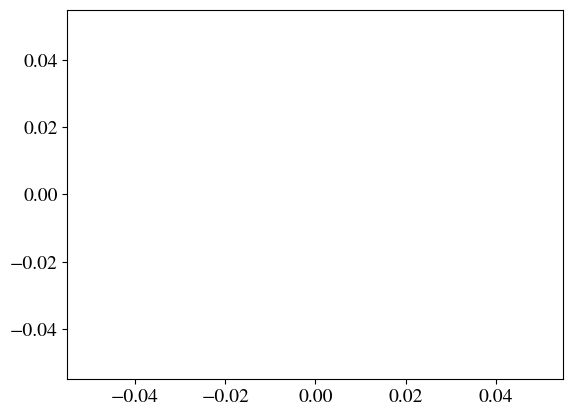

In [ ]:
plt.plot()

1.263 33.6 17.324 40.4 33.006 0.0 0.0


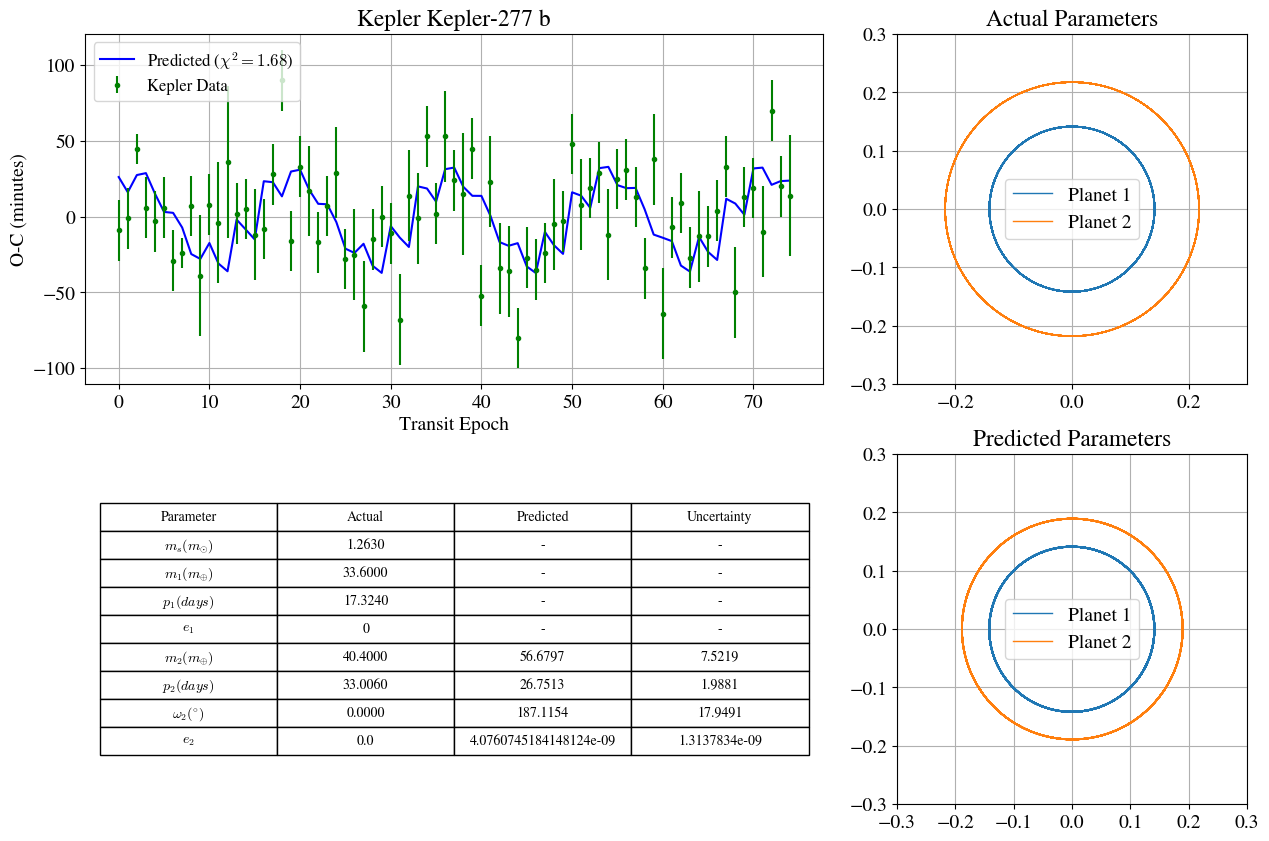

In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

df_ = df[df['KOI']==koi]
n_data=len(new_df['N'])

# predicted_mass = np.array([best_fit_params[0]])
# predicted_period = np.array([best_fit_params[1]])
# predicted_eccentricity = np.array([best_fit_params[2]])
# predicted_argument_perigee = np.array([best_fit_params[3]])

ress_pred = ttv_generate(ms=ms, p1=p1, m1=m1,p2=predicted_period,m2=predicted_mass*mearth/msun,o2=predicted_argument_perigee,e2=predicted_eccentricity)
transit2=[]
epoch2=[]
for i in range (len(ress_pred['positions'][0])):
    if (ress_pred['positions'][0][i]) == 0:
        if (ress_pred['positions'][2][i]) != -2:
            transit2.append(ress_pred['positions'][2][i])
            epoch2.append(ress_pred['positions'][1][i])

T2=TTV(epoch2,transit2)

print(ms, m1 * msun/mearth, p1, m2* msun/mearth, p2, e2, o2)
fig = plt.figure()
fig.set_figheight(10)
fig.set_figwidth(20)
gs = fig.add_gridspec(2, 2 ,hspace=0.2, wspace=0.1)
axs = gs.subplots()

axs[0,0].plot(epoch2[:n_data], T2[0][:n_data]*24*60,'-b', label=f'Predicted ($\\chi^2 = {best_chi2:.2f}$)')
#axs[0,0].plot(epoch[:n_data], T1[0][:n_data]*24*60,'-',color='orange' , label=f'Reference ($\\chi^2 = {chi2_act:.2f}$)')
#axs[0,0].fill_between(epoch[:n_data], min_vals[:n_data], max_vals[:n_data], color='blue', alpha=0.3, label='Prediction Range')

axs[0,0].errorbar(new_df.index, new_df['O-C'], yerr=new_df['e_O-C'], fmt='.', label='Kepler Data',color='green')
axs[0,0].set_ylabel ('O-C (minutes)')
axs[0,0].set_xlabel('Transit Epoch')
#axs[0,0].text(0.05, 0.95, f'$\chi_{{\mathrm{{predicted}}}}^2 = {best_chi2:.2f}$', transform=axs[0,0].transAxes, fontsize=14, verticalalignment='top')
#axs[0,0].text(0.05, 0.85, f'$\chi_{{\mathrm{{actual}}}}^2 = {chi2_act:.2f}$', transform=axs[0,0].transAxes, fontsize=14, verticalalignment='top')

axs[0,0].set_title(f'Kepler {kepler}')

axs[0,0].legend(loc='upper left', fontsize=12)
axs[0,0].grid()

data = [
    ["Parameter", "Actual", "Predicted","Uncertainty"],
    [r"$m_s (m_{\odot})$", f"{ms:.4f}", "-", "-" ],
    [r"$m_1 (m_{\oplus})$", f"{m1* msun/mearth:.4f}", "-", "-"],
    [r"$p_1 (days)$", f"{p1:.4f}", "-", "-"],
    [r"$e_1$", 0, "-", "-"],
    [r"$m_2 (m_{\oplus})$", f"{m2* msun/mearth:.4f}", f"{predicted_mass[0]:.4f}",f"{mass_uncertainty[0]:.4f}"],
    [r"$p_2 (days)$", f"{p2:.4f}", f"{predicted_period[0]:.4f}", f"{period_uncertainty[0]:.4f}"],
    [r"$\omega_2 (^{\circ})$", f"{o2:.4f}", f"{predicted_argument_perigee[0]:.4f}",f"{argument_perigee_uncertainty[0]:.4f}"],
    [r"$e_2$", e2, f"{predicted_eccentricity[0]}", eccentricity_uncertainty[0]]
]
formatted_data = []
for row in data:
    formatted_row = []
    for item in row:
        if isinstance(item, (float, int)):
            formatted_row.append(f"{item:.4f}")
        else:
            formatted_row.append(item)
    formatted_data.append(formatted_row)

axs[1,0].axis('tight')
axs[1,0].axis('off')
colWidths = [0.2, 0.2,0.2, 0.2]

table = axs[1,0].table(cellText=data,colWidths=colWidths,cellLoc='center', loc='center')

table.scale(1.2,1.2)

cell_height = 0.08

for key, cell in table.get_celld().items():
    cell.set_height(cell_height)

axs[0,1].set_aspect('equal', anchor='W')
axs[1,1].set_aspect('equal', anchor='W')

objects = [
      {'m':ms},
      {'m':m1, 'P':p1, 'inc':3.14159/2, 'e':0, 'omega':0  },
      {'m':m2, 'P':p2, 'inc':3.14159/2, 'e':e2,  'omega':np.deg2rad(o2)  },
]

Ndays = int(p1*50)

sim_data = generate(objects, Ndays, Ndays*24)

ttv_data = analyze(sim_data)
data = ttv_data
for j in range(1,len(data['objects'])):
  axs[0,1].plot(data['planets'][j-1]['x'], data['planets'][j-1]['y'],label='Planet {}'.format(j),lw=1,alpha=1 )
range_all = [-0.3,0.3]
axs[0,1].set_xlim(range_all)
axs[0,1].set_ylim(range_all)
axs[0,1].set_title("Actual Parameters")
axs[0,1].set_aspect('equal', anchor='W')
axs[0,1].grid()
axs[0,1].legend(loc='best')

objects = [
      {'m':ms},
      {'m':m1, 'P':p1, 'inc':3.14159/2, 'e':0, 'omega':0  },
      {'m':predicted_mass*mearth/msun, 'P':predicted_period, 'inc':3.14159/2, 'e':predicted_eccentricity,  'omega':np.deg2rad(predicted_argument_perigee)  },
]

Ndays = int(p1*50)

sim_data = generate(objects, Ndays, Ndays*24)

ttv_data = analyze(sim_data)
data = ttv_data
for j in range(1,len(data['objects'])):
  axs[1,1].plot(data['planets'][j-1]['x'], data['planets'][j-1]['y'],label='Planet {}'.format(j),lw=1,alpha=1 )
axs[1,1].set_xlim(range_all)
axs[1,1].set_ylim(range_all)
axs[1,1].set_title("Predicted Parameters")
axs[1,1].set_aspect('equal', anchor='W')
axs[1,1].grid()
axs[1,1].legend(loc='best')

plt.savefig(log_dir+'/'+"actual_predicted_kepler"+str(kepler)+str(best_chi2)+".png", dpi=400,bbox_inches = 'tight')
plt.show()

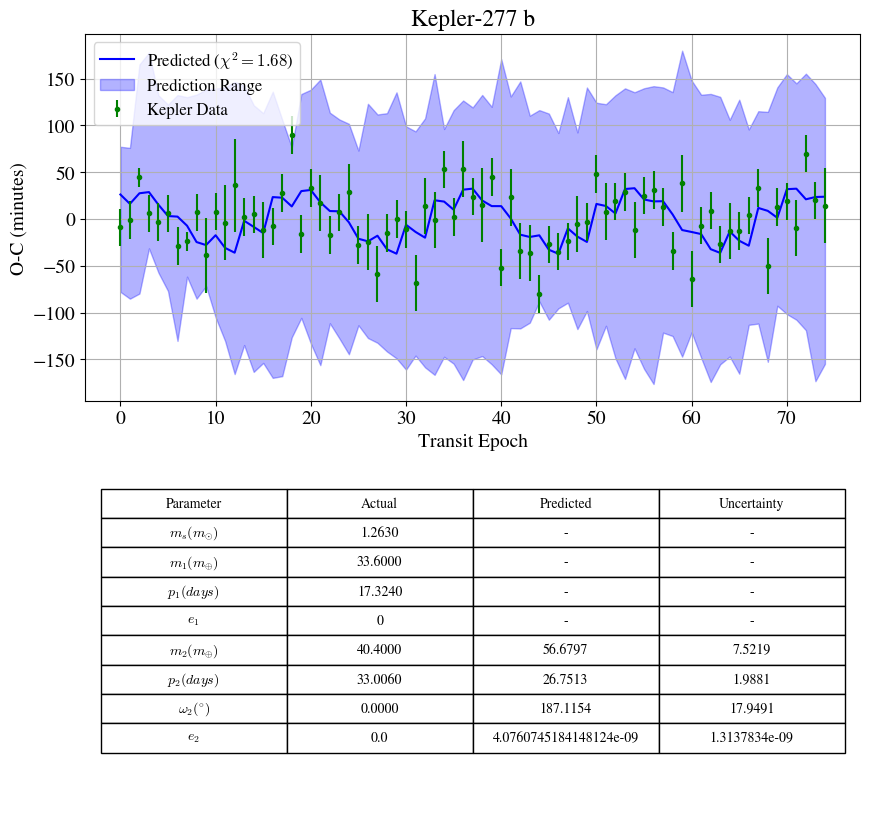

In [ ]:
fig = plt.figure()
fig.set_figheight(10)
fig.set_figwidth(10)
gs = fig.add_gridspec(2, 1 ,hspace=0.1)
axs = gs.subplots()

axs[0].plot(epoch2[:n_data], T2[0][:n_data]*24*60,'-b', label=f'Predicted ($\\chi^2 = {best_chi2:.2f}$)')
#axs[0].plot(epoch[:n_data], T1[0][:n_data]*24*60,'-',color='orange' , label=f'Reference ($\\chi^2 = {chi2_act:.2f}$)')
axs[0].fill_between(epoch2[:n_data], min_vals[:n_data], max_vals[:n_data], color='blue', alpha=0.3, label='Prediction Range')

axs[0].errorbar(new_df.index, new_df['O-C'], yerr=new_df['e_O-C'], fmt='.', label='Kepler Data',color='green')
axs[0].set_ylabel ('O-C (minutes)')
axs[0].set_xlabel('Transit Epoch')
#axs[0].text(0.05, 0.95, f'$\chi_{{\mathrm{{predicted}}}}^2 = {best_chi2:.2f}$', transform=axs[0].transAxes, fontsize=14, verticalalignment='top')
#axs[0].text(0.05, 0.85, f'$\chi_{{\mathrm{{actual}}}}^2 = {chi2_act:.2f}$', transform=axs[0].transAxes, fontsize=14, verticalalignment='top')

axs[0].set_title(f'{kepler}')

axs[0].legend(loc='upper left', fontsize=12)
axs[0].grid()

data = [
    ["Parameter", "Actual", "Predicted","Uncertainty"],
    [r"$m_s (m_{\odot})$", f"{ms:.4f}", "-", "-" ],
    [r"$m_1 (m_{\oplus})$", f"{m1* msun/mearth:.4f}", "-", "-"],
    [r"$p_1 (days)$", f"{p1:.4f}", "-", "-"],
    [r"$e_1$", 0, "-", "-"],
    [r"$m_2 (m_{\oplus})$", f"{m2* msun/mearth:.4f}", f"{predicted_mass[0]:.4f}",f"{mass_uncertainty[0]:.4f}"],
    [r"$p_2 (days)$", f"{p2:.4f}", f"{predicted_period[0]:.4f}", f"{period_uncertainty[0]:.4f}"],
    [r"$\omega_2 (^{\circ})$", f"{o2:.4f}", f"{predicted_argument_perigee[0]:.4f}",f"{argument_perigee_uncertainty[0]:.4f}"],
    [r"$e_2$", e2, f"{predicted_eccentricity[0]}", eccentricity_uncertainty[0]]
]
formatted_data = []
for row in data:
    formatted_row = []
    for item in row:
        if isinstance(item, (float, int)):
            formatted_row.append(f"{item:.4f}")
        else:
            formatted_row.append(item)
    formatted_data.append(formatted_row)

axs[1].axis('tight')
axs[1].axis('off')
colWidths = [0.2, 0.2,0.2, 0.2]

table = axs[1].table(cellText=data,colWidths=colWidths,cellLoc='center', loc='center')

table.scale(1.2,1.2)

cell_height = 0.08  # Set the desired cell height

for key, cell in table.get_celld().items():
    cell.set_height(cell_height)
plt.savefig(log_dir+'/'+"actual_predict_kepler"+str(kepler)+str(best_chi2)+"_2plot.pdf", dpi=600,bbox_inches = 'tight')
#plt.savefig("aktual_predict_kepler"+str(koi)+".png", dpi=300,bbox_inches = 'tight')
plt.show()

In [ ]:
rel_error = 100*abs(predicted_period[0]-p2)/p2
print("Period error:",rel_error)
rel_error = 100*abs(predicted_mass[0]-(m2* msun/mearth))/(m2* msun/mearth)
print("Mass error:",rel_error)

Period error: 18.95025180145895
Mass error: 40.29621827129986


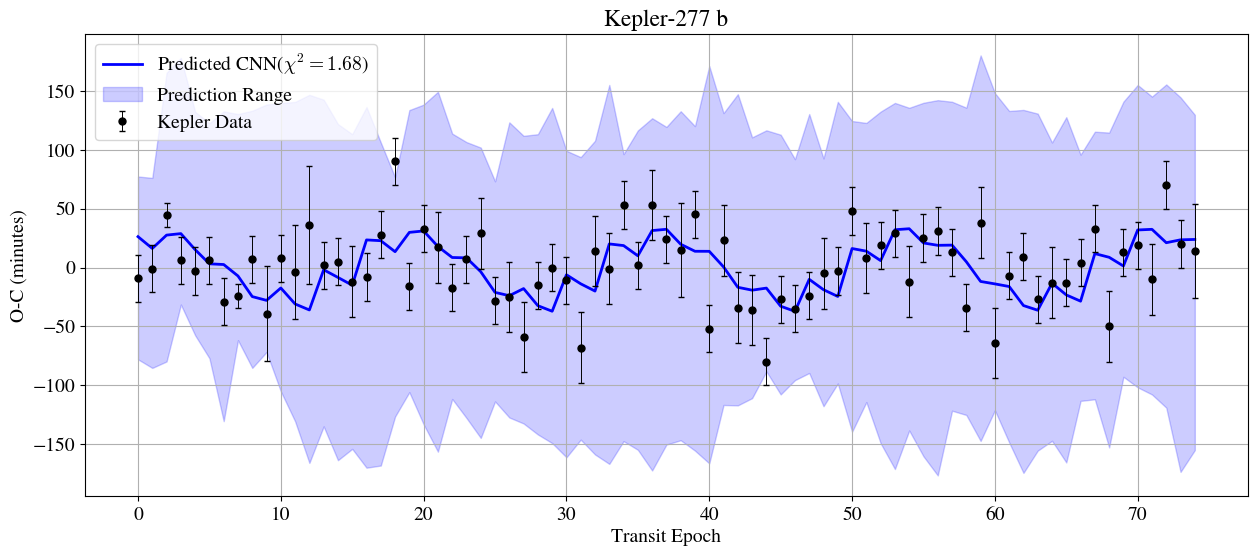

In [ ]:
fig = plt.figure()
fig.set_figheight(6)
fig.set_figwidth(15)
gs = fig.add_gridspec()
axs = gs.subplots()

#df_cnn = pd.read_csv(log_dir+'/'+'/CNN_TTV.csv', header=None)

# Convert to numpy array if needed
#ttv_cnn = df_cnn.to_numpy()


font_ = 14
axs.plot(epoch2[:n_data], T2[0][:n_data]*24*60,'-b', linewidth=2,alpha=1, label=f'Predicted CNN($\\chi^2 = {best_chi2:.2f}$)')
#axs.plot(epoch2[:n_data], ttv_cnn[:n_data],'-r', linewidth=1.5,label=f'Predicted CNN ($\chi^2 = 1.67$)')
#axs.plot(epoch[:n_data], T1[0][:n_data]*24*60,'-',color='green' , linewidth=2, label=f'Previous Study ($\\chi^2 = {chi2_act:.2f}$)')
axs.fill_between(epoch2[:n_data], min_vals[:n_data], max_vals[:n_data], color='blue', alpha=0.2, label='Prediction Range')

axs.errorbar(new_df.index, new_df['O-C'], yerr=new_df['e_O-C'], fmt='o', markersize=5,  # Increase point size
    capsize=2, capthick=1,  # Add caps to error bars for better visibility
    elinewidth=0.7,  # Make error bars slightly thinner
    label='Kepler Data',color='black', alpha =1)
axs.set_ylabel ('O-C (minutes)',fontsize=font_)
axs.set_xlabel('Transit Epoch',fontsize=font_)
#axs.text(0.05, 0.95, f'$\chi_{{\mathrm{{predicted}}}}^2 = {best_chi2:.2f}$', transform=axs.transAxes, fontsize=14, verticalalignment='top')
#axs.text(0.05, 0.85, f'$\chi_{{\mathrm{{actual}}}}^2 = {chi2_act:.2f}$', transform=axs.transAxes, fontsize=14, verticalalignment='top')

axs.set_title(f'{kepler}')

axs.legend(loc='upper left', fontsize=font_)
axs.grid()
plt.savefig(log_dir+'/'+"actual_predict_kepler"+str(kepler)+str(best_chi2)+"_TTVplot_.pdf", dpi=600,bbox_inches = 'tight')

In [ ]:
n_data

107

#MULTI validation


In [ ]:
from scipy.stats import halfnorm
import os

# Define the file path
file_path ="dataset_valid_random_10k.pkl"

try:
    loaded_data = pickle.load(open(file_path,'rb'))
    ttv_ = loaded_data['ttv_data']
    ms_ = loaded_data['star_mass']
    m1_ = loaded_data['transiting_mass']
    p1_ = loaded_data['transiting_period']
    m2_ = loaded_data['perturbing_mass']
    p2_ = loaded_data['perturbing_period']
    o2_ = loaded_data['perturbing_argument_perigee']
    e2_ = loaded_data['perturbing_eccentricity']
    print('There is old file')
except:
    print('creating new file (overwrite)')
    ttv_,ms_,p1_,p2_,m1_,m2_,o2_,e2_ = [],[],[],[],[],[],[],[]



seeds= int(np.random.uniform(0,1e6))
np.random.seed(seeds)


start_time = time.time()
n_sim=0
ext_time=[]
n_data=50
max_ttv = 250
min_ttv = 1
# ms_ = []
# m1_ = []
# p1_ = []
# m2_ = []
# p2_ = []
# o2_ = []
# e2_ = []
# ttv_ = []
len_x= len(ttv_)
n_sample =10000

#ms_,p1_,p2_,m1_,m2_,o2_,e2_=[],[],[],[],[],[],[]
#for ii in tqdm(range(len(X), samples)):
while len_x < n_sample:
  resonance = generate_random_resonance()
  ratio = resonance[0]/resonance[1]
  ms = np.random.uniform(0.5,2)
  m1 = np.random.uniform(5*mearth/msun, 80*mearth/msun)
  p1 = np.random.uniform(5,25)
  m2 = m1*np.random.uniform(0.5,2.5)
  p2 = p1*generate_random_exclude_1(n=1, low=1, high=3)[0]
  o2 = np.random.uniform(0,360)
  #e2 = np.abs(np.random.normal(0,0.01))
  e2 = 0.001*beta.rvs(a=1.5, b=2)
  # if m2 > 90*mearth/msun:
  #   continue

  try:
    ress = ttv_generate(ms=ms, p1=p1, m1=m1,p2=p2,m2=m2,o2=o2,e2=e2)
  except:
    continue
  transit=[]
  epoch=[]
  for i in range (len(ress['positions'][0])):
      if (ress['positions'][0][i]) == 0:
          if (ress['positions'][2][i]) != -2:
              transit.append(ress['positions'][2][i])
              epoch.append(ress['positions'][1][i])
  # if np.any(np.isnan(transit)):
  #     continue
  #print (len_x)
  #
  T1=TTV(epoch,transit)
  if (len(T1[0])) <= n_data or max(T1[0][:n_data]*24*60) > max_ttv or min(T1[0][:n_data]*24*60) < -max_ttv or max(T1[0][:n_data]*24*60) < min_ttv or min(T1[0][:n_data]*24*60) > -min_ttv  or np.isnan(max(T1[0][:n_data])):
    continue
  ttv_.append(T1[0][:50]*24*60)
  ms_.append(ms)
  m1_.append(m1*msun/mearth)
  p1_.append(p1)
  m2_.append(m2*msun/mearth)
  p2_.append(p2)
  o2_.append(o2)
  e2_.append(e2)
  if (len_x%100)==0:
    print(len_x)
  len_x+=1

ttv_=np.array(ttv_)
ms_=np.array(ms_)
m1_=np.array(m1_)
p1_=np.array(p1_)
m2_=np.array(m2_)
p2_=np.array(p2_)
o2_=np.array(o2_)
e2_=np.array(e2_)


There is old file


(array([ 747., 1208., 1420., 1383., 1320., 1292., 1044.,  801.,  566.,
         219.]),
 array([2.38091349e-07, 9.99721716e-05, 1.99706252e-04, 2.99440332e-04,
        3.99174413e-04, 4.98908493e-04, 5.98642573e-04, 6.98376653e-04,
        7.98110734e-04, 8.97844814e-04, 9.97578894e-04]),
 <BarContainer object of 10 artists>)

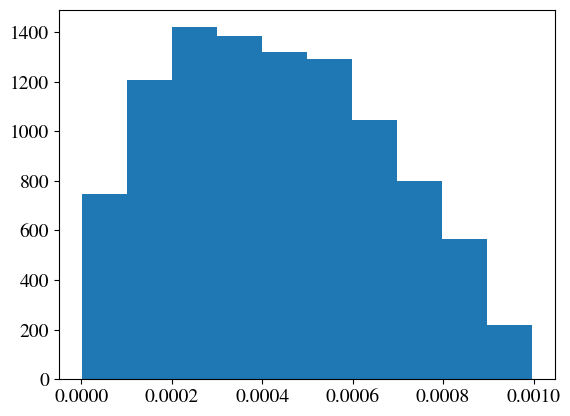

In [ ]:
plt.hist(e2_)

In [ ]:
# prompt: save data above into pkl, and then load it into the same variable

import pickle

# Assuming your data is in variables like ttv_, ms_, m1_, etc.
data_to_save = {
    'ttv_data': ttv_,
    'star_mass': ms_,
    'transiting_mass': m1_,
    'transiting_period': p1_,
    'perturbing_mass': m2_,
    'perturbing_period': p2_,
    'perturbing_argument_perigee': o2_,
    'perturbing_eccentricity': e2_
}

# Save the data to a pickle file
with open(file_path, 'wb') as f:
  pickle.dump(data_to_save, f)
file_path


'/content/gdrive/MyDrive/S3/revisi_paper/revisi_paper/dataset_valid_random_10k.pkl'

In [ ]:
len(ttv_)

10000

In [ ]:
# Load the data back into the same variables
file_path = 'dataset_valid_random_10k.pkl'

with open(file_path, 'rb') as f:
  loaded_data = pickle.load(f)

ttv_ = loaded_data['ttv_data']
ms_ = loaded_data['star_mass']
m1_ = loaded_data['transiting_mass']
p1_ = loaded_data['transiting_period']
m2_ = loaded_data['perturbing_mass']
p2_ = loaded_data['perturbing_period']
o2_ = loaded_data['perturbing_argument_perigee']
e2_ = loaded_data['perturbing_eccentricity']

In [ ]:
max_amplitudes = np.array([np.max(np.abs(curve)) for curve in ttv_])
amps = np.array(max_amplitudes)  # minutes
a0 = 20.0
alpha = 1.5  #  <1 keeps more very-low amps; >1 is more aggressive

def retention_prob(a):
    return np.minimum(1.0, (a / a0)**alpha)

probs = retention_prob(amps)
keep_mask = np.random.rand(len(amps)) < probs

# ensure all samples >= a0 kept
keep_mask = keep_mask | (amps >= a0)

In [ ]:
ttv_ = loaded_data['ttv_data'][keep_mask]
ms_ = loaded_data['star_mass'][keep_mask]
m1_ = loaded_data['transiting_mass'][keep_mask]
p1_ = loaded_data['transiting_period'][keep_mask]
m2_ = loaded_data['perturbing_mass'][keep_mask]
p2_ = loaded_data['perturbing_period'][keep_mask]
o2_ = loaded_data['perturbing_argument_perigee'][keep_mask]
e2_ = loaded_data['perturbing_eccentricity'][keep_mask]

len(ttv_)

4448

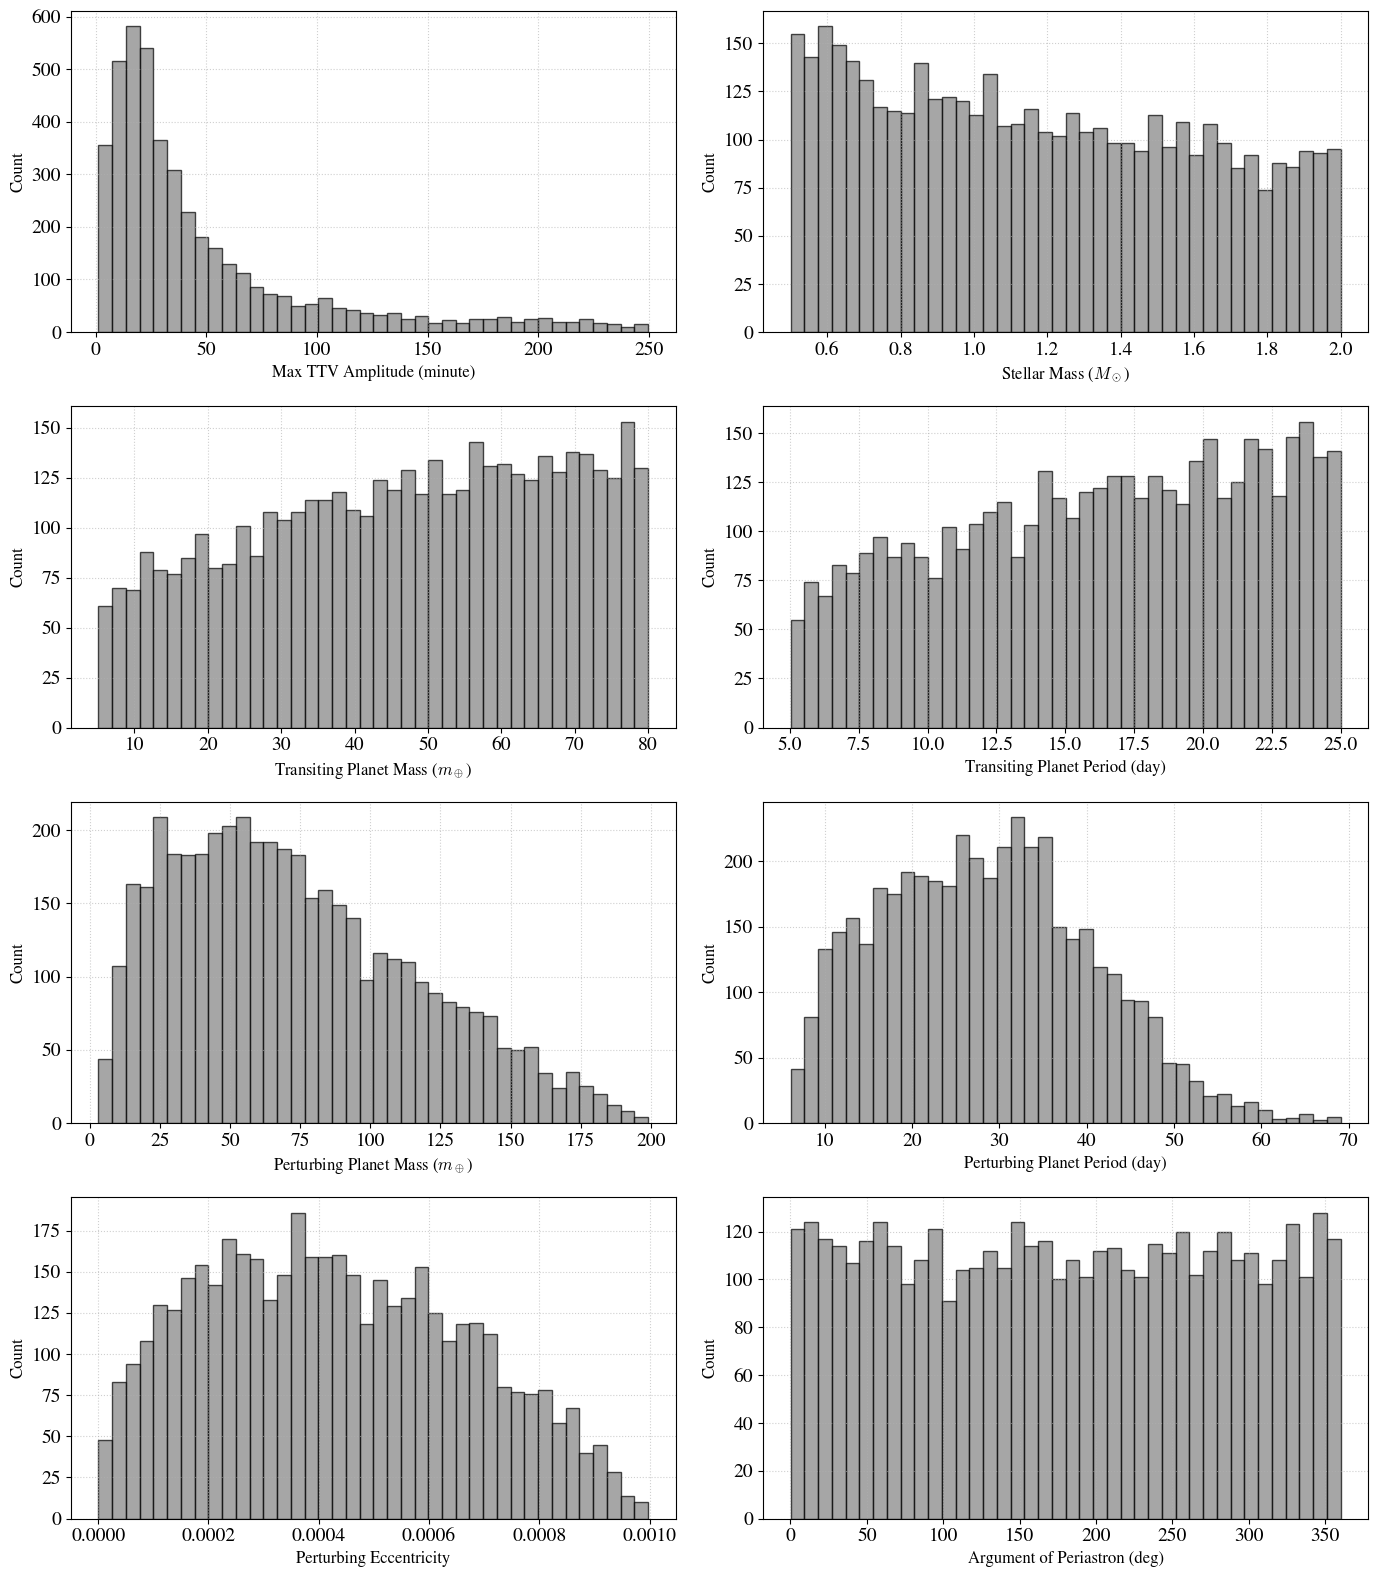

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Compute TTV amplitude for histogram
ttv_amplitude = np.array([np.max(np.abs(curve)) for curve in ttv_])

# Prepare figure
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

# List of variables and labels
variables = [
    (ttv_amplitude, r"Max TTV Amplitude (minute)"),
    (ms_, r"Stellar Mass ($M_\odot$)"),
    (m1_, r"Transiting Planet Mass ($m_\oplus$)"),
    (p1_, r"Transiting Planet Period (day)"),
    (m2_, r"Perturbing Planet Mass ($m_\oplus$)"),
    (p2_, r"Perturbing Planet Period (day)"),
    (e2_, r"Perturbing Eccentricity"),
    (o2_, r"Argument of Periastron (deg)")
]

# Plot histograms
for ax, (data, label) in zip(axes, variables):
    ax.hist(data, bins=40, color='gray', edgecolor='black', alpha=0.7)
    ax.set_xlabel(label, fontsize=12)
    ax.set_ylabel("Count", fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.6)

# Adjust layout
plt.tight_layout()
plt.savefig("histograms_all_variables.pdf", dpi=600, bbox_inches='tight')
plt.show()


In [ ]:
import os
def ensure_1d(x):
    """Ensure the input is a 1-D numpy array."""
    x = np.array(x)
    if x.ndim > 1:
        x = x.flatten()
    return x

def save_predictions_to_csv(
    m2_pred, p2_pred, o2_pred, e2_pred,
    m2_true, p2_true, o2_true, e2_true,
    m2_unc, p2_unc, o2_unc, e2_unc,
    log_dir=".", filename="predictions.csv", append=False
):
    # Ensure all inputs are 1-D arrays
    m2_pred = ensure_1d(m2_pred)
    p2_pred = ensure_1d(p2_pred)
    o2_pred = ensure_1d(o2_pred)
    e2_pred = ensure_1d(e2_pred)
    m2_true = ensure_1d(m2_true)
    p2_true = ensure_1d(p2_true)
    o2_true = ensure_1d(o2_true)
    e2_true = ensure_1d(e2_true)
    m2_unc = ensure_1d(m2_unc)
    p2_unc = ensure_1d(p2_unc)
    o2_unc = ensure_1d(o2_unc)
    e2_unc = ensure_1d(e2_unc)

    # Build dataframe
    df = pd.DataFrame({
        "Mass_True": m2_true,
        "Mass_Pred": m2_pred,
        "Mass_Unc": m2_unc,
        "Period_True": p2_true,
        "Period_Pred": p2_pred,
        "Period_Unc": p2_unc,
        "ArgumentPerigee_True": o2_true,
        "ArgumentPerigee_Pred": o2_pred,
        "ArgumentPerigee_Unc": o2_unc,
        "Eccentricity_True": e2_true,
        "Eccentricity_Pred": e2_pred,
        "Eccentricity_Unc": e2_unc
    })

    # Ensure directory exists
    os.makedirs(log_dir, exist_ok=True)
    csv_path = os.path.join(log_dir, filename)

    # Append or overwrite
    if append and os.path.exists(csv_path):
        df.to_csv(csv_path, mode='a', header=False, index=False)
    else:
        df.to_csv(csv_path, index=False)

    print(f"✅ Predictions with uncertainties saved to: {csv_path}")
    return csv_path

In [ ]:
# for i in range(len(ttv_)):
#   plt.plot(ttv_[i])

# len(ttv_)



In [ ]:
model_

'model_logs_CNN/experiment_2025-12-31_15-26-57/exoplanet_ens_model_tanh_datatrain_paper2_10k_250_filtered_LSTM_16_Nov.keras'

In [ ]:


from tensorflow.keras.models import load_model
import numpy as np

# Load the saved model with dropout layers
#model_ = '/content/gdrive/MyDrive/S3/new_ml_model/exoplanet_ens_model_10k.keras'
#model_ = '/content/gdrive/MyDrive/S3/new_ml_mZodel/exoplanet_ens_model_15k.keras'
#model_ = '/content/gdrive/MyDrive/S3/new_ml_model/exoplanet_ens_model_10k_noise5.keras'
#model_ = '/content/gdrive/MyDrive/S3/new_ml_model/exoplanet_ens_model_improve.keras'
#model_ = '/content/gdrive/MyDrive/S3/model_rev/exoplanet_ens_model_tanh_'+datatrain_name+'.keras'
saved_model = load_model(model_, compile=False)

# Define the function for predicting with uncertainty
predict_fn = tf.function(lambda x, training: saved_model(x, training=training))

# Assuming new data is available in the same format as the training data
# Example new data for prediction
#m_trans_pred = [(m1*msun/mearth)]

new_ttv_data = ttv_#T1[0][:50] * 24 * 60  # Example data
new_star_mass = ms_  # Example data
new_transiting_period = p1_  # Example data
new_transiting_mass = m1_ # Example data

# Reshape new_ttv_data to be 3D (samples, timesteps, features)
n_timesteps = new_ttv_data.shape[1]
num_samples=new_ttv_data.shape[0]
# Reshape new_ttv_data to be 3D (samples, timesteps, features)
new_ttv_data = new_ttv_data.reshape((num_samples, n_timesteps, 1))


# Ensure other inputs are arrays and match expected input dimensions
new_star_mass = new_star_mass.reshape((num_samples, 1))  # Assuming multiple samples
new_transiting_period = new_transiting_period.reshape((num_samples, 1))  # Assuming multiple samples
new_transiting_mass = new_transiting_mass.reshape((num_samples, 1))  # Assuming multiple samples

# Normalize new data
new_ttv_data = scaler_ttv.transform(new_ttv_data.reshape(-1, 1)).reshape(new_ttv_data.shape)
new_star_mass = scaler_star_mass.transform(new_star_mass.reshape(-1, 1))
new_transiting_period = scaler_transiting_period.transform(new_transiting_period.reshape(-1, 1))
new_transiting_mass = scaler_transiting_mass.transform(new_transiting_mass.reshape(-1, 1))

# Combine the inputs into the required format
new_X_inputs = [new_ttv_data, new_star_mass, new_transiting_period, new_transiting_mass]

# # Predict with uncertainty
# predictions, uncertainties = predict_with_uncertainty(predict_fn, new_X_inputs, n_iter=100)

# # The predictions and uncertainties will be lists of arrays corresponding to each output
# predicted_mass = scaler_mass_output.inverse_transform(predictions[0])[:]
# predicted_period = scaler_period_output.inverse_transform(predictions[1])[:]
# predicted_eccentricity = scaler_eccentricity_output.inverse_transform(predictions[2])[:]
# predicted_argument_perigee = scaler_argument_perigee_output.inverse_transform(predictions[3])[:]

# mass_uncertainty = scaler_mass_output.inverse_transform(uncertainties[0])[:]
# period_uncertainty = scaler_period_output.inverse_transform(uncertainties[1])[:]
# eccentricity_uncertainty = scaler_eccentricity_output.inverse_transform(uncertainties[2])[:]
# argument_perigee_uncertainty = scaler_argument_perigee_output.inverse_transform(uncertainties[3])[:]

# # Print the predictions and uncertainties
# print("Predicted mass of perturbing planet:", predicted_mass, "±", mass_uncertainty)
# print("Predicted period of perturbing planet:", predicted_period, "±", period_uncertainty)
# print("Predicted eccentricity of perturbing planet:", predicted_eccentricity, "±", eccentricity_uncertainty)
# print("Predicted argument of perigee of perturbing planet:", predicted_argument_perigee, "±", argument_perigee_uncertainty)


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model

# --- Assume new_X_inputs now has shape (N_systems, N_features) ---
# N_systems = new_X_inputs.shape[0]

# ---------------------------------------------------------
# 1. SETUP
# ---------------------------------------------------------
# Load model (Assuming model_, new_X_inputs, and scalers are defined elsewhere)
# model_path = '...'
saved_model = load_model(model_, compile=False)
predict_fn = tf.function(lambda x, training: saved_model(x, training=training))

# ---------------------------------------------------------
# 2. RUN MC DROPOUT (Collect Raw Samples)
# ---------------------------------------------------------
n_iter = 100 # Number of stochastic passes
print(f"Running {n_iter} stochastic forward passes...")

# This list will hold n_iter raw predictions.
# Each element in raw_results will be a TensorFlow tensor of shape (N_systems, N_parameters)
# If N_systems=1, it's (1, 4). If N_systems=5, it's (5, 4).
# We assume the model output order is: [Mass, Period, Ecc, Omega]
raw_results = [predict_fn(new_X_inputs, training=True) for _ in range(n_iter)]

# ---------------------------------------------------------
# 3. PROCESS DATA (Corrected Logic for Multiple Systems)
# ---------------------------------------------------------
# Let N_systems be the number of systems in the input batch
N_systems = new_ttv_data.shape[1]
N_params = 4 # Mass, Period, Ecc, Omega

# Step A: Gather raw normalized data
# The result will be a list of 4 arrays, each of shape (n_iter, N_systems)
# The output for the j-th parameter is: [prediction_run_1[j], prediction_run_2[j], ..., prediction_run_100[j]]
raw_mass  = np.array([r[0].numpy().reshape(-1) for r in raw_results])     # (n_iter, N_systems)
raw_period = np.array([r[1].numpy().reshape(-1) for r in raw_results])
raw_ecc   = np.array([r[2].numpy().reshape(-1) for r in raw_results])
raw_omega = np.array([r[3].numpy().reshape(-1) for r in raw_results])

# Step B: Inverse Transform ALL 100 samples to Real Units FIRST
# Reshape for the scaler: (n_iter * N_systems, 1) to apply inverse_transform
N_systems = raw_mass.shape[1]   # ensures correct reshape

# Now reshape correctly for inverse_transform → then reshape back
real_mass_samples = scaler_mass_output.inverse_transform(
    raw_mass.reshape(n_iter * N_systems, 1)
).reshape(n_iter, N_systems)

real_period_samples = scaler_period_output.inverse_transform(
    raw_period.reshape(n_iter * N_systems, 1)
).reshape(n_iter, N_systems)

real_ecc_samples = scaler_eccentricity_output.inverse_transform(
    raw_ecc.reshape(n_iter * N_systems, 1)
).reshape(n_iter, N_systems)

real_omega_samples = scaler_argument_perigee_output.inverse_transform(
    raw_omega.reshape(n_iter * N_systems, 1)
).reshape(n_iter, N_systems)
# The new samples shape is (n_iter, N_systems).
# Axis 0 is the MC Dropout samples (n_iter).
# Axis 1 is the different input systems (N_systems).

# Step C: Calculate Mean (Prediction) and Std Dev (Uncertainty) from Real Units
# We calculate the mean and std dev across the n_iter axis (axis=0)
# The result for each will be a numpy array of shape (N_systems,)

# Prediction is the Mean of the 100 samples FOR EACH SYSTEM
predicted_mass = np.mean(real_mass_samples, axis=0)         # Shape (N_systems,)
predicted_period = np.mean(real_period_samples, axis=0)     # Shape (N_systems,)
predicted_eccentricity = np.mean(real_ecc_samples, axis=0) # Shape (N_systems,)
predicted_argument_perigee = np.mean(real_omega_samples, axis=0) # Shape (N_systems,)

# Uncertainty is the Std Dev of the 100 samples FOR EACH SYSTEM
mass_uncertainty = np.std(real_mass_samples, axis=0)               # Shape (N_systems,)
period_uncertainty = np.std(real_period_samples, axis=0)           # Shape (N_systems,)
eccentricity_uncertainty = np.std(real_ecc_samples, axis=0)       # Shape (N_systems,)
argument_perigee_uncertainty = np.std(real_omega_samples, axis=0) # Shape (N_systems,)


# ---------------------------------------------------------
# 4. PRINT RESULTS
# ---------------------------------------------------------

print(f"\n--- Results for {N_systems} Systems ---")

# # Now, loop through the systems to print results
# for i in range(N_systems):
#     print(f"\n✨ System {i+1}:")
#     print(f"  Mass: {predicted_mass[i]:.4f} ± {mass_uncertainty[i]:.4f}")
#     print(f"  Period: {predicted_period[i]:.4f} ± {period_uncertainty[i]:.4f}")
#     print(f"  Eccentricity: {predicted_eccentricity[i]:.4f} ± {eccentricity_uncertainty[i]:.4f}")
#     print(f"  Argument of Perigee: {predicted_argument_perigee[i]:.4f} ± {argument_perigee_uncertainty[i]:.4f}")

# ---------------------------------------------------------
# # OPTIONAL: Check the Gaussian Distribution for Mass (For the Reviewer)
# # ---------------------------------------------------------
# # To check the distribution for a specific system (e.g., the first one, index 0)
# # import matplotlib.pyplot as plt
# # import seaborn as sns
# #
# # plt.figure(figsize=(6, 4))
# # sns.histplot(real_mass_samples[:, 0], kde=True, bins=15)
# # plt.title("Distribution of Mass Predictions (System 1)")
# # plt.xlabel("Mass")
# # plt.show()

Running 100 stochastic forward passes...

--- Results for 4448 Systems ---


In [ ]:
csv_path = save_predictions_to_csv(
    predicted_mass, predicted_period, predicted_argument_perigee, predicted_eccentricity,
    m2_, p2_, o2_, e2_,
    mass_uncertainty, period_uncertainty, argument_perigee_uncertainty, eccentricity_uncertainty,
    log_dir=log_dir,
    filename=f"ttv_predictions_with_unc_5k.csv",
    append=True  # set True to add new rows if looping
    )

✅ Predictions with uncertainties saved to: model_logs_CNN/experiment_2025-12-31_15-26-57/ttv_predictions_with_unc_5k.csv


In [ ]:
df_pred = pd.read_csv("model_logs_CNN/experiment_2025-12-31_15-26-57/ttv_predictions_with_unc_5k.csv")
df_pred.columns

Index(['Mass_True', 'Mass_Pred', 'Mass_Unc', 'Period_True', 'Period_Pred',
       'Period_Unc', 'ArgumentPerigee_True', 'ArgumentPerigee_Pred',
       'ArgumentPerigee_Unc', 'Eccentricity_True', 'Eccentricity_Pred',
       'Eccentricity_Unc'],
      dtype='object')

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ---------------------------------------
# Noise levels and base path
# ---------------------------------------
noise_levels = [0.1, 0.2, 0.3, 0.4, 0.5]
base_path = ""

# ---------------------------------------
# Parameters to evaluate
# ---------------------------------------
params = [
    ("Mass_True", "Mass_Pred", "Mass"),
    ("Period_True", "Period_Pred", "Period"),
    ("ArgumentPerigee_True", "ArgumentPerigee_Pred", "Argument of Periastron")
]

# ---------------------------------------
# Storage for results
# ---------------------------------------
results = []

# ---------------------------------------
# Loop through noise levels
# ---------------------------------------
for noise in noise_levels:
    filename = f"{base_path}ttv_predictions_with_unc_noise_{noise}.csv"
    df = pd.read_csv(filename)

    for true_col, pred_col, label in params:

        y_true = df[true_col].values
        y_pred = df[pred_col].values

        R2 = r2_score(y_true, y_pred)
        MAE = mean_absolute_error(y_true, y_pred)
        RMSE = np.sqrt(mean_squared_error(y_true, y_pred))

        results.append({
            "Noise_Level": noise,
            "Parameter": label,
            "R2": R2,
            "MAE": MAE,
            "RMSE": RMSE
        })

# ---------------------------------------
# Convert to DataFrame
# ---------------------------------------
results_df = pd.DataFrame(results)

# Show results
print(results_df)

# Save to CSV if needed
results_df.to_csv("performance_vs_noise.csv", index=False)


FileNotFoundError: [Errno 2] No such file or directory: '/content/gdrive/MyDrive/S3/revisi_paper/revisi_paper/model_logs_LSTM/experiment_2025-11-22_21-28-54/ttv_predictions_with_unc_noise_0.1.csv'

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# =========================================================
# SETTINGS
# =========================================================
noise_levels = [0.1, 0.2, 0.3, 0.4, 0.5]

base_path = "/content/gdrive/MyDrive/S3/revisi_paper/revisi_paper/model_logs_LSTM/experiment_2025-11-22_21-28-54/"
filename_template = "ttv_predictions_with_unc_noise_{}.csv"

params = {
    "Mass": ("Mass_True", "Mass_Pred"),
    "Period": ("Period_True", "Period_Pred"),
    "ArgumentPeriastron": ("ArgumentPerigee_True", "ArgumentPerigee_Pred"),
}

# Store results
results = {metric: {param: [] for param in params.keys()}
           for metric in [r"$R^2$", "MAE", "RMSE"]}

# =========================================================
# COMPUTE METRICS
# =========================================================
for nl in noise_levels:
    df = pd.read_csv(base_path + filename_template.format(nl))

    for param, (true_col, pred_col) in params.items():
        y_true = df[true_col].values
        y_pred = df[pred_col].values

        # Metrics
        r2 = r2_score(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        results[r"$R^2$"][param].append(r2)
        results["MAE"][param].append(mae)
        results["RMSE"][param].append(rmse)

# Convert to DataFrame for easier viewing (optional)
results_df = {metric: pd.DataFrame(results[metric], index=noise_levels)
              for metric in results.keys()}

results_df[r"$R^2$"], results_df["MAE"], results_df["RMSE"]


In [ ]:
# =========================================================
# PLOTTING
# =========================================================

metrics = [r"$R^2$", "MAE", "RMSE"]
colors = ["tab:blue", "tab:orange", "tab:green"]
param_list = list(params.keys())

for metric in metrics:
    plt.figure(figsize=(12,5))
    width = 0.25
    x = np.arange(len(noise_levels))

    for i, param in enumerate(param_list):
        plt.bar(x + i*width,
                results[metric][param],
                width=width,
                label=param,
                color=colors[i])

    plt.xticks(x + width, noise_levels)
    plt.xlabel("Noise Level")
    plt.ylabel(metric)
    #plt.title(f"{metric} vs Noise Level")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.savefig(f"{metric} vs Noise Level.pdf", dpi = 300, bbox_inches = 'tight')
    plt.show()


NameError: name 'params' is not defined

In [ ]:
predicted_mass = df_pred['Mass_Pred'].values
predicted_period = df_pred['Period_Pred'].values
predicted_eccentricity = df_pred['Eccentricity_Pred'].values
predicted_argument_perigee = df_pred['ArgumentPerigee_Pred'].values
m2_ = df_pred['Mass_True'].values
p2_ = df_pred['Period_True'].values
o2_ = df_pred['ArgumentPerigee_True'].values
e2_ = df_pred['Eccentricity_True'].values
mass_uncertainty = df_pred['Mass_Unc'].values
period_uncertainty = df_pred['Period_Unc'].values
eccentricity_uncertainty = df_pred['Eccentricity_Unc'].values
argument_perigee_uncertainty = df_pred['ArgumentPerigee_Unc'].values

In [ ]:
len(predicted_mass)

4465

Akurasi Massa :  59.89208633093526 %
Akurasi Periode :  82.32913669064749 %
Akurasi Overall : 52.27068345323741 %


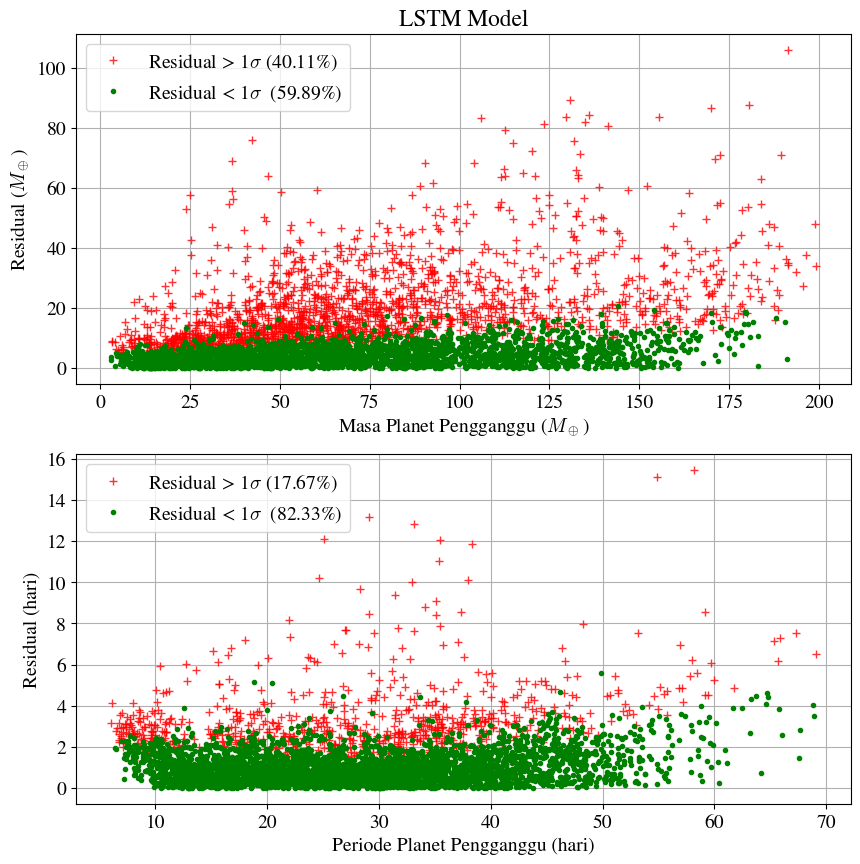

In [ ]:
residual_m=[]
residual_p=[]
residual_e=[]
residual_o=[]

unc_m = []
unc_p = []
unc_e = []
unc_o = []

mass_percent = 0
period_percent = 0
overall_percent = 0

right_mass=[]
right_period=[]
overall=[]
n_sigma=1
for i in range (len(ttv_)):
  residual_m.append(abs(predicted_mass[i]-m2_[i]))
  residual_p.append(abs(predicted_period[i]-p2_[i]))
  residual_e.append(predicted_eccentricity[i]-e2_[i])
  residual_o.append(predicted_argument_perigee[i]-o2_[i])

  unc_m.append(mass_uncertainty[i])
  unc_p.append(period_uncertainty[i])
  unc_e.append(eccentricity_uncertainty[i])
  unc_o.append(argument_perigee_uncertainty[i])

  if abs(predicted_mass[i]-m2_[i]) < n_sigma*mass_uncertainty[i]:
    mass_percent += 1
    right_mass.append(int(i))

  if abs(predicted_period[i]-p2_[i]) < n_sigma*period_uncertainty[i]:
    period_percent += 1
    right_period.append(i)
  if abs(predicted_mass[i]-m2_[i]) < n_sigma*mass_uncertainty[i] and abs(predicted_period[i]-p2_[i]) < n_sigma*period_uncertainty[i]:
    overall.append(i)
    overall_percent += 1

mass_acc = mass_percent/len(residual_m)
period_acc = period_percent/len(residual_p)
overall_acc = overall_percent/len(residual_m)

print("Akurasi Massa : ", mass_acc*100, "%")
print("Akurasi Periode : ", period_acc*100, "%")
print("Akurasi Overall :", overall_acc*100, "%")

right_mass = np.array(right_mass)
right_period = np.array(right_period)

residual_m = np.array(residual_m)
residual_p = np.array(residual_p)
residual_e = np.array(residual_e)
residual_o = np.array(residual_o)

mask_m = np.ones(len(residual_m), dtype=bool)
mask_p = np.ones(len(residual_p), dtype=bool)

#print(right_period)
# Set the mask to False at the indices to exclude
mask_m[right_mass] = False
mask_p[right_period] = False



fig,axs = plt.subplots(2,1,figsize=(10,10))
axs[0].plot(m2_[mask_m], residual_m[mask_m],'r+',alpha=0.8, label=r'Residual > '+str(n_sigma)+'$\sigma$ ('+str(round(100-mass_acc*100,2))+'%)')
#axs[0].plot(unc_m,label='Ketidakpastian')
axs[0].set_title('LSTM Model')
axs[0].plot(m2_[right_mass], residual_m[right_mass],'g.', label=r'Residual < '+str(n_sigma)+'$\sigma$  ('+ str(round(mass_acc*100,2)) +"%)")
axs[0].legend()
axs[0].set_ylabel(r'Residual ($M_\oplus$)')
axs[0].set_xlabel(r'Masa Planet Pengganggu ($M_\oplus$)')
#axs[0].set_title('Masa')
axs[0].grid()

axs[1].plot(p2_[mask_p], residual_p[mask_p], 'r+',alpha=0.8,label=r'Residual > '+str(n_sigma)+'$\sigma$ ('+str(round(100-period_acc*100,2))+'%)')
#axs[1].plot(unc_p, label='Ketidakpastian')
axs[1].plot(p2_[right_period], residual_p[right_period],'g.',  label=r'Residual < '+str(n_sigma)+'$\sigma$  ('+ str(round(period_acc*100,2)) +"%)")
axs[1].legend()
axs[1].set_ylabel('Residual (hari)')
axs[1].set_xlabel('Periode Planet Pengganggu (hari)')
#axs[1].set_title('Period')
axs[1].grid()


# axs[2].plot(residual_e, label='residual')
# axs[2].plot(unc_e, label='Ketidakpastian')
# axs[2].legend()
# axs[2].set_title('Eccentricity')

# axs[3].plot(residual_o, label='residual')
# axs[3].plot(unc_o, label='Ketidakpastian')
# axs[3].legend()
# axs[3].set_title('Argument of Perigee')
plt.savefig(log_dir+'/'+"Residual_lstm_.pdf", dpi=600, bbox_inches = 'tight')
plt.show()



In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

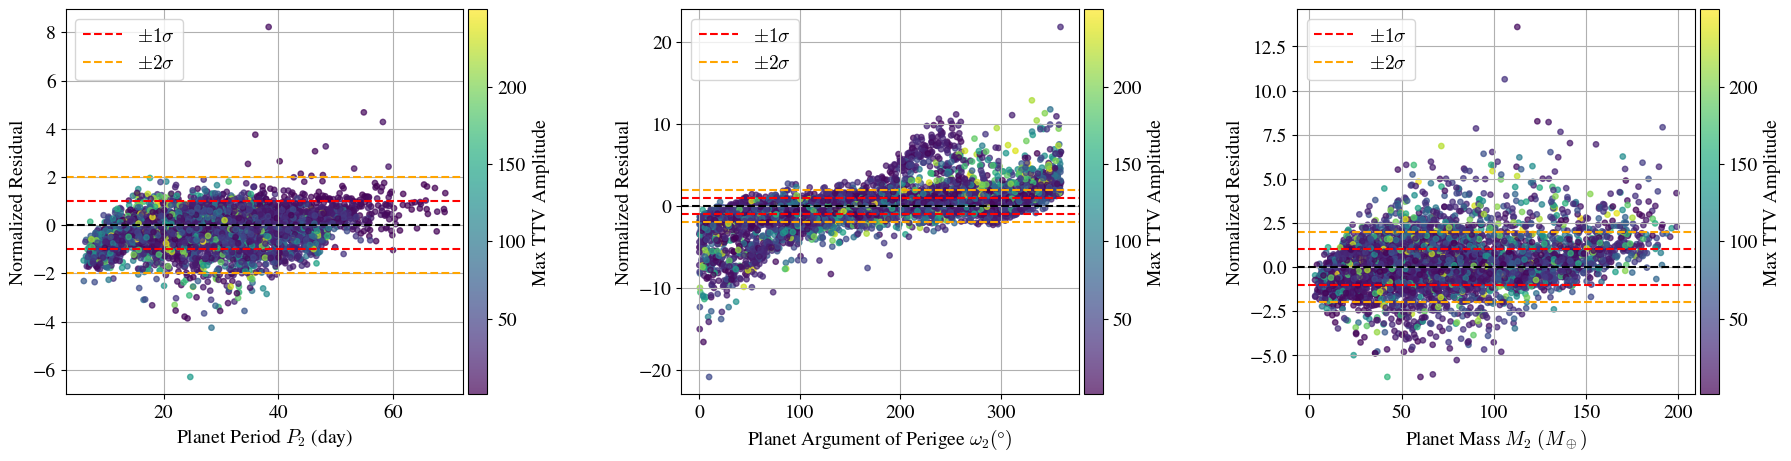

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- ASSUMPTION: CALCULATE MAX TTV AMPLITUDE ---
# This variable must be calculated beforehand.
# Assuming ttv_ is available and is a list/array of TTV curves:
try:
    # Ensure this line is run in your environment BEFORE the plotting code
    # to define max_ttv_amplitude
    max_ttv_amplitude = np.array([np.max(np.abs(curve)) for curve in ttv_])
except NameError:
    # Fallback/Placeholder: You MUST define ttv_ or max_ttv_amplitude yourself.
    print("WARNING: 'ttv_' or 'max_ttv_amplitude' is not defined. Using placeholder data for color mapping.")
    # Create placeholder data for demonstration if the actual variable is missing
    max_ttv_amplitude = np.random.rand(len(m2_)) * 10
except Exception as e:
    print(f"Error calculating max_ttv_amplitude: {e}")
    # Handle error or exit if calculation fails

# Use the uncertainty names from your provided code
unc_p = period_uncertainty # Assuming you defined these earlier
unc_o = argument_perigee_uncertainty
unc_m = mass_uncertainty

# Reshape all necessary arrays once (assuming they are 1D arrays of the same length)
N = len(m2_)
p2_r = p2_.reshape(N)
o2_r = o2_.reshape(N)
m2_r = m2_.reshape(N)

predicted_period_r = predicted_period.reshape(N)
predicted_argument_perigee_r = predicted_argument_perigee.reshape(N)
predicted_mass_r = predicted_mass.reshape(N)

unc_p_r = np.array(unc_p).reshape(N)
unc_o_r = np.array(unc_o).reshape(N)
unc_m_r = np.array(unc_m).reshape(N)


# --- PLOTTING CODE MODIFIED TO USE SCATTER AND COLOR ---

fig, axes = plt.subplots(1, 3, figsize=(22, 5))
fig.subplots_adjust(wspace=0.3)
cmap = 'viridis' # Color map for the amplitude

# 1. Period residuals (Normalized)
sc1 = axes[0].scatter(p2_r, (p2_r - predicted_period_r) / unc_p_r,
                      c=max_ttv_amplitude, # Color based on Max TTV Amplitude
                      s=15, alpha=0.7, cmap=cmap)

axes[0].set_xlabel(r'Planet Period $P_2$ (day)')
axes[0].set_ylabel('Normalized Residual')
axes[0].axhline(0, color='black', linestyle='dashed')
axes[0].axhline(1, color='red', linestyle='dashed', label='$\pm 1\sigma$')
axes[0].axhline(-1, color='red', linestyle='dashed')
axes[0].axhline(2, color='orange', linestyle='dashed', label='$\pm 2\sigma$')
axes[0].axhline(-2, color='orange', linestyle='dashed')
axes[0].legend(loc='upper left')
axes[0].grid(True)
# Use the scatter object (sc1) for the colorbar
cbar1 = fig.colorbar(sc1, ax=axes[0], orientation='vertical', label='Max TTV Amplitude', pad=0.01)


# 2. Argument of Perigee residuals (Normalized)
sc2 = axes[1].scatter(o2_r, (o2_r - predicted_argument_perigee_r) / unc_o_r,
                      c=max_ttv_amplitude, # Color based on Max TTV Amplitude
                      s=15, alpha=0.7, cmap=cmap)

axes[1].set_xlabel(r'Planet Argument of Perigee $\omega_2 (\degree)$')
axes[1].set_ylabel('Normalized Residual')
axes[1].axhline(0, color='black', linestyle='dashed')
axes[1].axhline(1, color='red', linestyle='dashed', label='$\pm 1\sigma$')
axes[1].axhline(-1, color='red', linestyle='dashed')
axes[1].axhline(2, color='orange', linestyle='dashed', label='$\pm 2\sigma$')
axes[1].axhline(-2, color='orange', linestyle='dashed')
axes[1].legend(loc='upper left')
axes[1].grid(True)
cbar2 = fig.colorbar(sc2, ax=axes[1], orientation='vertical', label='Max TTV Amplitude', pad=0.01)


# 3. Mass residuals (Normalized)
sc3 = axes[2].scatter(m2_r, (m2_r - predicted_mass_r) / unc_m_r,
                      c=max_ttv_amplitude, # Color based on Max TTV Amplitude
                      s=15, alpha=0.7, cmap=cmap)

axes[2].set_xlabel(r'Planet Mass $M_2$ $(M_\oplus)$')
axes[2].set_ylabel('Normalized Residual')
axes[2].axhline(0, color='black', linestyle='dashed')
axes[2].axhline(1, color='red', linestyle='dashed', label='$\pm 1\sigma$')
axes[2].axhline(-1, color='red', linestyle='dashed')
axes[2].axhline(2, color='orange', linestyle='dashed', label='$\pm 2\sigma$')
axes[2].axhline(-2, color='orange', linestyle='dashed')
axes[2].legend(loc='upper left')
axes[2].grid(True)

# Use the scatter object (sc3) for the colorbar
cbar3 = fig.colorbar(sc3, ax=axes[2], orientation='vertical', label='Max TTV Amplitude', pad=0.01)


plt.savefig(log_dir + '/' + 'combined_scatter_residuals_amplitude.pdf', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- ASSUMPTION: CALCULATE MAX TTV AMPLITUDE ---
# This variable MUST be calculated beforehand using your loaded 'ttv_' data.
# Assuming ttv_ is available and is a list/array of TTV curves:
try:
    # Ensure this line is run in your environment BEFORE the plotting code
    # to define max_ttv_amplitude
    max_ttv_amplitude = np.array([np.max(np.abs(curve)) for curve in ttv_])
except NameError:
    print("WARNING: 'ttv_' or 'max_ttv_amplitude' is not defined. Using placeholder data for color mapping.")
    # Create placeholder data for demonstration if the actual variable is missing
    max_ttv_amplitude = np.random.rand(len(m2_)) * 10
except Exception as e:
    print(f"Error calculating max_ttv_amplitude: {e}")
    # Handle error or exit if calculation fails

# Reshape all necessary arrays once (assuming they are 1D arrays of the same length)
N = len(m2_)
# True values
p2_r = p2_.reshape(N)
o2_r = o2_.reshape(N)
m2_r = m2_.reshape(N)

# Predicted values
predicted_period_r = predicted_period.reshape(N)
predicted_argument_perigee_r = predicted_argument_perigee.reshape(N)
predicted_mass_r = predicted_mass.reshape(N)


# --- PLOTTING CODE MODIFIED TO USE SCATTER AND RAW RESIDUALS ---

fig, axes = plt.subplots(1, 3, figsize=(22, 5))
fig.subplots_adjust(wspace=0.3)
cmap = 'viridis' # Color map for the amplitude

# 1. Period residuals (Non-Normalized)
sc1 = axes[0].scatter(p2_r, (p2_r - predicted_period_r), # NON-NORMALIZED RESIDUAL
                      c=max_ttv_amplitude, # Color based on Max TTV Amplitude
                      s=15, alpha=0.7, cmap=cmap)

axes[0].set_xlabel(r'True Planet Period $P_2$ (day)')
axes[0].set_ylabel(r'Period Residual ($\text{True } P_2 - \text{Predicted } P_2$)')
axes[0].axhline(0, color='black', linestyle='dashed', linewidth=2)
axes[0].grid(True)
cbar1 = fig.colorbar(sc1, ax=axes[0], orientation='vertical', label='Max TTV Amplitude', pad=0.01)


# 2. Argument of Perigee residuals (Non-Normalized)
sc2 = axes[1].scatter(o2_r, (o2_r - predicted_argument_perigee_r), # NON-NORMALIZED RESIDUAL
                      c=max_ttv_amplitude, # Color based on Max TTV Amplitude
                      s=15, alpha=0.7, cmap=cmap)

axes[1].set_xlabel(r'True Argument of Perigee $\omega_2 (\degree)$')
axes[1].set_ylabel(r'Arg. of Perigee Residual ($\text{True } \omega_2 - \text{Predicted } \omega_2$)')
axes[1].axhline(0, color='black', linestyle='dashed', linewidth=2)
axes[1].grid(True)
cbar2 = fig.colorbar(sc2, ax=axes[1], orientation='vertical', label='Max TTV Amplitude', pad=0.01)


# 3. Mass residuals (Non-Normalized)
sc3 = axes[2].scatter(m2_r, (m2_r - predicted_mass_r), # NON-NORMALIZED RESIDUAL
                      c=max_ttv_amplitude, # Color based on Max TTV Amplitude
                      s=15, alpha=0.7, cmap=cmap)

axes[2].set_xlabel(r'True Planet Mass $M_2$ $(M_\oplus)$')
axes[2].set_ylabel(r'Mass Residual ($\text{True } M_2 - \text{Predicted } M_2$)')
axes[2].axhline(0, color='black', linestyle='dashed', linewidth=2)
axes[2].grid(True)

cbar3 = fig.colorbar(sc3, ax=axes[2], orientation='vertical', label='Max TTV Amplitude', pad=0.01)

# Note: Removed the legend for ±sigma lines as they are irrelevant for non-normalized residuals

plt.savefig(log_dir + '/' + 'combined_scatter_residuals_raw_amplitude.pdf', dpi=600, bbox_inches='tight')
plt.show()

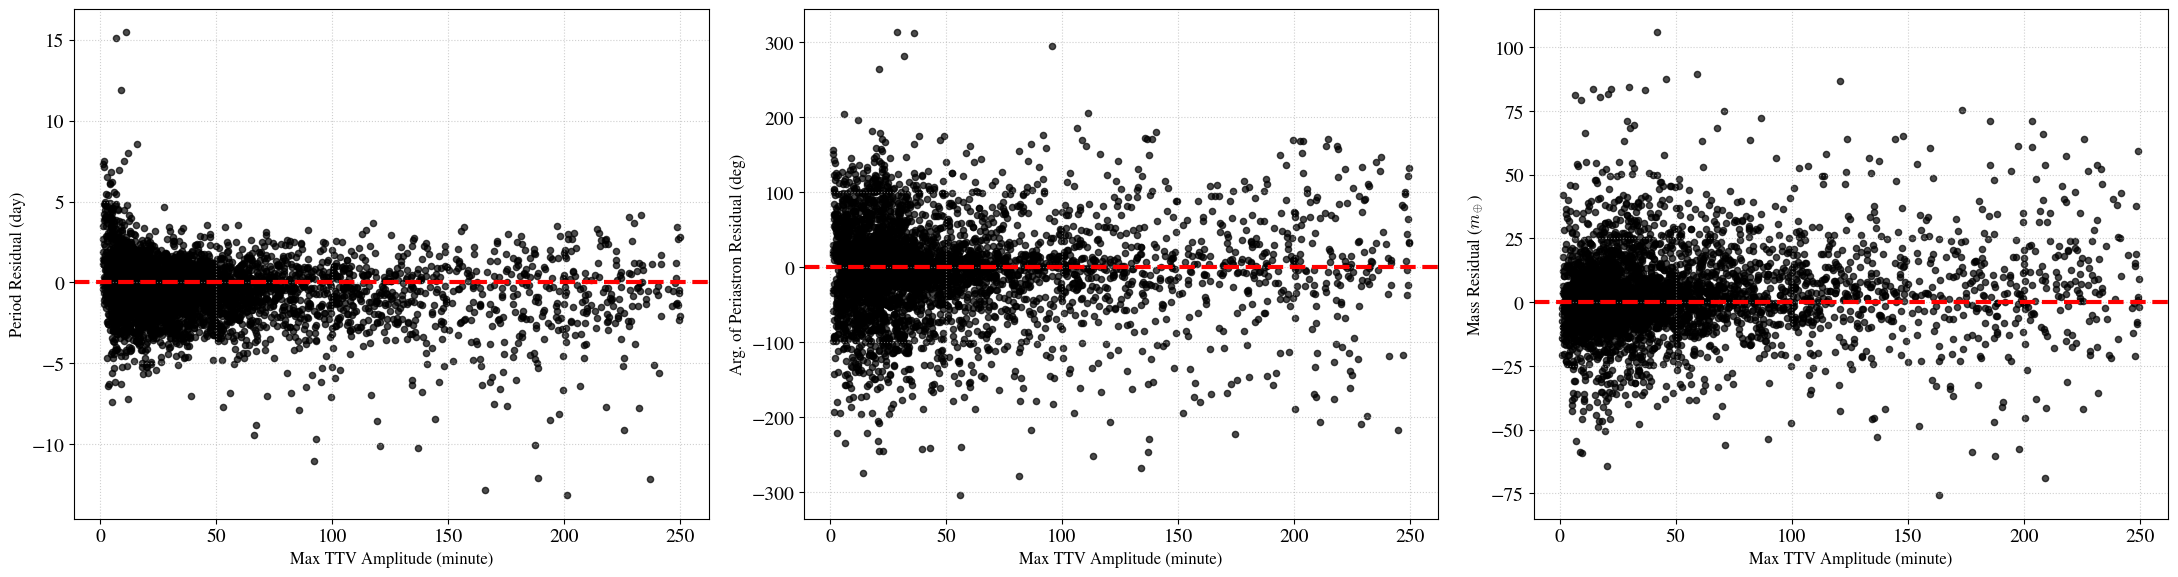

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. DATA PREPARATION ---

# Calculate the Maximum TTV Amplitude (X-axis)
# Assumes ttv_ is a list or array of TTV time series curves.
try:
    max_ttv_amplitude = np.array([np.max(np.abs(curve)) for curve in ttv_])
except Exception as e:
    print(f"Error calculating max_ttv_amplitude: {e}")
    print("Please ensure 'ttv_' is structured as an iterable of TTV time-series (e.g., a 2D array).")
    exit()

# Ensure all arrays are 1D and the same length (N)
N = len(m2_)

# True values
p2_r = p2_.reshape(N)
o2_r = o2_.reshape(N)
m2_r = m2_.reshape(N)

# Predicted values
predicted_period_r = predicted_period.reshape(N)
predicted_argument_perigee_r = predicted_argument_perigee.reshape(N)
predicted_mass_r = predicted_mass.reshape(N)

# Calculate Residuals (Non-Normalized)
period_residual = (p2_r - predicted_period_r)
aop_residual = (o2_r - predicted_argument_perigee_r)
mass_residual = (m2_r - predicted_mass_r)

# --- 2. PLOTTING ---

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.subplots_adjust(wspace=0.3)
cmap = 'viridis'

# --- Plot 1: Period Residual vs. Max TTV Amplitude ---
axes[0].scatter(max_ttv_amplitude, period_residual, s=20,c='k', alpha=0.7)
axes[0].axhline(0, color='r', linestyle='--', linewidth=3)
#axes[0].set_title(r'Period Residual vs. Max TTV Amplitude', fontsize=14)
axes[0].set_xlabel('Max TTV Amplitude (minute)', fontsize=12)
axes[0].set_ylabel('Period Residual (day)', fontsize=12)
axes[0].grid(True, linestyle=':', alpha=0.6)


# --- Plot 2: Argument of Perigee Residual vs. Max TTV Amplitude ---
axes[1].scatter(max_ttv_amplitude, aop_residual, s=20,c='k', alpha=0.7)
axes[1].axhline(0, color='r', linestyle='--', linewidth=3)
#axes[1].set_title(r'Arg. of Perigee Residual vs. Max TTV Amplitude', fontsize=14)
axes[1].set_xlabel('Max TTV Amplitude (minute)', fontsize=12)
axes[1].set_ylabel('Arg. of Periastron Residual (deg)', fontsize=12)
axes[1].grid(True, linestyle=':', alpha=0.6)


# --- Plot 3: Mass Residual vs. Max TTV Amplitude ---
axes[2].scatter(max_ttv_amplitude,  mass_residual, s=20,c='k', alpha=0.7)
axes[2].axhline(0, color='r', linestyle='--', linewidth=3)
#axes[2].set_title(r'Mass Residual vs. Max TTV Amplitude', fontsize=14)
axes[2].set_xlabel('Max TTV Amplitude (minute)', fontsize=12)
axes[2].set_ylabel(r'Mass Residual ($m_\oplus$)', fontsize=12)
axes[2].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('residuals_amplitude.pdf', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

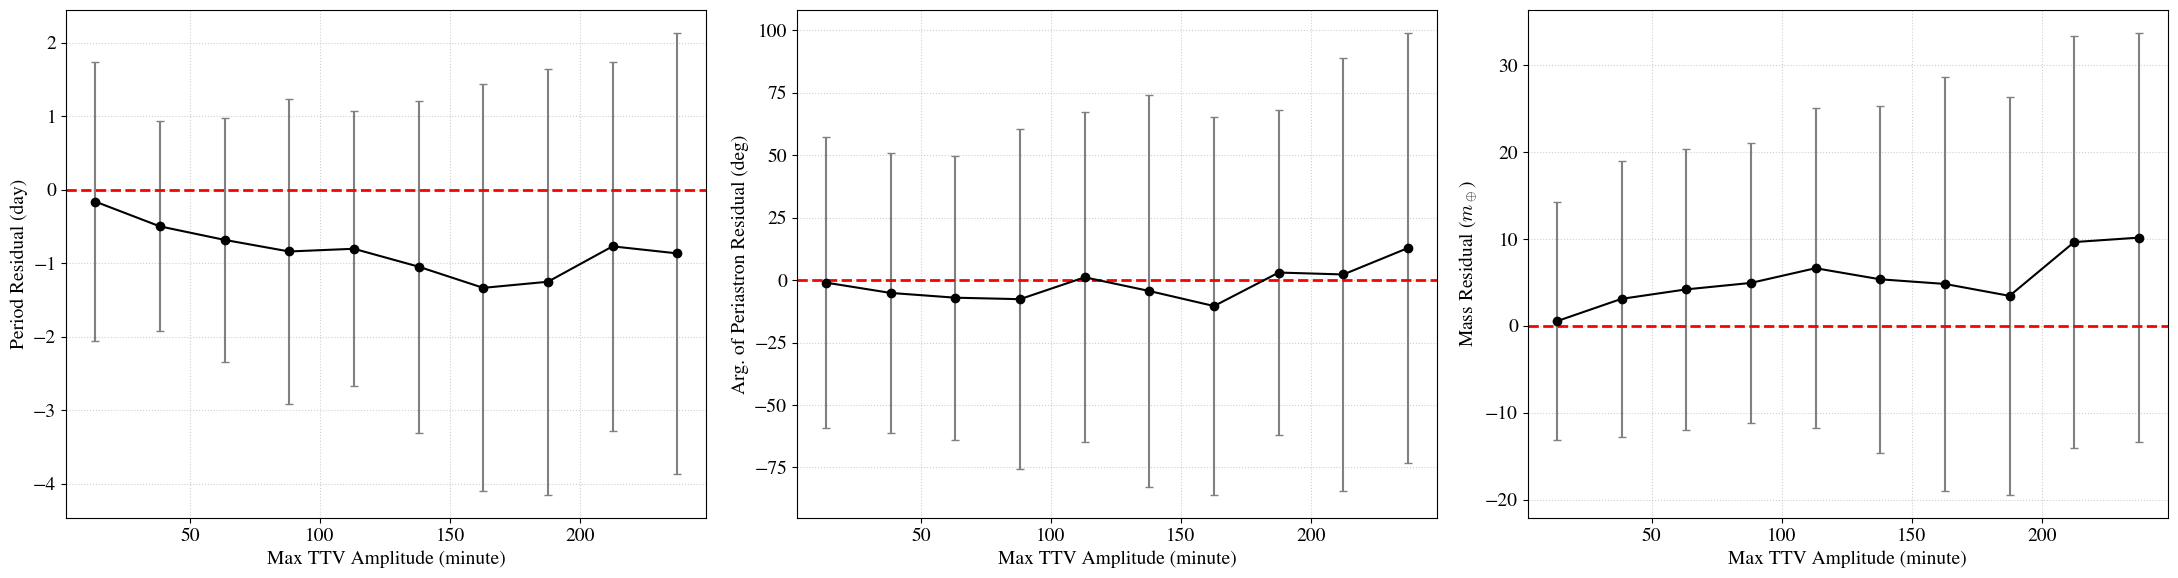

In [ ]:
# --- 2. BINNING AND PLOTTING ---

# Define bins for max TTV amplitude
num_bins = 10
bins = np.linspace(np.min(max_ttv_amplitude), np.max(max_ttv_amplitude), num_bins + 1)
bin_centers = (bins[:-1] + bins[1:]) / 2

def compute_binned_stats(x, residual):
    """Return mean and std of residual within each amplitude bin."""
    indices = np.digitize(x, bins) - 1
    mean_vals = []
    std_vals = []
    for b in range(num_bins):
        mask = indices == b
        if np.sum(mask) > 0:
            mean_vals.append(np.mean(residual[mask]))
            std_vals.append(np.std(residual[mask]))
        else:
            mean_vals.append(np.nan)
            std_vals.append(np.nan)
    return np.array(mean_vals), np.array(std_vals)

# Compute binned averages for period, aop, mass
period_mean, period_std = compute_binned_stats(max_ttv_amplitude, period_residual)
aop_mean, aop_std = compute_binned_stats(max_ttv_amplitude, aop_residual)
mass_mean, mass_std = compute_binned_stats(max_ttv_amplitude, mass_residual)

# --- PLOTS ---
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.subplots_adjust(wspace=0.3)

# Plot 1 — Period
axes[0].errorbar(bin_centers, period_mean, yerr=period_std,
                 fmt='o-', color='k', ecolor='gray', capsize=3)
axes[0].axhline(0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Max TTV Amplitude (minute)')
axes[0].set_ylabel('Period Residual (day)')
axes[0].grid(True, linestyle=':', alpha=0.6)

# Plot 2 — Arg of Periastron
axes[1].errorbar(bin_centers, aop_mean, yerr=aop_std,
                 fmt='o-', color='k', ecolor='gray', capsize=3)
axes[1].axhline(0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Max TTV Amplitude (minute)')
axes[1].set_ylabel('Arg. of Periastron Residual (deg)')
axes[1].grid(True, linestyle=':', alpha=0.6)

# Plot 3 — Mass
axes[2].errorbar(bin_centers, mass_mean, yerr=mass_std,
                 fmt='o-', color='k', ecolor='gray', capsize=3)
axes[2].axhline(0, color='r', linestyle='--', linewidth=2)
axes[2].set_xlabel('Max TTV Amplitude (minute)')
axes[2].set_ylabel('Mass Residual ($m_\\oplus$)')
axes[2].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('residuals_binned.pdf', dpi=600, bbox_inches='tight')
plt.show()


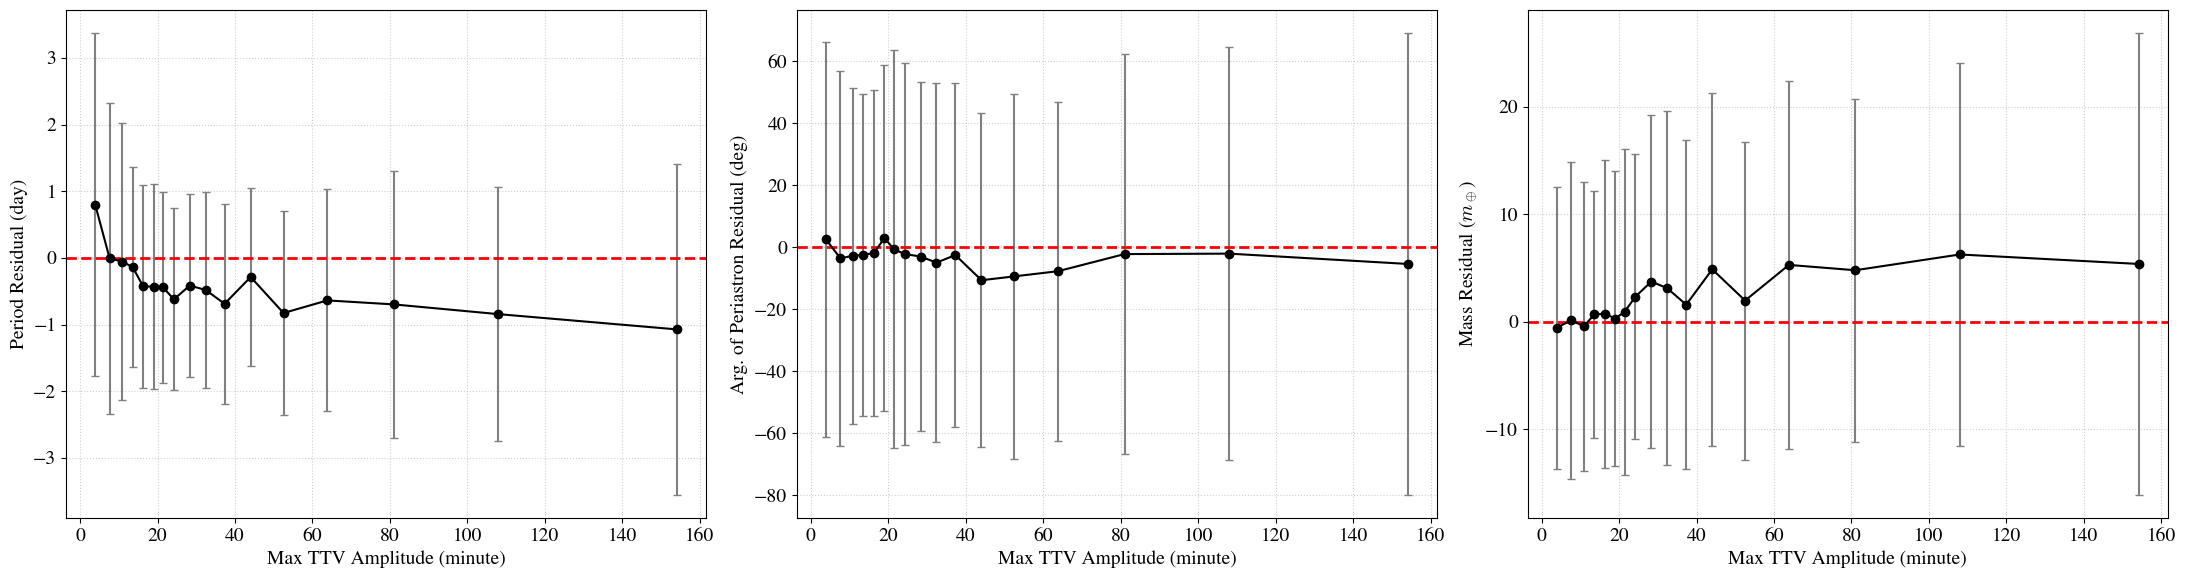

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- SORT BY TTV AMPLITUDE ---
order = np.argsort(max_ttv_amplitude)
amp_sorted = max_ttv_amplitude[order]

period_sorted = period_residual[order]
aop_sorted = aop_residual[order]
mass_sorted = mass_residual[order]

# --- BINNING BASED ON FIXED NUMBER OF DATA ---
points_per_bin = 250   # adjust as needed
num_bins = len(amp_sorted) // points_per_bin

bin_means_amp = []
period_mean = []
period_std = []
aop_mean = []
aop_std = []
mass_mean = []
mass_std = []

for i in range(num_bins):
    start = i * points_per_bin
    end = start + points_per_bin

    amp_bin = amp_sorted[start:end]
    pr_bin = period_sorted[start:end]
    ao_bin = aop_sorted[start:end]
    ms_bin = mass_sorted[start:end]

    bin_means_amp.append(np.mean(amp_bin))

    period_mean.append(np.mean(pr_bin))
    period_std.append(np.std(pr_bin))

    aop_mean.append(np.mean(ao_bin))
    aop_std.append(np.std(ao_bin))

    mass_mean.append(np.mean(ms_bin))
    mass_std.append(np.std(ms_bin))

bin_means_amp = np.array(bin_means_amp)
period_mean = np.array(period_mean)
period_std = np.array(period_std)
aop_mean = np.array(aop_mean)
aop_std = np.array(aop_std)
mass_mean = np.array(mass_mean)
mass_std = np.array(mass_std)

# --- PLOTTING ---
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.subplots_adjust(wspace=0.3)

# Period
axes[0].errorbar(bin_means_amp, period_mean, yerr=period_std,
                 fmt='o-', color='k', ecolor='gray', capsize=3)
axes[0].axhline(0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Max TTV Amplitude (minute)')
axes[0].set_ylabel('Period Residual (day)')
axes[0].grid(True, linestyle=':', alpha=0.6)

# AOP
axes[1].errorbar(bin_means_amp, aop_mean, yerr=aop_std,
                 fmt='o-', color='k', ecolor='gray', capsize=3)
axes[1].axhline(0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Max TTV Amplitude (minute)')
axes[1].set_ylabel('Arg. of Periastron Residual (deg)')
axes[1].grid(True, linestyle=':', alpha=0.6)

# Mass
axes[2].errorbar(bin_means_amp, mass_mean, yerr=mass_std,
                 fmt='o-', color='k', ecolor='gray', capsize=3)
axes[2].axhline(0, color='r', linestyle='--', linewidth=2)
axes[2].set_xlabel('Max TTV Amplitude (minute)')
axes[2].set_ylabel('Mass Residual ($m_\\oplus$)')
axes[2].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig(log_dir+"/residuals_binned_by_count.pdf", dpi=600, bbox_inches='tight')
plt.show()


In [ ]:
plt.hexbin(amplitude, residual, gridsize=50, cmap='inferno')
plt.colorbar(label='Density')

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr

# Circular difference in degrees
def circular_diff(y_true, y_pred):
    # Ensure angles are in degrees
    diff = y_pred - y_true
    return np.arctan2(np.sin(np.radians(diff)), np.cos(np.radians(diff))) * (180 / np.pi)


# Willmott's Index of Agreement
def willmott_d(y_true, y_pred):
    numerator = np.sum((y_pred - y_true) ** 2)
    denominator = np.sum((np.abs(y_pred - np.mean(y_true)) + np.abs(y_true - np.mean(y_true))) ** 2)
    return 1 - (numerator / denominator)

def regression_metrics(y_true, y_pred, label="", is_angle=False):
    # Flatten to 1D arrays
    y_true = np.ravel(y_true)
    y_pred = np.ravel(y_pred)

    # Convert to numeric and drop invalids
    y_true = pd.to_numeric(pd.Series(y_true), errors="coerce")
    y_pred = pd.to_numeric(pd.Series(y_pred), errors="coerce")

    # Remove NaN pairs
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    if is_angle:
        # Use circular difference
        errors = circular_diff(y_true, y_pred)
        mae = np.mean(np.abs(errors))
        rmse = np.sqrt(np.mean(errors ** 2))
        mape = np.nan  # Not meaningful for angles
        bias = np.mean(errors)
    else:
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        bias = np.mean(y_pred - y_true)

    r2 = r2_score(y_true, y_pred)
    pearson_r, _ = pearsonr(y_true, y_pred)
    d = willmott_d(y_true, y_pred)

    return {
        "Parameter": label,
        "R²": r2,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "Bias": bias,
        "Pearson r": pearson_r,
        "Willmott d": d
    }



# Calculate metrics for each parameter

results = []
results.append(regression_metrics(m2_, predicted_mass, "Mass"))
results.append(regression_metrics(p2_, predicted_period, "Period"))
results.append(regression_metrics(o2_, predicted_argument_perigee, "ArgPerigee", is_angle=True))


# Convert to dataframe
df_metrics = pd.DataFrame(results)

# Display in Jupyter notebook output
from IPython.display import display
display(df_metrics.style.format({
    "R²": "{:.3f}",
    "MAE": "{:.3f}",
    "RMSE": "{:.3f}",
    "MAPE (%)": "{:.2f}",
    "Bias": "{:.3f}",
    "Pearson r": "{:.3f}",
    "Willmott d": "{:.3f}"
}).set_caption("Model Performance Metrics"))

# Optionally save to CSV
df_metrics.to_csv(log_dir + "/metrics_" + datatrain_name + model_name + ".csv", index=False)


,Parameter,R²,MAE,RMSE,MAPE (%),Bias,Pearson r,Willmott d
0,Mass,0.855,11.007,16.329,18.77,-2.651,0.927,0.961
1,Period,0.973,1.396,1.949,6.01,0.456,0.987,0.993
2,ArgPerigee,0.665,41.376,57.980,nan,0.433,0.819,0.883


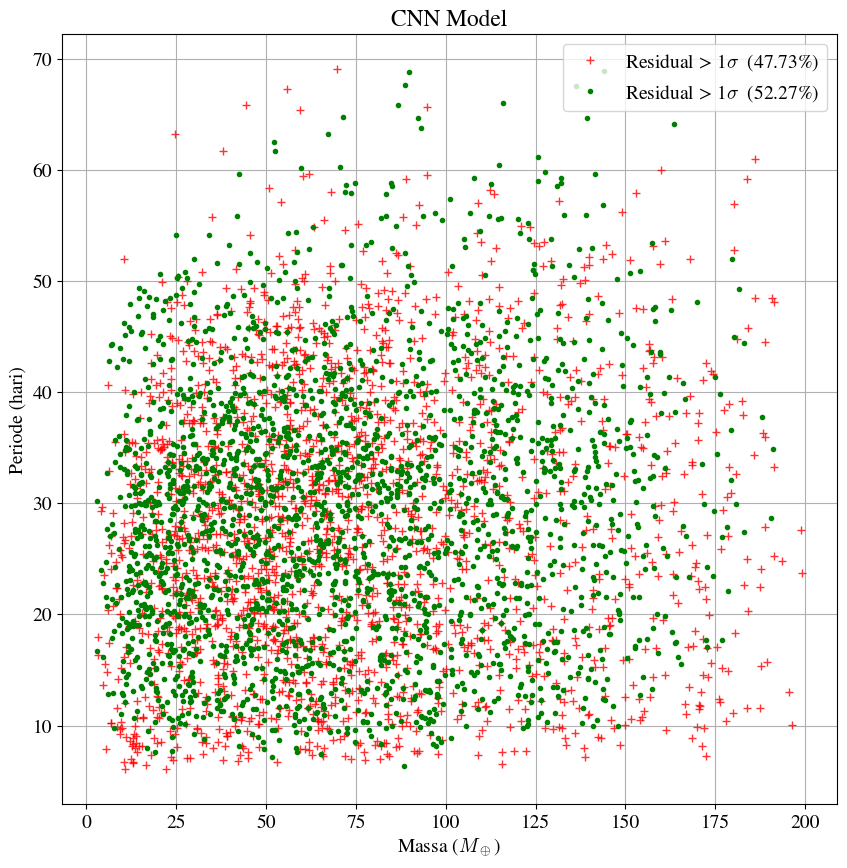

In [ ]:
mask_ = np.ones(len(m2_), dtype=bool)

#print(right_period)
# Set the mask to False at the indices to exclude
mask_[overall] = False

plt.figure(figsize=(10,10))
plt.title('CNN Model')
plt.plot(m2_[mask_],p2_[mask_],'+', alpha=0.8,color='red', label=r'Residual > '+str(n_sigma)+'$\sigma$  ('+str(round(100-overall_acc*100,2))+'%)')
plt.plot(m2_[overall], p2_[overall], '.', color='green', alpha=1, label=r'Residual > '+str(n_sigma)+'$\sigma$  ('+str(round(overall_acc*100,2))+'%)')
plt.grid()
plt.ylabel('Periode (hari)')
plt.xlabel(r'Massa ($M_\oplus$)')
plt.legend()
plt.savefig(log_dir+'/'+"p_vs_m_residual_lstm.pdf", dpi=600, bbox_inches = 'tight')
plt.show()

In [ ]:
print(model_)

<>:42: SyntaxWarning: invalid escape sequence '\c'
<>:42: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipython-input-11728170.py:42: SyntaxWarning: invalid escape sequence '\c'
  axs[2].set_ylabel('Ketidakpastian ($^{\circ}$)')


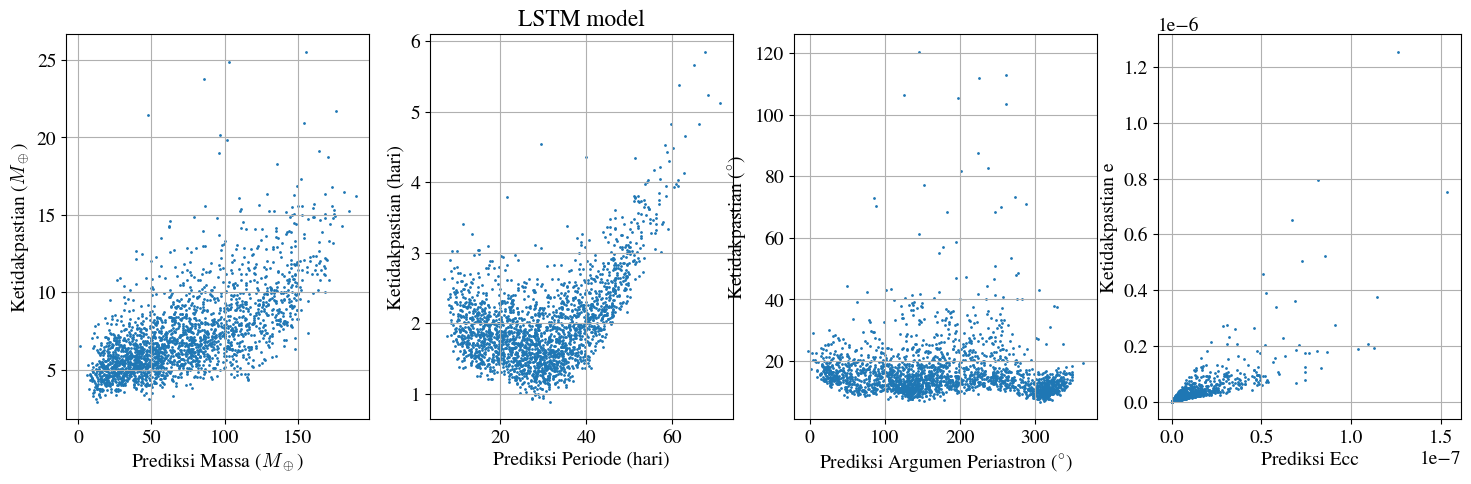

In [ ]:
# #plt.scatter(residual_m, predicted_mass)
# fig,axs = plt.subplots(2,2,figsize=(12,12))

# axs[0].scatter(predicted_mass, unc_m, s=1)
# axs[0].set_ylabel(r'Ketidakpastian ($M_\oplus$)')
# axs[0].set_xlabel(r'Prediksi Massa ($M_\oplus$)')
# axs[0].grid()

# axs[1].scatter(predicted_period, unc_p, s=1)
# axs[1].set_ylabel('Ketidakpastian (hari)')
# axs[1].set_xlabel('Prediksi Periode (hari)')
# axs[1].grid()

# axs[0].scatter(predicted_eccentricity, unc_e, s=1)
# axs[0].set_ylabel('Ketidakpastian')
# axs[0].set_xlabel('Prediksi Eksentrisitas')
# axs[0].grid()

# axs[1].scatter(predicted_argument_perigee, unc_o, s=1)
# axs[1].set_ylabel('Ketidakpastian ($^{\circ}$)')
# axs[1].set_xlabel(r'Prediksi Argumen Periastron ($^{\circ}$)')
# axs[1].grid()

# plt.savefig(log_dir+'/'+"ketidakpastian_prediksi_"+file_path+".png", dpi=600, bbox_inches = 'tight')
# plt.show()

#plt.scatter(residual_m, predicted_mass)
fig,axs = plt.subplots(1,4,figsize=(18,5))

axs[0].scatter(predicted_mass, unc_m, s=1)
axs[0].set_ylabel(r'Ketidakpastian ($M_\oplus$)')
axs[0].set_xlabel(r'Prediksi Massa ($M_\oplus$)')
axs[0].grid()

axs[1].scatter(predicted_period, unc_p, s=1)
axs[1].set_title('LSTM model')
axs[1].set_ylabel('Ketidakpastian (hari)')
axs[1].set_xlabel('Prediksi Periode (hari)')
axs[1].grid()

axs[2].scatter(predicted_argument_perigee, unc_o, s=1)
axs[2].set_ylabel('Ketidakpastian ($^{\circ}$)')
axs[2].set_xlabel(r'Prediksi Argumen Periastron ($^{\circ}$)')
axs[2].grid()

axs[3].scatter(predicted_eccentricity, unc_e, s=1)
axs[3].set_ylabel('Ketidakpastian e')
axs[3].set_xlabel(r'Prediksi Ecc')
axs[3].grid()

#plt.savefig(log_dir+'/'+"ketidakpastian_prediksi_"+file_path+"_LSTM.pdf", dpi=600, bbox_inches = 'tight')
plt.show()

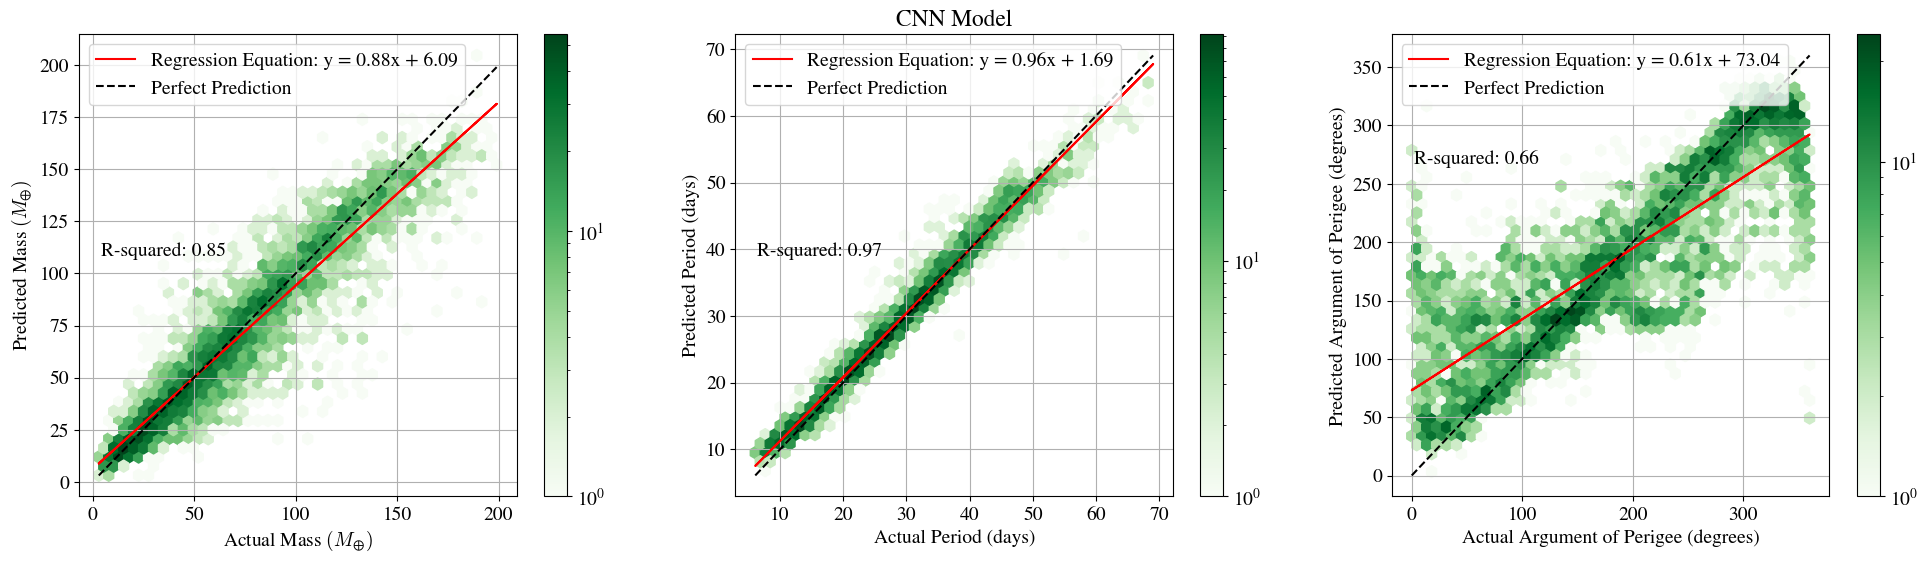

In [ ]:
#Linear regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
def linreg(x,y):
  x = np.array(x).reshape(-1, 1)
  modelLR = LinearRegression()
  modelLR.fit(x,y)
  slope = modelLR.coef_[0]
  intercept = modelLR.intercept_
  y_pred = modelLR.predict(x)
  return slope, intercept, y_pred





fig,axs = plt.subplots(1,3,figsize=(24,6), gridspec_kw={'hspace': 0.2})

m, c, y_pred = linreg(m2_, predicted_mass)

r2 = r2_score(m2_, predicted_mass)
#print("R-squared:", r2)
axs[0].plot(m2_, y_pred, color='red', label=f"Regression Equation: y = {m:.2f}x + {c:.2f}")
#axs[0].scatter(m2_, predicted_mass, s=1)
hb1 = axs[0].hexbin(m2_, predicted_mass.reshape(len(m2_)), gridsize=40, cmap='Greens', mincnt=1, bins='log')
axs[0].set_xlabel(r'Actual Mass $(M_⊕)$')
axs[0].set_ylabel(r'Predicted Mass $(M_⊕)$')
#axs[0].set_title('Actual Mass vs Predicted Mass')
axs[0].plot([min(m2_), max(m2_)], [min(m2_), max(m2_)], 'k--', label='Perfect Prediction')
axs[0].text(0.05, 0.55, f'R-squared: {r2:.2f}', transform=axs[0].transAxes, fontsize=14, verticalalignment='top')
axs[0].legend()
axs[0].grid(True)
cb1 = fig.colorbar(hb1, ax=axs[0])
#cb1.set_label('Log Density')

m, c, y_pred = linreg(p2_, predicted_period)

r2 = r2_score(p2_, predicted_period)
axs[1].set_title('CNN Model')
axs[1].plot(p2_, y_pred, color='red', label=f"Regression Equation: y = {m:.2f}x + {c:.2f}")
#axs[1].scatter(p2_, predicted_period, s=1)
hb2 = axs[1].hexbin(p2_, predicted_period.reshape(len(m2_)), gridsize=40, cmap='Greens', mincnt=1, bins='log')
axs[1].set_xlabel('Actual Period (days)')
axs[1].set_ylabel('Predicted Period (days)')
#axs[1].set_title('Actual Period vs Predicted Period')
axs[1].plot([min(p2_), max(p2_)], [min(p2_), max(p2_)], 'k--', label='Perfect Prediction')
axs[1].text(0.05, 0.55, f'R-squared: {r2:.2f}', transform=axs[1].transAxes, fontsize=14, verticalalignment='top')
axs[1].legend()
axs[1].grid(True)
cb2 = fig.colorbar(hb2, ax=axs[1])
#cb2.set_label('Log Density')

m, c, y_pred = linreg(o2_, predicted_argument_perigee)

r2 = r2_score(o2_, predicted_argument_perigee)
#print("R-squared:", r2
axs[2].plot(o2_, y_pred, color='red', label=f"Regression Equation: y = {m:.2f}x + {c:.2f}")
#[2].scatter(o2_, predicted_argument_perigee, s=1
hb3 = axs[2].hexbin(o2_, predicted_argument_perigee.reshape(len(m2_)), gridsize=40, cmap='Greens', mincnt=1, bins='log')
axs[2].set_xlabel('Actual Argument of Perigee (degrees)')
axs[2].set_ylabel('Predicted Argument of Perigee (degrees)')
#axs[2].set_title('Actual Argument of Perigee vs Predicted Argument of Perigee')
axs[2].plot([min(o2_), max(o2_)], [min(o2_), max(o2_)], 'k--', label='Perfect Prediction')
axs[2].text(0.05, 0.75, f'R-squared: {r2:.2f}', transform=axs[2].transAxes, fontsize=14, verticalalignment='top')
axs[2].legend()
axs[2].grid(True)
cb3 = fig.colorbar(hb3, ax=axs[2])
#cb3.set_label('Log Density')
# m, c, y_pred = linreg(e2_, predicted_eccentricity)

# r2 = r2_score(e2_, predicted_eccentricity)
# #print("R-squared:", r2
# axs[3].plot(e2_, y_pred, color='red', label=f"Regression Equation: y = {m:.2f}x + {c:.2f}")
# #[2].scatter(o2_, predicted_argument_perigee, s=1
# hb3 = axs[3].hexbin(e2_, predicted_eccentricity.reshape(len(m2_)), gridsize=40, cmap='Greens', mincnt=1, bins='log')
# axs[3].set_xlabel('Actual Eccentricity')
# axs[3].set_ylabel('Predicted Eccentricity')
# #axs[2].set_title('Actual Argument of Perigee vs Predicted Argument of Perigee')
# axs[3].plot([min(e2_), max(e2_)], [min(e2_), max(e2_)], 'k--', label='Perfect Prediction')
# axs[3].text(0.05, 0.75, f'R-squared: {r2:.2f}', transform=axs[3].transAxes, fontsize=14, verticalalignment='top')
# axs[3].legend()
# axs[3].grid(True)
# cb3 = fig.colorbar(hb3, ax=axs[3])


plt.savefig(log_dir+'/'+"aktual_predict_omega"+datatrain_name+model_name+"_"+file_path+"CNN.pdf", dpi=300,bbox_inches = 'tight')


In [ ]:
errors=[]
for i in range(len(p2_)):
    errors.append(p2_[i]- predicted_period[i,0])

# plt.axvline(0, color='red', linestyle='--', label="Zero Error")
# plt.xlabel("Prediction Error")
# plt.ylabel("Frequency")
# plt.title("Histogram of Prediction Errors")
# plt.legend()
# plt.grid()
# plt.show()

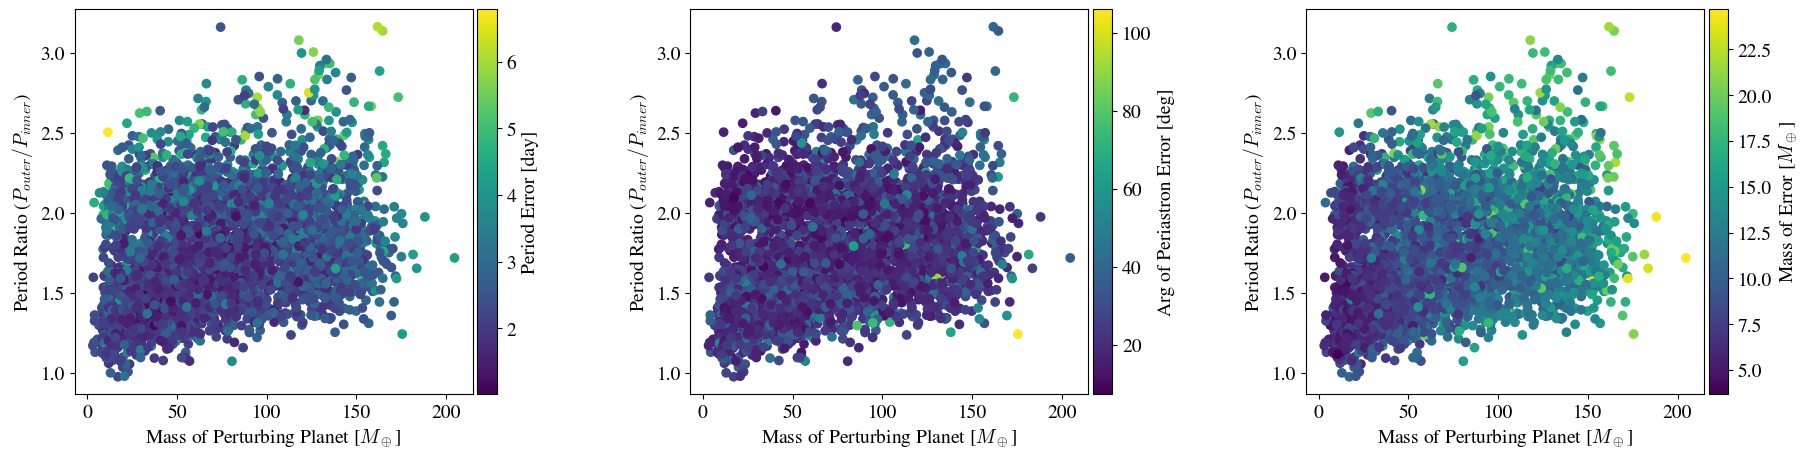

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

# Generate some example data
np.random.seed(42)
mass_outer = predicted_mass  # Mass of of outer planet
period_ratio = predicted_period.reshape(len(m2_))/p1_  # Period ratio
period_error = unc_p  # Period error
mass_error = unc_m  # Mass of error
arg_peri_error = unc_o  # Argument of periastron error

# Create a 2x2 figure
fig, axs = plt.subplots(1, 3, figsize=(22, 5))
fig.subplots_adjust(wspace=0.3)
#fig.suptitle('LSTM Model', fontsize=14)

# Top-left: Period Error vs Period Ratio
sc = axs[0].scatter(mass_outer, period_ratio, c=period_error, cmap='viridis')
#axs[0].set_title('LSTM Model', fontsize=14)
axs[0].set_xlabel(r'Mass of Perturbing Planet [$M_\oplus$]')
axs[0].set_ylabel(r'Period Ratio ($P_{outer} / P_{inner}$)')
fig.colorbar(sc, ax=axs[0], label='Period Error [day]', pad=0.01)

# Top-right: Argument of Periastron Error vs Period Ratio
sc = axs[1].scatter(mass_outer, period_ratio, c=arg_peri_error, cmap='viridis')
axs[1].set_xlabel(r'Mass of Perturbing Planet [$M_\oplus$]')
axs[1].set_ylabel(r'Period Ratio ($P_{outer} / P_{inner}$)')
fig.colorbar(sc, ax=axs[1], label='Arg of Periastron Error [deg]', pad=0.01)

# Bottom-left: Mass of Error vs Period Ratio
sc = axs[2].scatter(mass_outer, period_ratio, c=mass_error, cmap='viridis')
axs[2].set_xlabel(r'Mass of Perturbing Planet [$M_\oplus$]')
axs[2].set_ylabel(r'Period Ratio ($P_{outer} / P_{inner}$)')
fig.colorbar(sc, ax=axs[2], label=r'Mass of Error [$M_\oplus$]', pad=0.01)


# Adjust layout
#plt.tight_layout(rect=[2.96])
plt.savefig(log_dir+'/'+'fig4_cnn.pdf', dpi=300, bbox_inches = 'tight')
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Simulated data (Replace with your actual dataset)
true_mass = m2_  # True values of mass (M⊕)
predicted_mass = predicted_mass.reshape(len(m2_))  # Predicted values with noise
uncertainties_mass = np.array(unc_m).reshape(len(m2_))  # Standard deviation (σ) for each prediction

# Compute residuals and normalized residuals
residuals_mass = true_mass - predicted_mass
normalized_residuals_mass = residuals_mass / uncertainties_mass

# Create a 2D hexbin plot (heatmap)
plt.figure(figsize=(8, 6))
hb = plt.hexbin(true_mass, normalized_residuals_mass, gridsize=50, cmap='viridis', bins='log',mincnt=0)

# Color bar
cb = plt.colorbar(hb)
cb.set_label('Log Density')

# Labels and title
plt.xlabel(r'Planet Mass $(M_\oplus)$')
plt.ylabel('Normalized Residual')
#plt.title('Heatmap of Normalized Residuals vs. Planet Mass')
plt.axhline(0, color='black', linestyle='dashed')  # Reference line at zero residual
plt.axhline(1, color='red', linestyle='dashed', label='+1σ')
plt.axhline(-1, color='red', linestyle='dashed', label='-1σ')
plt.axhline(2, color='orange', linestyle='dashed', label='+2σ')
plt.axhline(-2, color='orange', linestyle='dashed', label='-2σ')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig(log_dir+'/'+'heatmap_mass_residual_LSTM.pdf', dpi=600,  bbox_inches = 'tight')
# Show plot
plt.show()


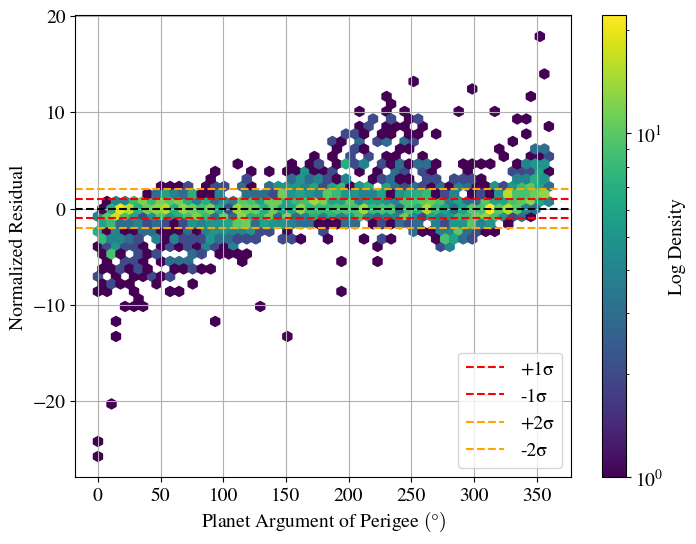

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Simulated data (Replace with your actual dataset)
true_omega = o2_  # True values of mass (M⊕)
predicted_omega = predicted_argument_perigee.reshape(len(m2_))  # Predicted values with noise
uncertainties_omega = np.array(unc_o).reshape(len(m2_))  # Standard deviation (σ) for each prediction

# Compute residuals and normalized residuals
residuals_omega = true_omega - predicted_omega
normalized_residuals_omega = residuals_omega / uncertainties_omega

# Create a 2D hexbin plot (heatmap)
plt.figure(figsize=(8, 6))
hb = plt.hexbin(true_omega, normalized_residuals_omega, gridsize=50, cmap='viridis', bins='log')

# Color bar
cb = plt.colorbar(hb)
cb.set_label('Log Density')

# Labels and title
plt.xlabel(r'Planet Argument of Perigee $(\degree)$')
plt.ylabel('Normalized Residual')
#plt.title('Heatmap of Normalized Residuals vs. Planet Mass')
plt.axhline(0, color='black', linestyle='dashed')  # Reference line at zero residual
plt.axhline(1, color='red', linestyle='dashed', label='+1σ')
plt.axhline(-1, color='red', linestyle='dashed', label='-1σ')
plt.axhline(2, color='orange', linestyle='dashed', label='+2σ')
plt.axhline(-2, color='orange', linestyle='dashed', label='-2σ')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig(log_dir+'/'+'heatmap_omega_residual_LSTM.pdf', dpi=600,  bbox_inches = 'tight')
# Show plot
# Show plot
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Simulated data (Replace with your actual dataset)
true_omega = p2_  # True values of mass (M⊕)
predicted_omega = predicted_period.reshape(len(m2_))  # Predicted values with noise
uncertainties_omega = np.array(unc_p).reshape(len(m2_))  # Standard deviation (σ) for each prediction

# Compute residuals and normalized residuals
residuals_omega = true_omega - predicted_omega
normalized_residuals_omega = residuals_omega / uncertainties_omega

# Create a 2D hexbin plot (heatmap)
plt.figure(figsize=(8, 6))
hb = plt.hexbin(true_omega, normalized_residuals_omega, gridsize=50, cmap='viridis', bins='log')

# Color bar
cb = plt.colorbar(hb)
cb.set_label('Log Density')

# Labels and title
plt.xlabel(r'Planet Argument of Perigee $(\degree)$')
plt.ylabel('Normalized Residual')
#plt.title('Heatmap of Normalized Residuals vs. Planet Mass')
plt.axhline(0, color='black', linestyle='dashed')  # Reference line at zero residual
plt.axhline(1, color='red', linestyle='dashed', label='+1σ')
plt.axhline(-1, color='red', linestyle='dashed', label='-1σ')
plt.axhline(2, color='orange', linestyle='dashed', label='+2σ')
plt.axhline(-2, color='orange', linestyle='dashed', label='-2σ')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig(log_dir+'/'+'heatmap_period_residual_LSTM.pdf', dpi=600,  bbox_inches = 'tight')
# Show plot
# Show plot
plt.show()


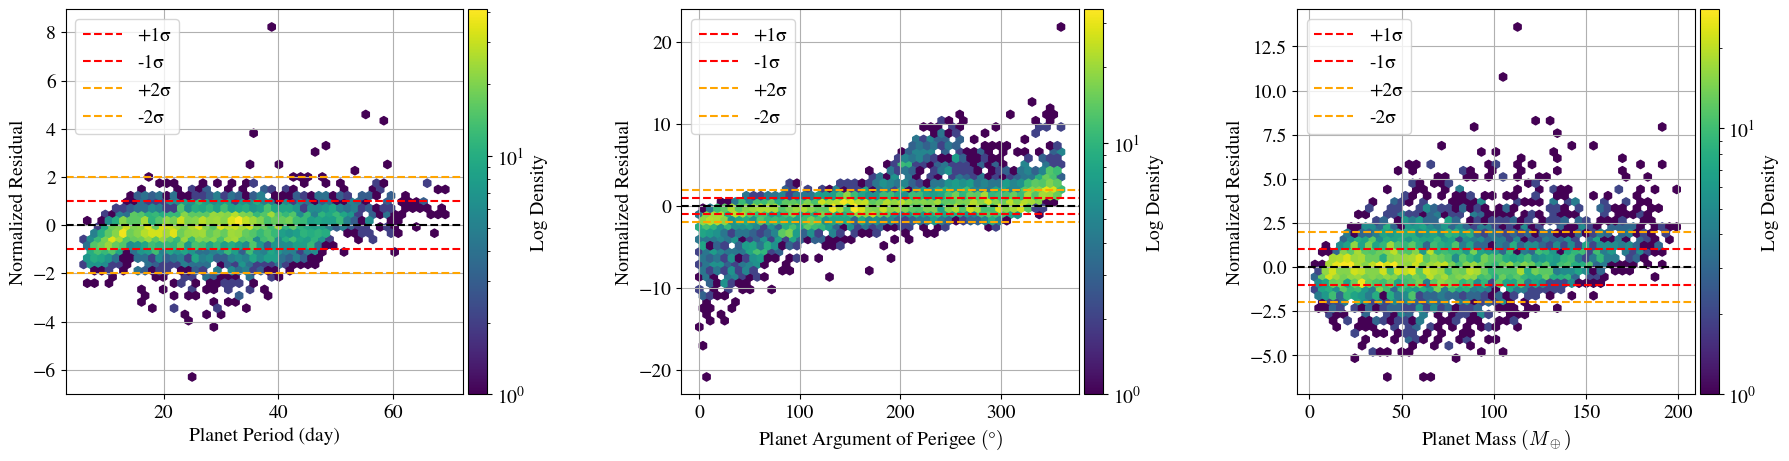

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(22, 5))
fig.subplots_adjust(wspace=0.3)

# First plot: Period residuals
hb1 = axes[0].hexbin(p2_, (p2_ - predicted_period.reshape(len(m2_))) / np.array(unc_p).reshape(len(m2_)),
                      gridsize=50, cmap='viridis', bins='log')


axes[0].set_xlabel(r'Planet Period (day)')
axes[0].set_ylabel('Normalized Residual')
#axes[0].set_title('LSTM Model', fontsize=14)
axes[0].axhline(0, color='black', linestyle='dashed')
axes[0].axhline(1, color='red', linestyle='dashed', label='+1σ')
axes[0].axhline(-1, color='red', linestyle='dashed', label='-1σ')
axes[0].axhline(2, color='orange', linestyle='dashed', label='+2σ')
axes[0].axhline(-2, color='orange', linestyle='dashed', label='-2σ')
axes[0].legend(loc='upper left')
axes[0].grid(True)
fig.colorbar(hb1, ax=axes[0], orientation='vertical',label='Log Density', pad=0.01)
# Second plot: Argument of Perigee residuals
hb2 = axes[1].hexbin(o2_, (o2_ - predicted_argument_perigee.reshape(len(m2_))) / np.array(unc_o).reshape(len(m2_)),
                      gridsize=50, cmap='viridis', bins='log')
axes[1].set_xlabel(r'Planet Argument of Perigee $(\degree)$')
axes[1].set_ylabel('Normalized Residual')
axes[1].axhline(0, color='black', linestyle='dashed')
axes[1].axhline(1, color='red', linestyle='dashed', label='+1σ')
axes[1].axhline(-1, color='red', linestyle='dashed', label='-1σ')
axes[1].axhline(2, color='orange', linestyle='dashed', label='+2σ')
axes[1].axhline(-2, color='orange', linestyle='dashed', label='-2σ')
axes[1].legend(loc='upper left')
axes[1].grid(True)
fig.colorbar(hb2, ax=axes[1], orientation='vertical', label='Log Density', pad=0.01)
# Third plot: Mass residuals
hb3 = axes[2].hexbin(m2_, (m2_ - predicted_mass.reshape(len(m2_))) / np.array(unc_m).reshape(len(m2_)),
                      gridsize=50, cmap='viridis', bins='log')
axes[2].set_xlabel(r'Planet Mass $(M_\oplus)$')
axes[2].set_ylabel('Normalized Residual')
axes[2].axhline(0, color='black', linestyle='dashed')
axes[2].axhline(1, color='red', linestyle='dashed', label='+1σ')
axes[2].axhline(-1, color='red', linestyle='dashed', label='-1σ')
axes[2].axhline(2, color='orange', linestyle='dashed', label='+2σ')
axes[2].axhline(-2, color='orange', linestyle='dashed', label='-2σ')
axes[2].legend(loc='upper left')
axes[2].grid(True)

# Adjust layout and add colorbar
fig.colorbar(hb3, ax=axes[2], orientation='vertical', label='Log Density', pad=0.01)
#plt.tight_layout()
plt.savefig(log_dir + '/' + 'combined_heatmap_residuals_CNN.pdf', dpi=600, bbox_inches='tight')
plt.show()


In [ ]:
raise Exception("Stopping execution here.")

# Any code below this will not run.
print("This will not run.")

In [ ]:
#plt.scatter(residual_p, predicted_period)
plt.figure(figsize=(10,8))
plt.scatter(predicted_period, unc_p,s=1)
plt.ylabel('Ketidakpastian')
plt.xlabel('Prediksi Periode')
plt.grid()


In [ ]:
#plt.scatter(residual_m, predicted_mass)
plt.figure(figsize=(10,8))
plt.scatter(predicted_argument_perigee, unc_o, s=1)
plt.ylabel('Ketidakpastian')
plt.xlabel('AoP Prediksi')
plt.grid()

In [ ]:
#plt.scatter(residual_m, predicted_mass)
plt.figure(figsize=(10,8))
plt.scatter(predicted_eccentricity, unc_e, s=1)
plt.ylabel('Ketidakpastian')
plt.xlabel('Eksentrisitas Prediksi')
plt.grid()

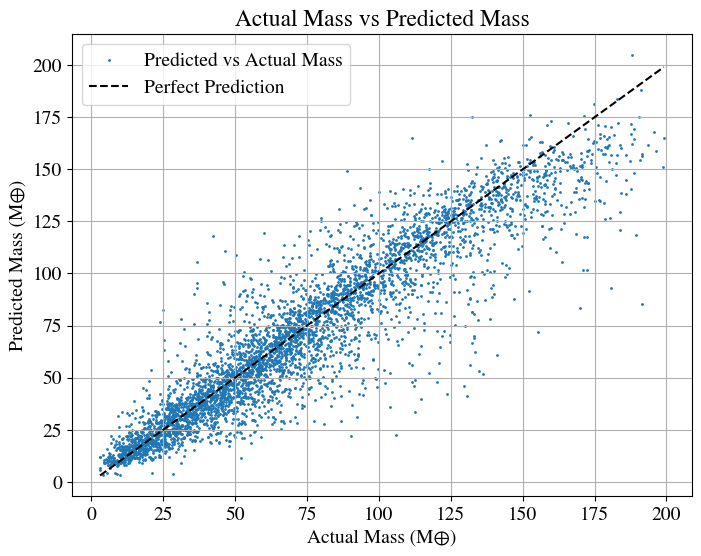

In [ ]:
# prompt: make plot actual mass vs predicted mass

plt.figure(figsize=(8, 6))
plt.scatter(m2_, predicted_mass, label='Predicted vs Actual Mass', s=1)
plt.xlabel('Actual Mass (M⊕)')
plt.ylabel('Predicted Mass (M⊕)')
plt.title('Actual Mass vs Predicted Mass')
plt.plot([min(m2_), max(m2_)], [min(m2_), max(m2_)], 'k--', label='Perfect Prediction')
plt.legend()
plt.grid(True)
plt.show()


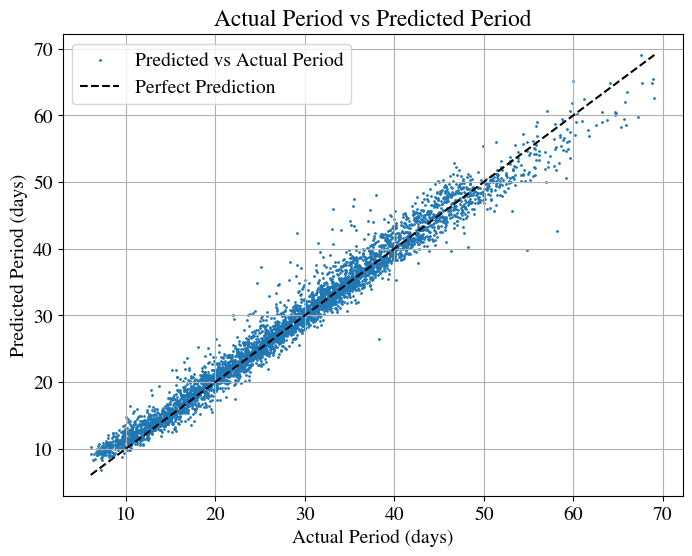

In [ ]:
# prompt: make plot actual period vs predicted period

plt.figure(figsize=(8, 6))
plt.scatter(p2_, predicted_period, label='Predicted vs Actual Period', s=1)
plt.xlabel('Actual Period (days)')
plt.ylabel('Predicted Period (days)')
plt.title('Actual Period vs Predicted Period')
plt.plot([min(p2_), max(p2_)], [min(p2_), max(p2_)], 'k--', label='Perfect Prediction')
plt.legend()
plt.grid(True)
plt.show()

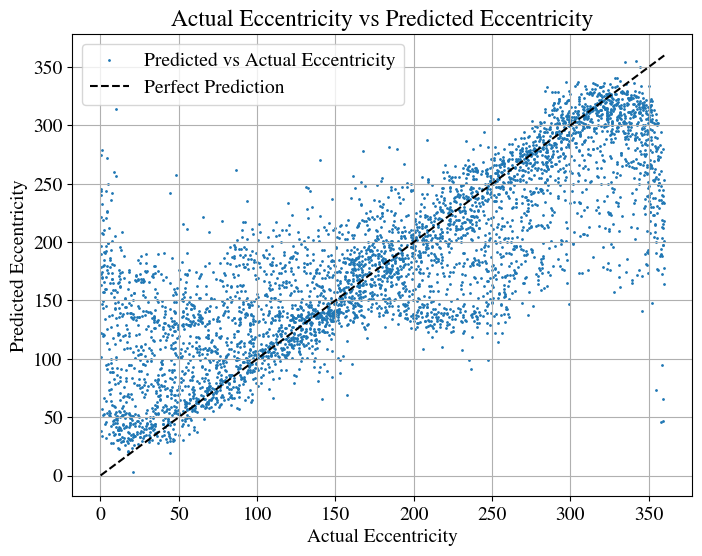

In [ ]:
# prompt: make plot actual eccentricity vs predicted eccentricity

plt.figure(figsize=(8, 6))
plt.scatter(o2_, predicted_argument_perigee, label='Predicted vs Actual Eccentricity', s=1)
#plt.axhline(y=np.average(e2_))
plt.xlabel('Actual Eccentricity')
plt.ylabel('Predicted Eccentricity')
plt.title('Actual Eccentricity vs Predicted Eccentricity')
plt.plot([min(o2_), max(o2_)], [min(o2_), max(o2_)], 'k--', label='Perfect Prediction')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# prompt: make a linear regression of o2_

import numpy as np
from sklearn.linear_model import LinearRegression

# Assuming o2_ is your target variable and you have another variable, say x, as your predictor.
# Replace 'x' with your actual predictor variable.
y = (predicted_argument_perigee)  # Reshape to a 2D array
x = np.array(o2_).reshape(-1, 1)

# Create a linear regression modelLR
modelLR = LinearRegression()

# Fit the modelLR to the data
modelLR.fit(x, y)

# Get the slope and intercept of the regression line
slope = modelLR.coef_[0]
intercept = modelLR.intercept_

# Print the equation of the line
# Access the first element of the slope and intercept arrays
print(f"Linear Regression Equation: y = {slope[0]:.2f}x + {intercept[0]:.2f}")

# Make predictions
y_pred = modelLR.predict(x)

# You can now plot the data and the regression line
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
#plt.scatter(x, y, label='Data')
plt.plot(x, y_pred, color='red', label='Regression Line')
# plt.xlabel('p2_')
# plt.ylabel('o2_')
# plt.legend()
# plt.show()

# prompt: make plot actual argument of perigee vs predicted argument of perigee

plt.scatter(o2_, predicted_argument_perigee, label='Predicted vs Actual Argument of Perigee', s=1)
#plt.axhline(y=np.average(o2_))
plt.xlabel('Actual Argument of Perigee (degrees)')
plt.ylabel('Predicted Argument of Perigee (degrees)')
plt.title('Actual Argument of Perigee vs Predicted Argument of Perigee')
plt.plot([min(o2_), max(o2_)], [min(o2_), max(o2_)], 'k--', label='Perfect Prediction')
plt.legend()
plt.grid(True)
plt.show()

IndexError: invalid index to scalar variable.

In [ ]:
#plt.hist(predicted_argument_perigee)
plt.scatter(o2_, predicted_argument_perigee, label='Predicted vs Actual Argument of Perigee', s=1)

In [ ]:
model_


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Example data
true_values = np.array([1, 2, 2, 3, 3, 4, 4, 5, 6, 7])  # True values
predicted_values = np.array([1, 2, 3, 2, 4, 5, 5, 7, 6, 6])  # Predicted values

# Define bins
bins = [0, 2, 4, 6, 8]  # Adjust these ranges according to your data
bin_labels = ['0-2', '2-4', '4-6', '6-8']  # Labels for bins

# Assign values to bins
true_bins = pd.cut(true_values, bins=bins, labels=bin_labels, right=False)
pred_bins = pd.cut(predicted_values, bins=bins, labels=bin_labels, right=False)

# Create confusion matrix
confusion_matrix = pd.crosstab(true_bins, pred_bins, rownames=['True'], colnames=['Predicted'], margins=True)

# Display the confusion matrix
print(confusion_matrix)

# Optionally, visualize the confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(confusion_matrix.values[:-1, :-1], interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Regression')
plt.colorbar()
plt.xticks(np.arange(len(bin_labels)), bin_labels, rotation=45)
plt.yticks(np.arange(len(bin_labels)), bin_labels)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

#MISSING VALUE

In [ ]:
def run_prediction_with_missing_for_one_system(
        Terr, ms, p1, m1,
        saved_model, predict_fn,
        scaler_ttv, scaler_star_mass,
        scaler_transiting_period, scaler_transiting_mass,
        scaler_mass_output, scaler_period_output,
        scaler_eccentricity_output, scaler_argument_perigee_output,
        missing_fractions
    ):
    results = []

    for frac in missing_fractions:

        corrupted_ttv = remove_points_and_interpolate(Terr, frac)

        # reshape
        new_ttv_data = corrupted_ttv.reshape((1, 50, 1))
        n_timesteps = new_ttv_data.shape[1]
        new_ttv_data = new_ttv_data.reshape((1, n_timesteps, 1))

        # metadata
        new_star_mass = np.array(ms).reshape((1, 1))
        new_transiting_period = np.array(p1).reshape((1, 1))
        new_transiting_mass = np.array(m1).reshape((1, 1))

        # Normalize
        new_ttv_data = scaler_ttv.transform(new_ttv_data.reshape(-1, 1)).reshape(new_ttv_data.shape)
        new_star_mass = scaler_star_mass.transform(new_star_mass)
        new_transiting_period = scaler_transiting_period.transform(new_transiting_period)
        new_transiting_mass = scaler_transiting_mass.transform(new_transiting_mass)

        # Combine
        new_X_inputs = [new_ttv_data, new_star_mass, new_transiting_period, new_transiting_mass]

        # MC dropout
        n_iter = 100
        raw_results = [predict_fn(new_X_inputs, training=True) for _ in range(n_iter)]

        # Collect outputs
        raw_mass = np.array([r[0].numpy() for r in raw_results]).reshape(n_iter, 1)
        raw_period = np.array([r[1].numpy() for r in raw_results]).reshape(n_iter, 1)
        raw_ecc = np.array([r[2].numpy() for r in raw_results]).reshape(n_iter, 1)
        raw_omega = np.array([r[3].numpy() for r in raw_results]).reshape(n_iter, 1)

        # Inverse transform
        real_mass = scaler_mass_output.inverse_transform(raw_mass)
        real_period = scaler_period_output.inverse_transform(raw_period)
        real_ecc = scaler_eccentricity_output.inverse_transform(raw_ecc)
        real_omega = scaler_argument_perigee_output.inverse_transform(raw_omega)

        # Means + std
        predicted_mass = np.mean(real_mass)
        mass_unc = np.std(real_mass)

        predicted_period = np.mean(real_period)
        period_unc = np.std(real_period)

        predicted_ecc = np.mean(real_ecc)
        ecc_unc = np.std(real_ecc)

        predicted_omega = np.mean(real_omega)
        omega_unc = np.std(real_omega)

        results.append({
            "missing_fraction": frac,
            "Mass_Pred": predicted_mass,
            "Mass_Unc": mass_unc,
            "Period_Pred": predicted_period,
            "Period_Unc": period_unc,
            "Ecc_Pred": predicted_ecc,
            "Ecc_Unc": ecc_unc,
            "Omega_Pred": predicted_omega,
            "Omega_Unc": omega_unc,
        })

    return pd.DataFrame(results)


In [ ]:
saved_model

<Functional name=functional, built=True>

In [ ]:
missing_fractions = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]

all_system_results = []

Nsys = len(ttv_)
Nsys = 100

for i in range(Nsys):
    print(f"System {i+1}/{Nsys}")

    df_sys = run_prediction_with_missing_for_one_system(
        Terr = ttv_[i],
        ms   = ms_[i],
        p1   = p1_[i],
        m1   = m1_[i],
        saved_model = saved_model,
        predict_fn = predict_fn,
        scaler_ttv = scaler_ttv,
        scaler_star_mass = scaler_star_mass,
        scaler_transiting_period = scaler_transiting_period,
        scaler_transiting_mass = scaler_transiting_mass,
        scaler_mass_output = scaler_mass_output,
        scaler_period_output = scaler_period_output,
        scaler_eccentricity_output = scaler_eccentricity_output,
        scaler_argument_perigee_output = scaler_argument_perigee_output,
        missing_fractions = missing_fractions
    )

    df_sys["system_id"] = i
    df_sys["Mass_True"] = m2_[i]
    df_sys["Period_True"] = p2_[i]
    df_sys["Ecc_True"] = e2_[i]
    df_sys["Omega_True"] = o2_[i]

    all_system_results.append(df_sys)

df_all = pd.concat(all_system_results, ignore_index=True)


System 1/100
System 2/100
System 3/100
System 4/100
System 5/100
System 6/100
System 7/100
System 8/100
System 9/100
System 10/100
System 11/100
System 12/100
System 13/100
System 14/100
System 15/100
System 16/100
System 17/100
System 18/100
System 19/100
System 20/100
System 21/100
System 22/100
System 23/100
System 24/100
System 25/100
System 26/100
System 27/100
System 28/100
System 29/100
System 30/100
System 31/100
System 32/100
System 33/100
System 34/100
System 35/100
System 36/100
System 37/100
System 38/100
System 39/100
System 40/100
System 41/100
System 42/100
System 43/100
System 44/100
System 45/100
System 46/100
System 47/100
System 48/100
System 49/100
System 50/100
System 51/100
System 52/100
System 53/100
System 54/100
System 55/100
System 56/100
System 57/100
System 58/100
System 59/100
System 60/100
System 61/100
System 62/100
System 63/100
System 64/100
System 65/100
System 66/100
System 67/100
System 68/100
System 69/100
System 70/100
System 71/100
System 72/100
S

In [ ]:
df_all

,missing_fraction,Mass_Pred,Mass_Unc,Period_Pred,Period_Unc,Ecc_Pred,Ecc_Unc,Omega_Pred,Omega_Unc,system_id,Mass_True,Period_True,Ecc_True,Omega_True
0,0.0,65.985954,8.462672,17.074314,1.796053,2.541860e-10,3.964932e-10,167.335373,23.007193,0,48.823226,17.053276,0.000485,254.977553
1,0.1,59.531063,6.394184,17.292337,1.708844,8.758034e-10,1.661191e-09,153.798935,18.912067,0,48.823226,17.053276,0.000485,254.977553
2,0.2,58.986118,7.358744,16.844685,1.979545,1.049005e-09,2.190787e-09,153.559616,17.527565,0,48.823226,17.053276,0.000485,254.977553
3,0.3,61.313553,6.867916,17.420094,1.750557,1.353181e-09,5.258911e-09,157.061905,18.001831,0,48.823226,17.053276,0.000485,254.977553
4,0.4,51.510181,5.806039,18.569775,1.919344,3.799498e-09,8.903613e-09,139.920532,10.947640,0,48.823226,17.053276,0.000485,254.977553
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,0.1,24.133257,6.847323,11.371344,2.272112,6.586433e-10,2.363848e-09,301.430756,20.381241,99,12.197940,8.659502,0.000839,61.087937
596,0.2,17.443623,5.191779,10.509049,2.068731,1.554463e-10,5.189651e-10,69.321022,13.351615,99,12.197940,8.659502,0.000839,61.087937
597,0.3,23.954248,6.706727,9.596827,2.644855,2.553597e-09,1.601056e-08,286.022644,18.072369,99,12.197940,8.659502,0.000839,61.087937
598,0.4,45.272839,7.546317,12.182706,2.382197,7.515678e-09,5.049889e-08,347.251801,17.487728,99,12.197940,8.659502,0.000839,61.087937


In [ ]:
df_all["Mass_resid"] = df_all["Mass_Pred"] - df_all["Mass_True"]
df_all["Period_resid"] = df_all["Period_Pred"] - df_all["Period_True"]
df_all["Ecc_resid"] = df_all["Ecc_Pred"] - df_all["Ecc_True"]
df_all["Omega_resid"] = df_all["Omega_Pred"] - df_all["Omega_True"]
df_avg = df_all.groupby("missing_fraction").mean(numeric_only=True).reset_index()

In [ ]:
df_avg = df_all.groupby("missing_fraction").mean(numeric_only=True)
df_std = df_all.groupby("missing_fraction").std(numeric_only=True)
df_avg = df_avg.reset_index()
df_std = df_std.reset_index()


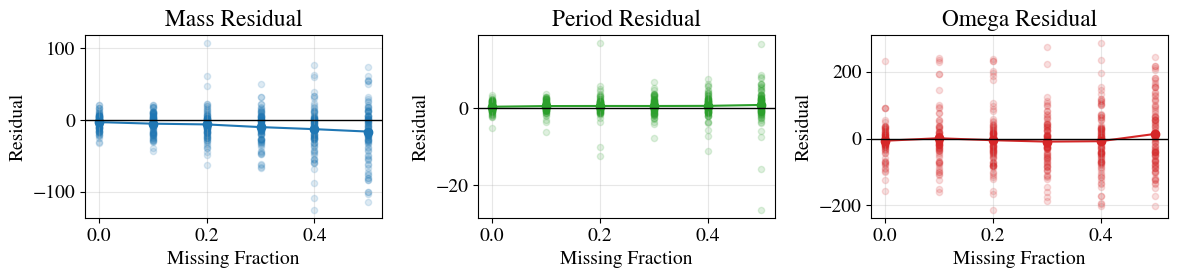

In [ ]:
import matplotlib.pyplot as plt

# Parameters to plot
params = ["Mass_resid", "Period_resid", "Omega_resid"]
labels = ["Mass", "Period", "Omega"]
colors = ["tab:blue", "tab:green", "tab:red"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharex=True)

for ax, param, label, color in zip(axes, params, labels, colors):

    # Scatter all systems (faint)
    for mf in df_all["missing_fraction"].unique():
        df_tmp = df_all[df_all["missing_fraction"] == mf]
        ax.scatter(df_tmp["missing_fraction"], df_tmp[param],
                   color=color, alpha=0.15, s=20)

    # Averaged line
    ax.plot(df_avg["missing_fraction"], df_avg[param],
            "-o", color=color, label=f"{label} avg")

    ax.axhline(0, color="black", lw=1)
    ax.set_title(f"{label} Residual")
    ax.set_xlabel("Missing Fraction")
    ax.set_ylabel("Residual")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


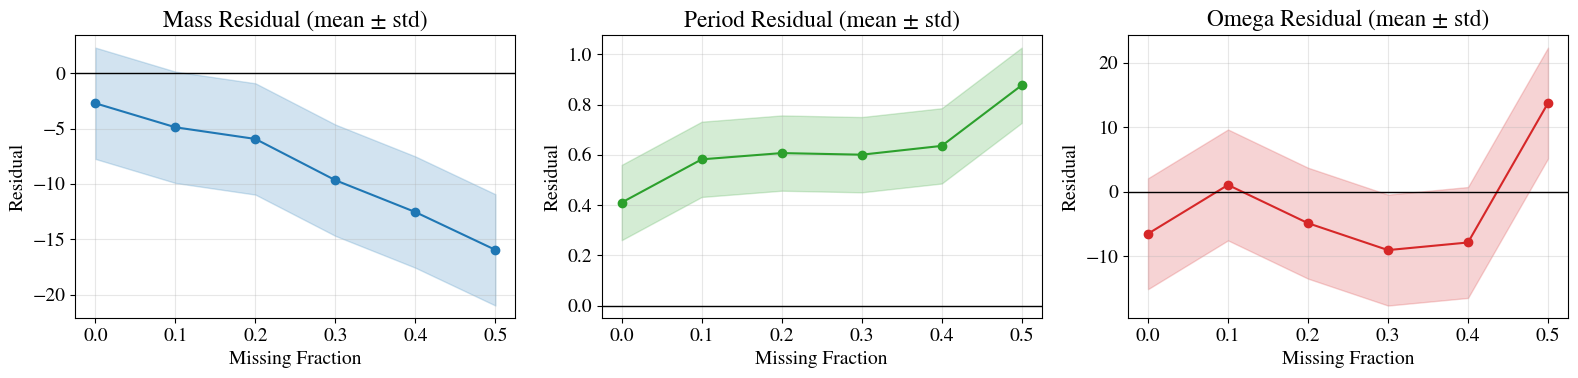

In [ ]:
import matplotlib.pyplot as plt

# Parameters to plot
params = ["Mass_resid", "Period_resid", "Omega_resid"]
labels = ["Mass", "Period", "Omega"]
colors = ["tab:blue", "tab:green", "tab:red"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)

for ax, param, label, color in zip(axes, params, labels, colors):

    # Extract mean and std (already computed in df_avg)
    mean_vals = df_avg[param]
    std_vals = df_avg[param.replace("_resid", "_resid")]  # keep structure

    # Plot mean line
    ax.plot(df_avg["missing_fraction"], mean_vals,
            "-o", color=color, label=f"{label} mean")

    # Shaded ±1σ region
    ax.fill_between(df_avg["missing_fraction"],
                    mean_vals - df_avg[param.replace("_resid", "_resid")].std(),
                    mean_vals + df_avg[param.replace("_resid", "_resid")].std(),
                    color=color, alpha=0.2)

    ax.axhline(0, color="black", lw=1)
    ax.set_title(f"{label} Residual (mean ± std)")
    ax.set_xlabel("Missing Fraction")
    ax.set_ylabel("Residual")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('residual_plot.pdf', dpi=300, bbox_inches='tight')
plt.show()


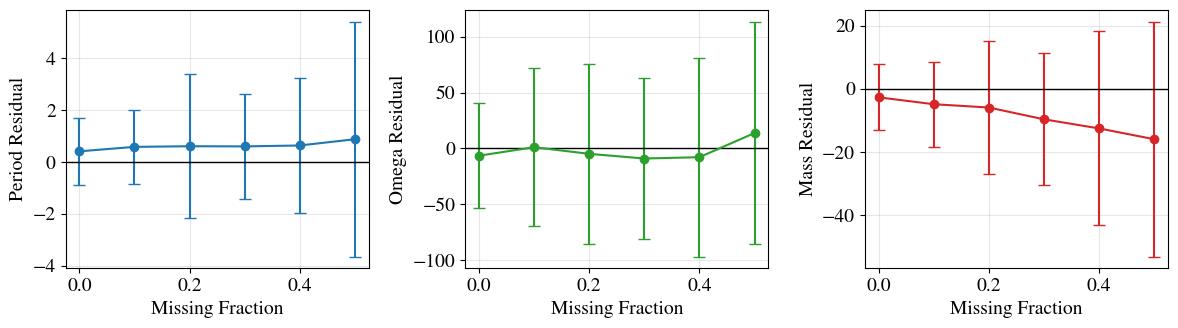

In [ ]:
import matplotlib.pyplot as plt

params = [ "Period_resid", "Omega_resid", "Mass_resid"]
labels = [ "Period", "Omega", "Mass"]
colors = ["tab:blue", "tab:green", "tab:red"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharex=True)

for ax, param, label, color in zip(axes, params, labels, colors):

    mean_vals = df_avg[param]
    std_vals  = df_std[param]

    ax.errorbar(df_avg["missing_fraction"],
                mean_vals,
                yerr=std_vals,
                fmt='o-', color=color,
                ecolor=color, elinewidth=1.5, capsize=4,
                label=f"{label} mean ± std")

    ax.axhline(0, color="black", lw=1)
    #ax.set_title(f"{label} Residual")
    ax.set_xlabel("Missing Fraction")
    ax.set_ylabel(f"{label} Residual")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(log_dir+'/residual_plot_erorbar.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
log_dir

'/content/gdrive/MyDrive/S3/revisi_paper/revisi_paper/model_logs_LSTM/experiment_2025-11-22_21-28-54'

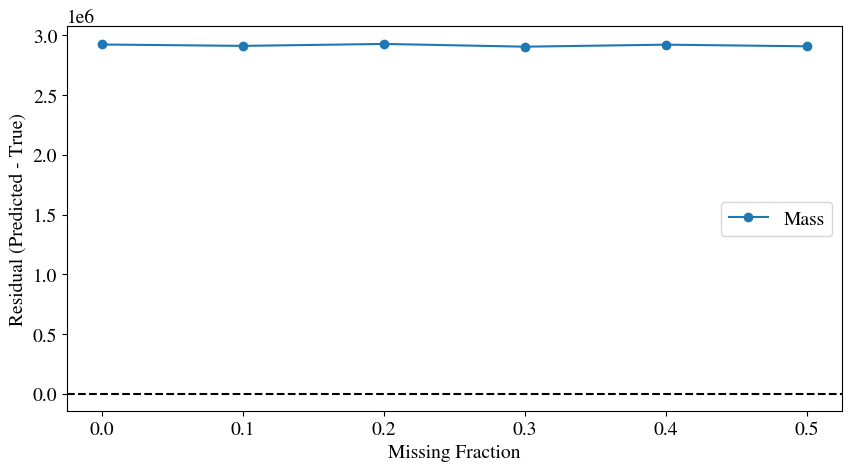

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(df_avg["missing_fraction"], df_avg["Mass_resid"], 'o-', label="Mass")
#plt.plot(df_avg["missing_fraction"], df_avg["Period_resid"], 'o-', label="Period")
#plt.plot(df_avg["missing_fraction"], df_avg["Omega_resid"], 'o-', label="Omega")

plt.axhline(0, color='black', linestyle='--')
plt.legend()
plt.xlabel("Missing Fraction")
plt.ylabel("Residual (Predicted - True)")
plt.show()


In [ ]:
STOPPP

In [ ]:
import pickle

#filename='/content/gdrive/MyDrive/nbody_project/pdlk2/sample_data_smallvar/train_10k_long_koi.pkl'
filename='/content/gdrive/MyDrive/S3/new_ml_model/datatrain_10k.pkl'

# Load the data from the pickle file
with open(filename, 'rb') as f:
    loaded_data = pickle.load(f)

# Access the arrays and ensure they are NumPy arrays with consistent shapes
ttv_data = np.array(loaded_data['ttv_data'])
star_mass = np.array(loaded_data['star_mass']).reshape(-1, 1)  # Reshape to (100000, 1)
transiting_period = np.array(loaded_data['transiting_period']).reshape(-1, 1)  # Reshape to (100000, 1)
transiting_mass = np.array(loaded_data['transiting_mass']).reshape(-1, 1)  # Reshape to (100000, 1)
perturbing_mass = np.array(loaded_data['perturbing_mass']).reshape(-1, 1)  # Reshape to (100000, 1)
perturbing_period = np.squeeze(np.array(loaded_data['perturbing_period'])).reshape(-1, 1)  # Reshape to (100000, 1)
perturbing_eccentricity = np.array(loaded_data['perturbing_eccentricity']).reshape(-1, 1)  # Reshape to (100000, 1)
perturbing_argument_perigee = np.array(loaded_data['perturbing_argument_perigee']).reshape(-1, 1)  # Reshape to (100000, 1)


In [ ]:
vv= np.amax(ttv_data, axis=1)
max_index = np.argmin(vv)
print(max_index)
plt.plot(vv)

In [ ]:
plt.plot(ttv_data[max_index])

In [ ]:
STOPP

In [ ]:
import pickle
import numpy as np

#filename='/content/gdrive/MyDrive/nbody_project/pdlk2/sample_data_smallvar/train_10k_long_koi.pkl'
#filename='/content/gdrive/MyDrive/S3/new_ml_model/datatrain_50k.pkl'

# Load the data from the pickle file
with open(filename, 'rb') as f:
    loaded_data = pickle.load(f)

limit=200000
# ttv_data = loaded_data['ttv_data'][0:limit]
# star_mass = loaded_data['star_mass'][0:limit]
# transiting_period = loaded_data['transiting_period'][0:limit]
# transiting_mass = loaded_data['transiting_mass'][0:limit]
# perturbing_mass = loaded_data['perturbing_mass'][0:limit]
# perturbing_period = loaded_data['perturbing_period'][0:limit]
# perturbing_eccentricity = loaded_data['perturbing_eccentricity'][0:limit]
# perturbing_argument_perigee = loaded_data['perturbing_argument_perigee'][0:limit]
# Access the arrays and ensure they are NumPy arrays with consistent shapes
ttv_data = np.array(loaded_data['ttv_data'])[0:limit]
star_mass = np.array(loaded_data['star_mass']).reshape(-1, 1)[0:limit]  # Reshape to (100000, 1)
transiting_period = np.array(loaded_data['transiting_period']).reshape(-1, 1)[0:limit]  # Reshape to (100000, 1)
transiting_mass = np.array(loaded_data['transiting_mass']).reshape(-1, 1)[0:limit]  # Reshape to (100000, 1)
perturbing_mass = np.array(loaded_data['perturbing_mass']).reshape(-1, 1)  # Reshape to (100000, 1)
perturbing_period = np.squeeze(np.array(loaded_data['perturbing_period'])).reshape(-1, 1) [0:limit] # Reshape to (100000, 1)
#perturbing_eccentricity = np.array(loaded_data['perturbing_eccentricity']).reshape(-1, 1)  # Reshape to (100000, 1)
perturbing_argument_perigee = np.array(loaded_data['perturbing_argument_perigee']).reshape(-1, 1)[0:limit]  # Reshape to (100000, 1)



ratio = transiting_period/perturbing_period

#mask = (perturbing_mass < 80) & (ratio < 1)

max_list= np.amax(ttv_data, axis=1)
positive_ttv = np.where(mask)[0]
ttv_data = ttv_data[positive_ttv]
star_mass = star_mass[positive_ttv]
transiting_period = transiting_period[positive_ttv]
transiting_mass = transiting_mass[positive_ttv]
perturbing_mass = perturbing_mass[positive_ttv]
perturbing_period = perturbing_period[positive_ttv]
#perturbing_eccentricity = perturbing_eccentricity[positive_ttv]
perturbing_argument_perigee = perturbing_argument_perigee[positive_ttv]

# Combine the data into a single array for plotting
data = np.hstack([
    star_mass,
    transiting_period,
    transiting_mass,
    perturbing_mass,
    perturbing_period,
    #perturbing_eccentricity,
    perturbing_argument_perigee
])

# Define the labels for the corner plot
labels = [
    r'$M_*$',
    r'$P_1$ [hari]',
    r'$M_1$ [$M_\oplus$]',
    r'$M_2$ [$M_\oplus$]',
    r'$P_2$ [hari]',
    #r'$e_2$',
    r'$\omega_2$ [deg]'
]

# Create the corner plot
figure = corner.corner(data, labels=labels, show_titles=True,quantiles=None, plot_contours=False, plot_density=False,plot_datapoints=False)

# # New set of values
# new_star_mass = ms_list
# new_transiting_period = p1_list
# new_transiting_mass = m1_list #* msun/mearth
# new_perturbing_mass = m2_list #* msun/mearth
# new_perturbing_period = p2_list
# #new_perturbing_eccentricity = e2_list
# new_perturbing_argument_perigee = o2_list

# # Combine the new set of values into a single array
# new_data = np.array([
#     new_star_mass,
#     new_transiting_period,
#     new_transiting_mass,
#     new_perturbing_mass,
#     new_perturbing_period,
#     #new_perturbing_eccentricity,
#     new_perturbing_argument_perigee
# ])

values = np.amax(ttv_data, axis=1)
norm = plt.Normalize(vmin=min(values), vmax=50)#max(values))
colors = plt.cm.jet(norm(values))

# Manually add colored data points
axes = np.array(figure.axes).reshape((data.shape[1], data.shape[1]))
for i in range(data.shape[1]):
    for j in range(i):
        ax = axes[i, j]
        ax.scatter(data[:, j], data[:, i], c=colors, s=0.1)


# Overlay the new set of values
axes = np.array(figure.axes).reshape((len(labels), len(labels)))

# # Loop through the diagonal axes
# for i in range(len(labels)):
#     ax = axes[i, i]
#     ax.axvline(new_data[i], color='r', linestyle='dashed')

# # Loop through the off-diagonal axes
# for yi in range(len(labels)):
#     for xi in range(yi):
#         ax = axes[yi, xi]
#         ax.plot(new_data[xi,:], new_data[yi,:], 'ro')  # Red marker for new data
# koi=0
# Show the plot
plt.savefig("corner_kepler_200k.png", dpi=300, bbox_inches = 'tight')
plt.show()

In [ ]:
# prompt: read file from fits file
from astropy.io import fits

exo_data = 'ttv_data.fit'
ttv_exo= Table.read(exo_data)
df_exo=  ttv_exo.to_pandas()



In [ ]:
plt.figure(figsize=(10,8))
plt.plot(df_exo['Epoch'], df_exo['O-C'],'.')

In [ ]:
ttv_list = Table.read(long_ttvlist)
df_longttv =  ttv_list.to_pandas()
df_longttv

In [ ]:
plt.figure(figsize=(10,8))
plt.plot(df_longttv['KOI'], df_longttv['N'],'.')
plt.grid()

In [ ]:
plt.figure(figsize=(10,8))
plt.plot(df_longttv['KOI'], df_longttv['Amp'],'.')
plt.grid()